# Download and prepare `SW_OUT` (2005-2025)

**notebook version**: `1` (3 Sep 2026)

## ℹ️ About this notebook

This notebook downloads the screened outgoing (reflected) shortwave radiation `SW_OUT` from the
InfluxDB database, merges its two data versions into one series, applies the 2012 corrections and the
nighttime zero-offset, works out which instrument and which calibration constant produced each part
of the record, and writes the result to the external data folder.

Its structure follows notebooks `01` (`SW_IN`), `02` (`TA`), `05` (`PA`) and `06` (`LW_IN`), but four
things about this variable are different.

1. **There is no gap-filling.** Nothing at this site, or anywhere near it, measures the shortwave
   that this canopy reflects, so a gap-filling model would have no driver to learn from. The series
   is therefore exported as it was measured, as in `05` and `06`, and it contains gaps.
2. **There is no external reference either.** MeteoSwiss Lägern and NABEL both measure incoming
   shortwave only, and the site's other outgoing channel, `SW_OUT_BC_M1_2_1`, sits below the canopy
   and measures something else. What takes the place of a reference is the **incoming channel of the
   same radiometer**, because `SW_OUT / SW_IN` is the surface albedo. Both channels sit in one
   instrument, so anything that scales both of them together cancels in that ratio, which is what
   makes it useful.
3. **There are two screenings of this measurement, and they had to be checked against each other.**
   The MeteoScreeningTool and the `diive` screening did not read the same input files, so they could
   in principle have converted the same voltages with different constants. They overlap for two full
   years while both describe the same instrument, which means the question can be settled by
   measurement rather than by argument. It is, and they agree, so the two are spliced without any
   rescaling.
4. **The instrument changed too, in December 2021.** The older radiometer converted this channel
   with the constant belonging to its incoming channel, whereas the newer one uses a constant of its
   own. That difference is measured and flagged rather than corrected, because correcting it would
   need calibration figures that no longer exist.

**Output columns:**

- `SW_OUT_T1_47_1`: outgoing shortwave radiation in **W m-2**, as measured and corrected, with
  genuine gaps left as `NaN`.
- `FLAG_SW_OUT_T1_47_1_SOURCE`: which screening produced the value. The two are on one scale, so
  this is provenance rather than a warning, but it is what a later re-screening would change.
- `FLAG_SW_OUT_T1_47_1_INSTRUMENT`: which radiometer produced the value and which calibration
  constant converted it, including a code for the weeks in which the new instrument was still being
  read through the old instrument's constant.

A fourth column, `SW_OUT_T1_47_1_HOMOGENIZED`, appears **only if** a re-run measures the two
screenings to be on different scales by more than `SCALE_DIFFERENCE_TOLERANCE`. On the current data
they are not, so it is absent, and the section on the scale difference explains why exporting it
anyway would be worse than leaving it out.

There is **no `FLAG_..._ISFILLED` column**, because nothing here is filled. A non-null record is a
measurement.

Downloading uses diive's InfluxDB engine `InfluxIO`, which needs `influxdb-client`. A plain
`uv sync` installs it here through the `diive[db]` extra.

***

## 📇 Data sources

- `SW_OUT_T1_47_1`: the exported variable, and **the only outgoing shortwave series this notebook
  reads**. Tower 1, 47 m. Both data versions are downloaded and both are required. The below-canopy
  `SW_OUT_BC_M1_2_1` is a different measurement at a different height and is not read here.
- `01_METEO_SW_IN_GAPFILLED_2004-2025.parquet`: the finished incoming shortwave product, read as a
  **diagnostic partner** and never exported. It is the other shortwave channel of the same
  radiometer. Only records `01` reports as measured are used.
- `MeteoSwiss_LAE_30MIN_2004-2025.parquet`: the MeteoSwiss Lägern station, 2.5 km away, read as a
  **diagnostic**. It measures no reflected shortwave. Its use here is to put an independent scale on
  the *incoming* channel across the days between the radiometer swap and the logger-program update.
- The **logger programs** and the **GIN fieldbook**: read in the notebook rather than quoted, so a
  re-run re-derives the sensor identity, the conversion constants and the dates.

Legend:
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive

### ⚠️ The two data versions did not read the same input

The two screenings of this measurement did not start from the same files. The MeteoScreeningTool read
delivered CSV files and wrote its result into `ch-lae_processed`, whereas the `diive` screening reads
the raw record in `ch-lae_raw`. That has two effects which run through the whole notebook.

The first is about coverage. Because the two pipelines drew on different sources, the raw field and
the `mst` data version cover different periods, and the fact that the raw record only begins in 2020
says nothing about how far back the measurement itself reaches. `SWC` and `G` have the same problem.
So the span of each data version is derived from the data here rather than assumed, and
`RECORD_START` below is a claim about the record that one cell tests against the first record it
actually finds. A run that disagrees fails at that assertion instead of writing a file whose name
says one period and whose contents are another.

The second effect is about scale, and it is the reason this notebook spends a whole section on the
two versions. Two pipelines that converted the same voltages with different constants would report
different numbers, and nothing about the way these two were built rules that out in advance. The
section *The scale difference between the two screenings* measures the ratio between them on the two
years in which they overlap, and finds that they agree, so no rescaling is applied.

The units tag is checked on both versions, the same way `06` does it. One series in this database
carries the placeholder `-not-given-` beside the real `W m-2`, so the check strips placeholders first
and then requires exactly one real unit to remain.

### 📐 What the exported values are

The exported numbers are **upwelling (reflected) shortwave irradiance** at 47 m, above the canopy.
After the correction below they are exactly zero at night, and at midday they reach at most a few
hundred W m-2. This stand reflects roughly a tenth of the shortwave that falls on it, so a reader who
expects values of the same order as `SW_IN` will misread the file by a factor of ten.

Dividing this variable by `SW_IN` gives the surface albedo, which is what most users will actually
want. Before doing that across December 2021 or across the start of the later screening era, read the
two sections on the instrument and on the scale difference: both boundaries move the ratio, and the
flags exist so that either can be filtered out.

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

The raw 1MIN record is kept on `TIMESTAMP_END`. The only thing asked of it is how many minutes fall
into each 30MIN bin, and diive resamples on that axis.

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

TARGET = "SW_OUT_T1_47_1"   # exported variable, tower 47 m; the ONLY outgoing shortwave series here
MEASUREMENT = "SW"          # the InfluxDB measurement that groups the shortwave fields

# RECORD_START is a CLAIM, not a setting to be tuned: it is the date the CNR1's outgoing channels
# were relayed onto this logger, which is also where SW_IN and LW_IN begin. The merge cell asserts
# the first record found against it. If that assertion fires, the record is not the one this
# notebook is named for, and the notebook name, OUTNAME and this constant all have to change
# together rather than the constant alone.
RECORD_START = '2005-09-14'
RECORD_END = '2025-12-31'
DOWNLOAD_START = '2004-01-01 00:00:01'  # the start date itself IS included
DOWNLOAD_STOP = '2026-01-01 00:00:01'   # the stop date itself IS NOT included
MST_STOP = '2022-01-01 00:00:01'        # the MeteoScreeningTool was retired at the end of 2021

OUTNAME = "12_METEO_SW_OUT_2005-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

SW_IN_PRODUCT = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
                 r"\workflow\10_METEO\30_PRODUCTS\01_METEO_SW_IN_GAPFILLED_2004-2025.parquet")
SW_IN_COL = "SW_IN_T1_47_1_gfXG"
SW_IN_FLAG = "FLAG_SW_IN_T1_47_1_ISFILLED"

REFPATH = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\workflow\10_METEO\10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet")
REFCOL = "SW_IN_LAE_MS"

# --- Inputs for the instrument-identity section ---------------------------------------------------
# The site maintenance record, exported from GIN. It lives BESIDE the workflow folder, not inside it,
# because it is an input to many stages rather than the output of one.
FIELDBOOK = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv")

# Every logger program on disk that measures this channel. The three CR10X programs are the surviving
# tower programs that carry the CNR1; the 2004 ones measure no radiometer channel at all. No tower
# program survives between May 2006 and January 2016, and none at all after January 2016 - which
# matters here, because the fieldbook records that a new program was uploaded in June 2016 and again
# in January 2022. What the programs can and cannot establish is stated where they are read.
PROGRAMS_CR10X = [
    r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
    r"\csi_loggerscripts\LAEGEREN.20050818.CSI",
    r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
    r"\csi_loggerscripts\LAEGEREN.20050914.CSI",
    r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
    r"\csi_loggerscripts\LAEGEREN.20060524.csi",
]
PROGRAM_CR1000 = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
                  r"\logger_scripts\ch-lae_idl_t1_47_1-Version_20160118\CH-LAE_iDL_T1_47_1.CR1")

# How large a difference between the two screenings has to be before it is treated as a difference
# in conversion rather than as the scatter two screenings of one measurement leave behind. The
# comparison is a ratio, so this is a fraction: 0.01 is one per cent.
#
# The number is set from what a real difference would look like at this site. Every documented
# calibration difference here is tens of per cent: the June 2016 factor change is 28 %, and reading
# the CNR4 through the CNR1 constant would be 38 % on the incoming channel and 43 % on this one. One
# per cent is far below all of those and far above what two screenings of one voltage can differ by
# once the nighttime offset is out, so it separates the two cases without sitting near either.
SCALE_DIFFERENCE_TOLERANCE = 0.01

# --- The conversion constants, declared -----------------------------------------------------------
# Every number the product depends on is written out here, with the file it comes from. Two reasons.
# The logger programs and the maintenance record live in the external data folder, which is not
# guaranteed to be on the machine running this notebook, so a notebook that could only obtain these
# by parsing could not run without that folder. And a reader of the rendered page can see a declared
# number, whereas a parsed one is only a claim that a file said something.
#
# Everything downstream uses the declared values. The parsing further down exists to CHECK them, and
# never to supply them, so that two runs cannot disagree depending on which files happened to be
# present.

# The CNR1 conversion: one multiplier and offset for every channel of the head, in every program
# that survives. Multiplier 1000/10.03, offset 0, i.e. a sensitivity of 10.03 uV W-1 m2.
#
# Source, and what each file actually contains. LAEGEREN.20050818.CSI (CR10X) is where the CNR1
# instruction first appears and is the only program that converts all four channels separately,
# outgoing shortwave included. LAEGEREN.20050914.CSI and LAEGEREN.20060524.csi (CR10X) convert the
# two outgoing channels with one two-repetition instruction that names only the outgoing longwave
# location, so the outgoing shortwave carries the same constants without appearing by name.
# CH-LAE_iDL_T1_47_1.CR1 (CR1000) has a VoltDiff per channel, this one on line 182. The section that
# reads them explains the two layouts and checks the constants across whatever each file carries.
CNR1_MULTIPLIER = 99.7009
CNR1_OFFSET = 0.0
CNR1_SENSITIVITY = 10.03

# The CNR4 sensitivities, one per channel, in uV W-1 m2. Source: the GIN fieldbook entry of
# 7 January 2022 recording the logger program update, which declares SENSITIVITY_iCNR4_<channel>.
CNR4_SENSITIVITIES = {'SW_IN': 13.89, 'SW_OUT': 14.38, 'LW_IN': 10.85, 'LW_OUT': 11.33}

# The NetRad calibration factor change of 7 June 2016, in uV W-1 m2. Source: the GIN fieldbook entry
# of that date. It moved the longwave channels, which notebook 06 measures, and not the shortwave
# ones, which notebook 01 measures; step 3 below tests whether it moved this channel.
CAL_2016_FROM = 10.03
CAL_2016_TO = 12.83

# --- The dates this notebook is about -------------------------------------------------------------
LOGGER_CHANGE = '2016-01-21'   # CR10X -> CR1000, the date that moved TA by 1.3 degC
CAL_CHANGE = '2016-06-07'      # the fieldbook's NetRad calibration factor change, see above

# The minute the radiometer swap shows up in the sibling channel. The LW_OUT screening notebook
# removes exactly this one 1MIN record; it is the only timestamp in this dataset that dates the swap
# to better than a day, and the fieldbook date derived below is asserted against it.
INSTALL_ARTEFACT_MINUTE = '2021-12-14 13:34:30'  # TIMESTAMP_MID of the 1MIN record

# A window written into the SW_OUT screening notebook's REMOVE_DATES but never committed there (its
# addflag cell carries no stored output). It is not removed here either; the section "A candidate
# window left in place" measures it and says what would settle it.
#
# The screening notebook writes the end as 00:00:15, because there it is matched against 1MIN
# middle-of-period stamps and has to bracket the record at 00:00:00. This notebook works on 30MIN
# stamps, where the nearest are 23:45 and 00:15, so the fifteen seconds select nothing either way
# and the round stamp is used instead. The window is the same window.
CANDIDATE_WINDOW_2024 = ('2024-07-14 07:15:00', '2024-07-19 00:00:00')

### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import html
import re
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-09-03 21:50:04
diive version: v0.91.1


### Captions

In [3]:
# Captions. Every table and every figure in this notebook carries one, so that a reader meeting a
# number in the rendered page can tell what it is without reading the code that produced it.
# Defined here, above the first cell that calls either. Copied as-is from notebooks 02, 03 and 06.
def tabcap(text, width=100):
    """Print a table caption, above the table it belongs to."""
    print(textwrap.fill(f"Table - {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure - {text}", width)
    # An engine that still lays the figure out at draw time can make room for a caption itself.
    # plt.tight_layout() does NOT leave one: it executes once and leaves a PlaceHolderLayoutEngine
    # that never runs again, so a caption handed to supxlabel there lands on top of the tick labels.
    # Those figures take the manual branch below.
    _engine = fig.get_layout_engine()
    if _engine is not None and type(_engine).__name__ != 'PlaceHolderLayoutEngine':
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12          # inches; one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')

### 🧭 Guards

Two cheap checks run on every source before it is used: one on the unit tag the database carries, and
one on whether the values are physically possible.

There are two plausibility bands rather than one, and the difference between them is deliberate. On
download a pyranometer may legitimately read below zero, because the nighttime offset has not been
taken out at that point and in the `mst` era it never was, so the lower wall on download is the one
the `diive` screening used for its own absolute-limit test. That test rejected nothing, which is why
the wall is set where it is. On export the floor is zero instead, because by then the offset has been
removed and a negative reflected flux would mean the correction failed.

No unit harmonisation is needed here, because every series involved is already in `W m-2`.

In [4]:
# Physically plausible outgoing shortwave at this site, before and after the nighttime zero-offset
# correction. The lower wall on download is the one the diive screening used for its own
# absolute-limit test, which rejected nothing; on export the floor is zero, because by then the
# offset has been removed.
#
# The upper wall is set from the record rather than from physics. The highest half-hour in twenty
# years is about 236 W m-2, so 300 leaves room for a brighter event than anything the record
# contains. It is NOT a physical ceiling: a snow-covered canopy at an albedo of 0.6 under 600 W m-2
# of incoming shortwave would reflect far more than this, and would fire the guard. So if this wall
# ever fires, the first question is whether a real snow event exceeded it, and the second is whether
# the scale is wrong - in that order. Widen it only after answering the first.
SW_OUT_PLAUSIBLE_WM2 = (-100.0, 300.0)   # as downloaded
SW_OUT_EXPORT_WM2 = (0.0, 300.0)         # after the correction
EXPECTED_UNIT = 'W m-2'
NOT_GIVEN = '-not-given-'   # placeholder the database uses when a unit tag was never filled in


def check_unit(declared_units: list, source: str) -> str:
    """Verify the database's unit tags for a series say W m-2, ignoring placeholders.

    A series can carry more than one tag value (e.g. when the tag changed over time, or was left
    unset for part of the record). Placeholders are dropped; exactly one real unit must remain, and
    it must be the expected one.
    """
    real = [u for u in declared_units if u != NOT_GIVEN]
    if len(set(real)) != 1:
        raise ValueError(f"{source}: expected exactly one real unit tag, found {declared_units}.")
    if real[0] != EXPECTED_UNIT:
        raise ValueError(f"{source}: unit is '{real[0]}', expected '{EXPECTED_UNIT}'.")
    return real[0]


def check_range(series: pd.Series, source: str, band=SW_OUT_PLAUSIBLE_WM2) -> dict:
    """Verify every value is physically plausible outgoing shortwave, and describe the series."""
    lo, hi = band
    s = series.dropna()
    if s.empty:
        raise ValueError(f"{source}: no data.")
    if not (lo <= s.min() and s.max() <= hi):
        raise ValueError(f"{source}: range {s.min():.1f}..{s.max():.1f} W m-2 is outside the "
                         f"plausible {lo}..{hi} W m-2.")
    return {'records': len(s), 'median (W m-2)': round(float(s.median()), 2),
            'median above zero (W m-2)': round(float(s[s > 0].median()), 2),
            'min (W m-2)': round(float(s.min()), 1), 'max (W m-2)': round(float(s.max()), 1)}

#### The guards actually guard

A check that never fires is not a check, so every failure path is exercised here.

In [5]:
for _bad, _why in [(['kW m-2'], 'wrong unit'), (['W m-2', 'umol m-2 s-1'], 'two real units'),
                   ([NOT_GIVEN], 'nothing but a placeholder')]:
    try:
        check_unit(_bad, 'negative control')
        raise AssertionError(f"check_unit accepted {_bad} - the guard is broken.")
    except ValueError as exc:
        print(f"OK ({_why}): {exc}")

try:
    check_range(pd.Series([0.0, 12.0, 4200.0]), 'negative control')
    raise AssertionError("check_range accepted a value 14x the physical maximum - the guard is broken.")
except ValueError as exc:
    print(f"OK (out of range): {exc}")

try:
    check_range(pd.Series([np.nan, np.nan]), 'negative control')
    raise AssertionError("check_range accepted an empty series - the guard is broken.")
except ValueError as exc:
    print(f"OK (no data): {exc}")

try:
    check_range(pd.Series([-3.0, 100.0]), 'negative control', band=SW_OUT_EXPORT_WM2)
    raise AssertionError("the export band accepted a negative value - the guard is broken.")
except ValueError as exc:
    print(f"OK (negative, export band): {exc}")

OK (wrong unit): negative control: unit is 'kW m-2', expected 'W m-2'.
OK (two real units): negative control: expected exactly one real unit tag, found ['W m-2', 'umol m-2 s-1'].
OK (nothing but a placeholder): negative control: expected exactly one real unit tag, found ['-not-given-'].
OK (out of range): negative control: range 0.0..4200.0 W m-2 is outside the plausible -100.0..300.0 W m-2.
OK (no data): negative control: no data.
OK (negative, export band): negative control: range -3.0..100.0 W m-2 is outside the plausible 0.0..300.0 W m-2.


### 🔌 Connect to database

In [6]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## ⬇️ Download

Two series only: the target from each of its two data versions, both **required**. Incoming shortwave
is read from the finished product of notebook `01` rather than from the database, so the diagnostics
below use the same corrected, flagged series a data user would.

In [7]:
%%time

BUCKET_PROCESSED = 'ch-lae_processed'
BUCKET_RAW = 'ch-lae_raw'


def download(bucket, measurement, fields, start, stop, data_version,
             to_middle=True, nominal_freq=REQUIRED_TIME_RESOLUTION):
    data, _, _ = dbc.download(
        bucket=bucket, measurements=[measurement], fields=fields,
        start=start,  # the start date itself IS included
        stop=stop,    # the stop date itself IS NOT included
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        data_version=data_version)
    return TimestampSanitizer(data=data, output_middle_timestamp=to_middle,
                              nominal_freq=nominal_freq).get()


mst_sw = download(BUCKET_PROCESSED, MEASUREMENT, [TARGET], DOWNLOAD_START, MST_STOP,
                  'meteoscreening_mst')
diive_sw = download(BUCKET_PROCESSED, MEASUREMENT, [TARGET], DOWNLOAD_START, DOWNLOAD_STOP,
                    'meteoscreening_diive')

print(f"mst   {TARGET}: {mst_sw[TARGET].notna().sum():,} records, "
      f"{mst_sw.index[0]} -> {mst_sw.index[-1]}")
print(f"diive {TARGET}: {diive_sw[TARGET].notna().sum():,} records, "
      f"{diive_sw.index[0]} -> {diive_sw.index[-1]}")

> DOWNLOADING from bucket ch-lae_processed: variables ['SW_OUT_T1_47_1'] from measurements ['SW'],
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['SW_OUT_T1_47_1'] from measurements ['SW'],
data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone
offset to UTC 1)

> Downloaded data for 1 variables:

mst   SW_OUT_T1_47_1: 282,776 records, 2005-09-14 11:15:00 -> 2021-12-31 23:45:00
diive SW_OUT_T1_47_1: 105,080 records, 2020-01-02 00:45:00 -> 2025-12-31 23:45:00
CPU times: total: 6.7 s
Wall time: 9.34 s


In [8]:
# Tags straight from the database, including the unit and the raw variable each series came from.
# A data_version filter is not a tag filter: within one field and version there can be several series
# carrying different gain, raw_varname or freq tags, so each of these is a list.
def field_tags(bucket, field, measurement, data_version):
    return dbc.show_field_overview(bucket=bucket, measurement=measurement, field=field,
                                   data_version=data_version, verbose=False)['tags']


_tags_mst = field_tags(BUCKET_PROCESSED, TARGET, MEASUREMENT, 'meteoscreening_mst')
_tags_diive = field_tags(BUCKET_PROCESSED, TARGET, MEASUREMENT, 'meteoscreening_diive')
_tags_raw = field_tags(BUCKET_RAW, TARGET, MEASUREMENT, 'raw')

tabcap("the database's own tags for the two data versions of the exported column and for the raw "
       "record. `raw_varname` names the logger channel behind the values, which is the one thing "
       "about this series that cannot be read off the numbers")
display(pd.DataFrame({
    'units': [_tags_mst.get('units'), _tags_diive.get('units'), _tags_raw.get('units')],
    'raw_varname': [_tags_mst.get('raw_varname'), _tags_diive.get('raw_varname'),
                    _tags_raw.get('raw_varname')],
    'gain': [_tags_mst.get('gain'), _tags_diive.get('gain'), _tags_raw.get('gain')],
    'freq': [_tags_mst.get('freq'), _tags_diive.get('freq'), _tags_raw.get('freq')],
}, index=[f'{TARGET} (mst)', f'{TARGET} (diive)', f'{TARGET} (raw)']))

Table - the database's own tags for the two data versions of the exported column and for the raw
record. `raw_varname` names the logger channel behind the values, which is the one thing about this
series that cannot be read off the numbers



,units,raw_varname,gain,freq
SW_OUT_T1_47_1 (mst),[W m-2],[SW_OUT_AVG_T1_47_1],[1.0],[30min]
SW_OUT_T1_47_1 (diive),[W m-2],[SW_OUT_T1_47_1_Avg],[1.0],[30min]
SW_OUT_T1_47_1 (raw),[W m-2],[SW_OUT_T1_47_1_Avg],[1.0],[min]


### Unit and range checks

A differing `gain` tag does **not** by itself mean the two versions are stored on different scales. It
records what each screening applied to its own raw source. The tag is read against the magnitude of
the data rather than acted on, which is what the range table is for.

In [9]:
print("Unit tags (placeholders stripped):")
for _tags, _src in [(_tags_mst, f'{TARGET} (mst)'), (_tags_diive, f'{TARGET} (diive)'),
                    (_tags_raw, f'{TARGET} (raw)')]:
    print(f"  {_src:<26} {_tags.get('units')} -> {check_unit(_tags.get('units'), _src)}")

tabcap("each data version of the exported column, after the range guard has passed on it. The two "
       "differ at the bottom of the range rather than at the top: the diive screening removed the "
       "pyranometer's nighttime offset and the MeteoScreeningTool did not, which is what the "
       "corrections section deals with")
display(pd.DataFrame({f'{TARGET} (mst)': check_range(mst_sw[TARGET], f'{TARGET} (mst)'),
                      f'{TARGET} (diive)': check_range(diive_sw[TARGET], f'{TARGET} (diive)')}).T)

Unit tags (placeholders stripped):
  SW_OUT_T1_47_1 (mst)       ['W m-2'] -> W m-2
  SW_OUT_T1_47_1 (diive)     ['W m-2'] -> W m-2
  SW_OUT_T1_47_1 (raw)       ['W m-2'] -> W m-2
Table - each data version of the exported column, after the range guard has passed on it. The two
differ at the bottom of the range rather than at the top: the diive screening removed the
pyranometer's nighttime offset and the MeteoScreeningTool did not, which is what the corrections
section deals with



,records,median (W m-2),median above zero (W m-2),min (W m-2),max (W m-2)
SW_OUT_T1_47_1 (mst),282776.0,-1.30,29.02,-20.0,240.1
SW_OUT_T1_47_1 (diive),105080.0,0.11,22.02,0.0,185.4


***

## ❇️ Merge onto one continuous 30MIN index

In [10]:
full_index = pd.date_range(f'{RECORD_START} 00:15:00', f'{RECORD_END} 23:45:00',
                           freq=REQUIRED_TIME_RESOLUTION, name='TIMESTAMP_MIDDLE')

# Potential radiation: astronomical, so it cannot drift, which is what makes it a safe selector for
# night and for illumination. A measured radiation series would put its own behaviour into the
# selection.
POTRAD = dv.variables.potrad(timestamp_index=full_index, lat=SITE_LAT, lon=SITE_LON,
                             utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
DARK = POTRAD <= 0
# A half-hour is fully dark only if the half-hours on either side of it are dark too: potential
# radiation is evaluated at the middle of the bin, so a bin whose own midpoint is dark can still hold
# up to fifteen minutes of sun.
FULLY_DARK = DARK & DARK.shift(1, fill_value=True) & DARK.shift(-1, fill_value=True)

MST = mst_sw[TARGET].reindex(full_index)
DIIVE = diive_sw[TARGET].reindex(full_index)

print(f"index: {full_index[0]} -> {full_index[-1]}  ({len(full_index):,} records)")
print(f"mst   spans {MST.first_valid_index()} -> {MST.last_valid_index()} "
      f"({int(MST.notna().sum()):,} records on this index)")
print(f"diive spans {DIIVE.first_valid_index()} -> {DIIVE.last_valid_index()} "
      f"({int(DIIVE.notna().sum()):,} records on this index)")
print(f"night half-hours: {int(DARK.sum()):,}   fully dark: {int(FULLY_DARK.sum()):,}")

index: 2005-09-14 00:15:00 -> 2025-12-31 23:45:00  (355,872 records)
mst   spans 2005-09-14 11:15:00 -> 2021-12-31 23:45:00 (282,776 records on this index)
diive spans 2020-01-02 00:45:00 -> 2025-12-31 23:45:00 (105,080 records on this index)
night half-hours: 170,475   fully dark: 155,647


### Do the two screenings describe the same series?

The two data versions are two screenings of one measurement, so before either is spliced onto the
other they have to be compared where they overlap. Notebook `08` makes the same comparison before
splicing its two acquisition eras. This cell is the first half of that comparison; the second half
is the section *The scale difference between the two screenings*, which measures the level ratio
under conditions this cell cannot yet provide.

The comparison uses **daylight** half-hours only. At night the two versions are expected to differ,
and the reason is already known: the `diive` screening set the dark hours to zero, whereas the
MeteoScreeningTool left the pyranometer's offset in place. So the nighttime difference between them
is that offset, and step 3 of the corrections removes it from the whole record. The nighttime figure
is printed beside the daytime one so that the two are not confused.

Two things are read from the daylight comparison, and they are treated differently.

- The **correlation** says whether the two versions saw the same weather in the same half-hours. It
  is asserted, because two screenings of one instrument's record that do not correlate are not
  describing one measurement, and nothing further in this notebook would mean anything.
- The **level ratio** says whether they put that weather on the same scale. It is only reported
  here, and the number this cell prints is **not** the one to act on, because at this point in the
  notebook the nighttime offset has not yet been removed from the `mst` version. A few W m-2 of
  offset is a large fraction of a small flux, so it inflates the ratio wherever the reflected flux
  is low. The number that counts is measured after the corrections, on well-illuminated half-hours
  only. If a level difference does turn out to be real, it does not make the splice wrong; it means
  the spliced series needs a second, rescaled column beside it, which is what `08` and `SWC`
  provide for their own eras.

In [11]:
OVERLAP = MST.notna() & DIIVE.notna()
print(f"records covered by both screenings: {int(OVERLAP.sum()):,}")

if int(OVERLAP.sum()) == 0:
    print("\nThe two data versions do not overlap, so there is nothing to prove before splicing "
          "them and combine_first simply concatenates them.")
else:
    _day = OVERLAP & (POTRAD > 0)
    _j = pd.concat([MST[_day].rename('mst'), DIIVE[_day].rename('diive')], axis=1).dropna()
    _r = float(_j['mst'].corr(_j['diive']))
    _d = _j['diive'] - _j['mst']
    _bright = _j[POTRAD.reindex(_j.index) > 200]
    _rel = float((_bright['diive'] / _bright['mst']).median())
    # The same ratio again, restricted to half-hours whose flux is far above the offset. The two
    # numbers differ, and the difference is the point: see the note printed below.
    _strong = _bright[_bright['mst'] > 50]
    _rel_strong = float((_strong['diive'] / _strong['mst']).median()) if len(_strong) else np.nan
    _spread = float(_j['diive'].std() / _j['mst'].std())
    _night = (DIIVE - MST)[OVERLAP & FULLY_DARK].dropna()

    tabcap("the two screenings compared on the half-hours they both cover. The correlation says "
           "whether they describe one measurement. The level and spread rows say whether they put "
           "it on one scale. The nighttime row is not a disagreement at all: it is the offset one "
           "screening removed and the other did not, which step 3 of the corrections removes from "
           "the whole record")
    display(pd.DataFrame({
        'daylight half-hours compared': [int(len(_j))],
        'correlation': [round(_r, 6)],
        'median difference, daylight (W m-2)': [round(float(_d.median()), 3)],
        'median ratio above 200 W m-2 potential': [round(_rel, 5)],
        'median ratio, flux above 50 W m-2': [round(_rel_strong, 5)],
        'ratio of standard deviations': [round(_spread, 5)],
        'median difference, fully dark (W m-2)': [round(float(_night.median()), 3)
                                                  if len(_night) else np.nan],
    }, index=['diive against mst']).T)

    assert _r > 0.99, (
        f"the two screenings correlate at only {_r:.4f} on daylight half-hours they both cover. "
        f"They are not two screenings of one measurement, and splicing them would produce a series "
        f"that is neither")
    # The level ratio is NOT asserted here. It is measured, explained and corrected for in the
    # section on the scale difference, which is also where the assertions about it live.
    print(f"\nThe two versions correlate at {_r:.5f}, so they saw the same weather in the "
          f"same half-hours.")
    print(f"On well-illuminated half-hours the diive screening reads {100 * (_rel - 1):+.1f} % "
          f"against the mst screening; restricted to half-hours whose flux is above 50 W m-2 it "
          f"reads {100 * (_rel_strong - 1):+.1f} %.")
    print("\nThose two numbers differ because this cell runs BEFORE the nighttime zero-offset is "
          "removed. The mst version still carries an offset of a few W m-2 at this point, and a "
          "few W m-2 is a large FRACTION of a small flux, so the ratio is inflated wherever the "
          "reflected flux is small. Neither number here is the one that counts.")
    print("The number that counts is measured in 'The scale difference between the two screenings' "
          "below, after the offset has been removed and on well-illuminated half-hours only. Read "
          "this cell for the correlation, which says the two versions saw the same weather, and "
          "wait for that section for the scale.")

records covered by both screenings: 35,032
Table - the two screenings compared on the half-hours they both cover. The correlation says whether
they describe one measurement. The level and spread rows say whether they put it on one scale. The
nighttime row is not a disagreement at all: it is the offset one screening removed and the other did
not, which step 3 of the corrections removes from the whole record



,diive against mst
daylight half-hours compared,18300.000000
correlation,0.998743
"median difference, daylight (W m-2)",3.050000
median ratio above 200 W m-2 potential,1.072860
"median ratio, flux above 50 W m-2",1.037630
ratio of standard deviations,0.987220
"median difference, fully dark (W m-2)",2.969000



The two versions correlate at 0.99874, so they saw the same weather in the same half-hours.
On well-illuminated half-hours the diive screening reads +7.3 % against the mst screening; restricted to half-hours whose flux is above 50 W m-2 it reads +3.8 %.

Those two numbers differ because this cell runs BEFORE the nighttime zero-offset is removed. The mst version still carries an offset of a few W m-2 at this point, and a few W m-2 is a large FRACTION of a small flux, so the ratio is inflated wherever the reflected flux is small. Neither number here is the one that counts.
The number that counts is measured in 'The scale difference between the two screenings' below, after the offset has been removed and on well-illuminated half-hours only. Read this cell for the correlation, which says the two versions saw the same weather, and wait for that section for the scale.


The index starts at the first `SW_OUT` measurement rather than at 2004-01-01. Nothing before it is
reconstructed. `combine_first` is used rather than `concat` so an overlap resolves deterministically,
and it resolves to `mst`. That version covers the earlier and larger part of the record and carries
no correction, so the correction below can be applied once to the whole series.

In [12]:
sw_2005_2025 = pd.DataFrame(index=full_index)
sw_2005_2025[TARGET] = MST.combine_first(DIIVE)

# Which version each record came from, given the combine_first order above. Used by the completeness
# audit, which can only speak for the diive era, and by the offset diagnostics, which have to report
# the two versions separately.
FROM_MST = MST.notna()
FROM_DIIVE = DIIVE.notna() & ~FROM_MST

_first = sw_2005_2025[TARGET].first_valid_index()
print(f"{TARGET}: {sw_2005_2025[TARGET].notna().sum():,} of {len(sw_2005_2025):,} records "
      f"({100 * sw_2005_2025[TARGET].notna().mean():.2f}%)")
print(f"  from mst: {int(FROM_MST.sum()):,}   from diive: {int(FROM_DIIVE.sum()):,}")
print(f"first measurement: {_first}")

# RECORD_START is a claim about the record, and this is where it is tested. The test is made against
# the RAW downloads rather than against the merged frame: full_index is built from RECORD_START and
# both series are reindexed onto it, so a record earlier than the claim has already been discarded
# by the time the merged frame is asked for its first value. Only a LATER start could fire a check
# made downstream of the reindex, which is half a check.
_earliest = min(mst_sw.index[0], diive_sw.index[0])
print(f"earliest record in either download: {_earliest}")
print(f"first record on the exported index: {_first}")
assert _earliest.date() == pd.Timestamp(RECORD_START).date(), (
    f"the earliest {TARGET} record in the downloads is {_earliest}, not on {RECORD_START} as this "
    f"notebook's name, OUTNAME and RECORD_START all claim. If it is earlier, the index is silently "
    f"truncating real data. Change the notebook name, OUTNAME and RECORD_START together, or find "
    f"out why the record moved - do not relax this assertion")
assert _first == _earliest, (
    f"the first record on the exported index is {_first} but the earliest downloaded record is "
    f"{_earliest}, so the reindex has dropped data from the start of the record")
assert sw_2005_2025.index.duplicated().sum() == 0, "duplicate timestamps on the merged index"
assert (sw_2005_2025.index.to_series().diff().dropna()
        == pd.Timedelta(REQUIRED_TIME_RESOLUTION)).all(), "the merged index is not continuous 30MIN"

MEASURED_AT_MERGE = int(sw_2005_2025[TARGET].notna().sum())
# The per-version counts are kept so that the flag section can assert against the numbers printed
# here rather than against the masks it builds the flag from.
N_FROM_MST_AT_MERGE = int(FROM_MST.sum())
N_FROM_DIIVE_AT_MERGE = int(FROM_DIIVE.sum())
REMOVALS = {}   # what each correction below removes, so the export can check the arithmetic

tabcap("the merged outgoing shortwave series on its final 30MIN index, before any correction")
display(sw_2005_2025)

SW_OUT_T1_47_1: 352,824 of 355,872 records (99.14%)
  from mst: 282,776   from diive: 70,048
first measurement: 2005-09-14 11:15:00
earliest record in either download: 2005-09-14 11:15:00
first record on the exported index: 2005-09-14 11:15:00
Table - the merged outgoing shortwave series on its final 30MIN index, before any correction



,SW_OUT_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-14 00:15:00,NaN
2005-09-14 00:45:00,NaN
2005-09-14 01:15:00,NaN
2005-09-14 01:45:00,NaN
2005-09-14 02:15:00,NaN
...,...
2025-12-31 21:45:00,0.0
2025-12-31 22:15:00,0.0
2025-12-31 22:45:00,0.0


### ☀️ The diagnostic partner: the incoming channel of the same radiometer

Every quantitative statement below is made in the ratio `SW_OUT / SW_IN`, which is the **surface
albedo**, and there are two reasons for that.

The first is that radiation errors are multiplicative. A conversion constant that is three per cent
wrong reads three per cent low at every irradiance, whether the sky is clear or overcast. So if you
subtract one radiation series from another you get the error mixed together with the weather, whereas
if you divide them the weather largely cancels and the error stays. The second reason is that these
two channels sit in one instrument, on one boom, wired to one logger. Anything that scales both of
them at once, such as a supply voltage or a dirty dome, therefore cancels in the ratio as well, and
what survives is the part that belongs to one channel alone.

Three controls are built into the helper rather than written out at each place it is called, because
each of them can otherwise manufacture an apparent change where nothing changed.

- **Season.** Albedo is taken as monthly medians averaged over calendar months, restricted to
  **April-September**. Snow on the canopy multiplies the reflected flux several times over and does
  not fall in the same weeks every year.
- **Illumination.** Half-hours are selected on **potential** radiation, which is astronomical and
  cannot drift. Selecting on either measured channel would bias the ratio towards that channel.
- **The partner's provenance.** Only half-hours notebook `01` reports as **measured** enter. A
  modelled `SW_IN` would put the gap-filling model into a statement about a pyranometer.

A ratio between two sensors is immune to how sunny a year was, so no clear-sky-index control is
needed.

In [13]:
_swin_product = pd.read_parquet(SW_IN_PRODUCT)
assert SW_IN_COL in _swin_product.columns and SW_IN_FLAG in _swin_product.columns, \
    f"the SW_IN product does not carry {SW_IN_COL} / {SW_IN_FLAG} - has notebook 01 changed its columns?"

SW_IN_MEASURED = _swin_product[SW_IN_COL].where(_swin_product[SW_IN_FLAG] == 0).reindex(full_index)

POTRAD_ALBEDO_MIN = 200.0   # W m-2; well-illuminated half-hours only
ALBEDO_MONTHS = (4, 5, 6, 7, 8, 9)

print(f"SW_IN product: {SW_IN_COL}")
print(f"  measured share on this index: {100 * SW_IN_MEASURED.notna().mean():.2f} %")
print(f"half-hours above {POTRAD_ALBEDO_MIN:.0f} W m-2 potential radiation: "
      f"{int((POTRAD > POTRAD_ALBEDO_MIN).sum()):,}")

assert SW_IN_MEASURED.notna().mean() > 0.9, \
    "the SW_IN product is now mostly modelled on this index, so the albedo diagnostics below would "\
    "be statements about a gap-filling model rather than about a pyranometer"

SW_IN product: SW_IN_T1_47_1_gfXG
  measured share on this index: 98.83 %
half-hours above 200 W m-2 potential radiation: 151,133


In [14]:
def albedo(sw_out: pd.Series) -> pd.Series:
    """Surface albedo on well-illuminated half-hours where SW_IN was measured.

    Both selections are deliberate and are described above: potential radiation is the selector
    because it is astronomical, and the incoming channel has to be a measurement rather than a fill.
    """
    ok = (POTRAD > POTRAD_ALBEDO_MIN) & SW_IN_MEASURED.notna() & (SW_IN_MEASURED > 0) & sw_out.notna()
    return (sw_out / SW_IN_MEASURED).where(ok)


def albedo_season(sw_out: pd.Series, years, months=ALBEDO_MONTHS) -> dict:
    """Season-controlled albedo level: monthly medians, averaged over the calendar months.

    Averaging the monthly medians rather than pooling the half-hours stops a year with more usable
    June half-hours than another from being a June statistic. Raises rather than returning a partial
    average when a calendar month is missing entirely, because a mean over five months and a mean
    over six are not the same statistic and nothing downstream could tell them apart.
    """
    a = albedo(sw_out)
    a = a[a.index.year.isin(list(years)) & a.index.month.isin(list(months))].dropna()
    if a.empty:
        raise ValueError(f"no usable albedo half-hours for years {tuple(years)}")
    monthly = a.groupby(a.index.month).median()
    if len(monthly) != len(months):
        raise ValueError(f"years {tuple(years)}: only {len(monthly)} of {len(months)} calendar "
                         f"months are represented, so the seasonal control cannot be applied")
    return {'albedo': float(monthly.mean()), 'n': int(len(a)),
            'monthly min': float(monthly.min()), 'monthly max': float(monthly.max())}


def albedo_days(sw_out: pd.Series, years, month_day_from, month_day_to) -> dict:
    """Season-controlled albedo over one calendar window, for the two 2016 dates.

    Same idea as albedo_season, but over a window inside a year rather than whole months, because
    the two 2016 changes are four months apart and a whole-year statistic cannot separate them.
    """
    a = albedo(sw_out)
    _md = list(zip(a.index.month, a.index.day))
    _in = np.array([month_day_from <= md <= month_day_to for md in _md])
    a = a[np.isin(a.index.year, list(years)) & _in].dropna()
    if a.empty:
        raise ValueError(f"no usable albedo half-hours in the window for years {tuple(years)}")
    return {'albedo': float(a.median()), 'n': int(len(a))}


# The guards guard: a helper that quietly returns a partial average is worse than no helper, because
# a mean over five calendar months and a mean over six cannot be told apart downstream.
for _years, _months, _why in [
        ((1999,), ALBEDO_MONTHS, 'a period holding no data at all'),
        ((2019,), tuple(ALBEDO_MONTHS) + (13,), 'a calendar month that can never be represented')]:
    try:
        albedo_season(sw_2005_2025[TARGET], _years, months=_months)
    except ValueError as _exc:
        print(f"OK ({_why}): {_exc}")
    else:
        raise AssertionError(f"albedo_season accepted {_why}.")

OK (a period holding no data at all): no usable albedo half-hours for years (1999,)
OK (a calendar month that can never be represented): years (2019,): only 6 of 7 calendar months are represented, so the seasonal control cannot be applied


### 🌍 The independent scale: MeteoSwiss Lägern

No weather service measures reflected shortwave, so this station cannot serve as a reference for the
exported series. It is read for one narrow purpose instead. It measures the **incoming** flux
independently, it belongs to another institution, and it covers the whole record, which together make
it able to answer one question that nothing on this tower can: whether the tower's shortwave channels
were converted with the wrong constant during the weeks between the radiometer swap and the
logger-program update.

The reference file carries `TIMESTAMP_END`, whereas this notebook works on `TIMESTAMP_MID`. For 30MIN
data the bin `(t-30min, t]` has its midpoint at `t-15min`, so the reference index is shifted back by
15 minutes. The guard in the cell below then proves that the shift is right, rather than leaving it
to be assumed.

One property of this station has to be carried into any use of it. `SW_IN_LAE_MS` **steps by about
5 % on 6 October 2010**, because the station's radiation instrumentation was rebuilt that day. A
difference between the tower and Lägern is therefore not evidence about the tower across that date,
and this notebook only uses the station inside winter windows that lie well after it.

In [15]:
_ref = pd.read_parquet(REFPATH)[[REFCOL]]
print(f"Reference read: {len(_ref):,} records, {_ref.index[0]} -> {_ref.index[-1]} ({_ref.index.name})")

# TIMESTAMP_END -> TIMESTAMP_MID: the 30MIN bin (t-30min, t] has its midpoint at t-15min.
_ref.index = _ref.index - pd.Timedelta(minutes=15)
_ref.index.name = full_index.name
SW_IN_REF = _ref[REFCOL].reindex(full_index)

# Guard: the shift must be right. Correlating the reference against the measured tower series at
# several half-hour offsets has to pick offset 0.
_scores = {}
for _off in (-1, 0, 1):
    _j = pd.concat([SW_IN_MEASURED.rename('t'), SW_IN_REF.shift(_off).rename('r')], axis=1).dropna()
    _j = _j[_j['r'] > 20]  # daytime only: at night both are ~0 and carry no timing information
    _scores[_off] = _j['t'].corr(_j['r'])
    print(f"  offset {_off:+d} x 30min: daytime corr {_scores[_off]:.4f}")
assert max(_scores, key=_scores.get) == 0, f"reference is mis-aligned: {_scores}"
print("OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.")
print(f"{REFCOL} available for {100 * SW_IN_REF.notna().mean():.2f}% of this index")

Reference read: 384,241 records, 2004-02-01 01:00:00 -> 2026-01-01 01:00:00 (TIMESTAMP_END)
  offset -1 x 30min: daytime corr 0.9288
  offset +0 x 30min: daytime corr 0.9648
  offset +1 x 30min: daytime corr 0.9069
OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.
SW_IN_LAE_MS available for 99.97% of this index


### 📊 Plot: the merged series

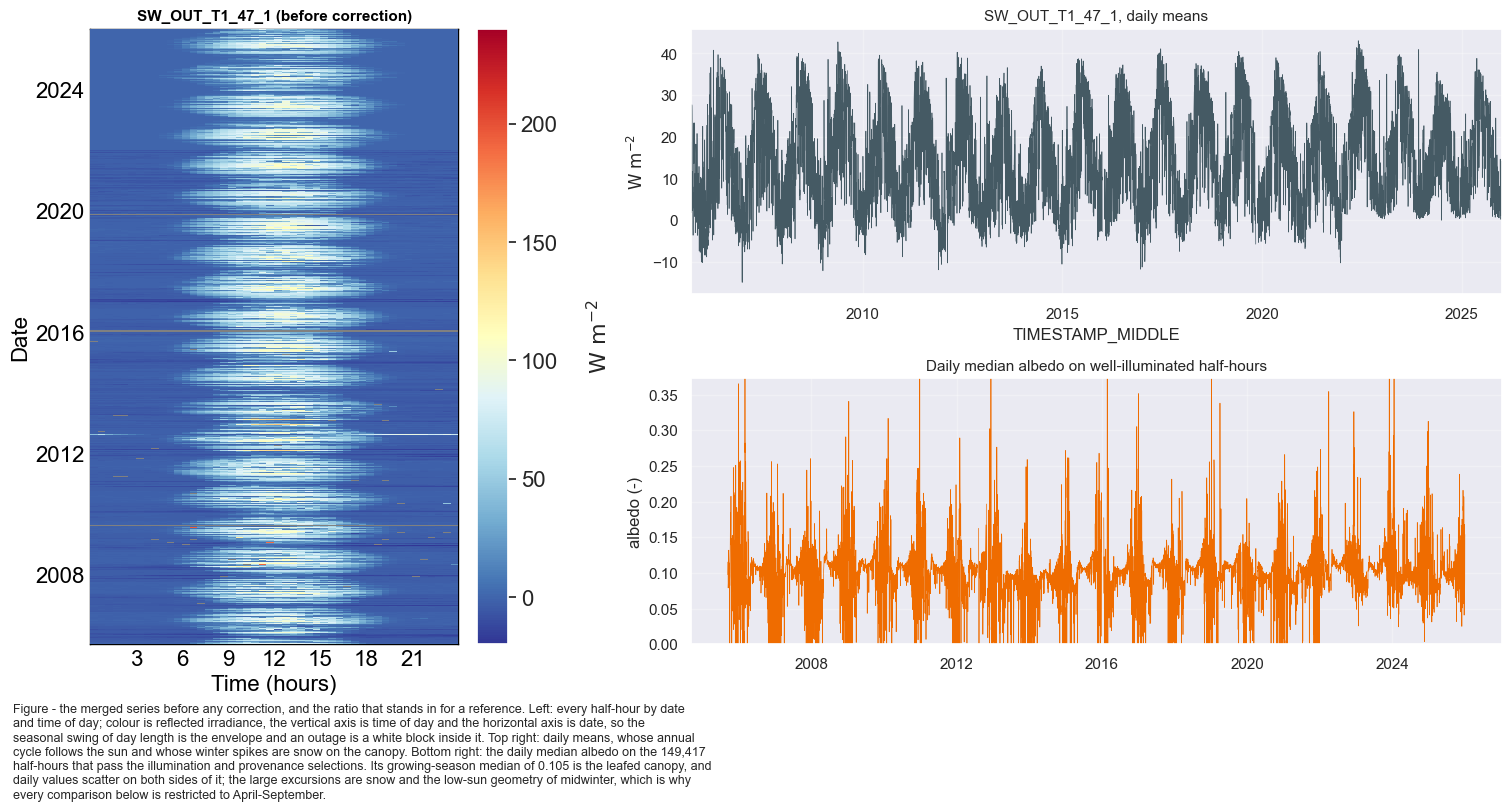

In [16]:
fig = plt.figure(figsize=(15, 8), dpi=100, layout='constrained')
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2.2], figure=fig)
ax_hm = fig.add_subplot(gs[:, 0])
ax_ts = fig.add_subplot(gs[0, 1])
ax_al = fig.add_subplot(gs[1, 1])

dv.plotting.HeatmapDateTime(series=sw_2005_2025[TARGET]).plot(
    ax=ax_hm, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title=f'{TARGET} (before correction)', title_fontsize=11))

sw_2005_2025[TARGET].resample('1D').mean().plot(ax=ax_ts, lw=0.5, color='#455A64')
ax_ts.set_ylabel(r'$\mathrm{W\ m^{-2}}$')
ax_ts.set_title(f'{TARGET}, daily means', fontsize=11)
ax_ts.grid(alpha=0.3)

_alb_daily = albedo(sw_2005_2025[TARGET]).resample('1D').median()
ax_al.plot(_alb_daily.index, _alb_daily.values, lw=0.5, color='#EF6C00')
ax_al.set_ylabel('albedo (-)')
ax_al.set_ylim(0, min(1.0, float(np.nanpercentile(_alb_daily.dropna(), 99.5)) * 1.4))
ax_al.set_title('Daily median albedo on well-illuminated half-hours', fontsize=11)
ax_al.grid(alpha=0.3)

figcap(fig, f"the merged series before any correction, and the ratio that stands in for a reference. "
            f"Left: every half-hour by date and time of day; colour is reflected irradiance, the "
            f"vertical axis is time of day and the horizontal axis is date, so the seasonal swing of "
            f"day length is the envelope and an outage is a white block inside it. Top right: daily "
            f"means, whose annual cycle follows the sun and whose winter spikes are snow on the "
            f"canopy. Bottom right: the daily median albedo on the "
            f"{int(albedo(sw_2005_2025[TARGET]).notna().sum()):,} half-hours that pass the "
            f"illumination and provenance selections. Its growing-season median of "
            f"{float(_alb_daily.loc[_alb_daily.index.month.isin(ALBEDO_MONTHS)].median()):.3f} is "
            f"the leafed canopy, and daily values scatter on both sides of it; the large excursions "
            f"are snow and the low-sun geometry of midwinter, which is why every comparison below "
            f"is restricted to April-September.")

***

## ✴️ Corrections

**Order of operations.** Each step has to run before the next one.

1. **Timestamp shift**, August 2012, so every window after it is on the corrected time axis.
2. **Removal of damaged periods**: the 2012 windows and the half-hour of the radiometer exchange.
   Neither then contributes to the offset fitted next.
3. **The nighttime zero-offset**, last. It is the only step that changes values, and it is fitted
   from the record it is applied to.

Step 3 is also the only step that can write a value into a missing record, so the gap mask is
captured immediately before it and restored immediately after.

::: {.callout-note title="Nighttime zeros in the diive era are values, not gaps"}
The screening notebook applies `mscr.correction_remove_nighttime_zero_offset()` on the 1MIN data,
which sets every nighttime position to zero, `NaN` included. For this variable that is correct
rather than a defect: with no incoming shortwave there is no reflected shortwave, so a nighttime
zero states a physical fact. Those records are kept as they stand and are not restored to gaps.

One consequence is worth knowing when reading the coverage numbers below. A nighttime zero in the
`diive` era is a known value rather than a delivered measurement, so coverage counts it as measured.
The `mst` era never had this correction applied, which is why its nighttime values carry the offset
that step 3 measures and removes.
:::

### 1️⃣ Timestamp shift in August 2012

**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

This is a clock error of the logger, so it affects **every variable that logger recorded**.
`SW_OUT_T1_47_1` sits on tower 1 at 47 m, on the same acquisition system as `SW_IN_T1_47_1`,
`TA_T1_47_1`, `PPFD_IN_T1_47_1` and `PA_T1_47_1`. The same `+15.5 h` correction is applied.

This variable can **check** the shift, which `LW_IN` in notebook `06` could not. Reflected shortwave
follows the sun, so a 15.5 h error puts the daily maximum in the middle of the night. The cell after
the shift measures the daily correlation against potential radiation before and after. The threshold
it is judged against comes from the record itself.

In [17]:
ISSUE_START = '2012-08-09 00:00'
ISSUE_END = '2012-08-17 00:00'
SHIFT_HOURS = 15.5

_df = sw_2005_2025.copy()
_before_shift = _df[TARGET].copy()   # kept for the before/after comparison and the plot

# Take the mis-stamped block and move it onto the correct time axis.
_orig_idx = _df.loc[ISSUE_START:ISSUE_END, TARGET].dropna().index
_series_shifted = _df.loc[_orig_idx, TARGET].copy()
_series_shifted.index = _orig_idx + pd.Timedelta(hours=SHIFT_HOURS)

# Clear everything between the start of the issue and the last shifted timestamp, then write the
# corrected values back. Same procedure as notebooks 01-03, 05 and 06.
_df.loc[ISSUE_START:_series_shifted.index[-1], TARGET] = np.nan
_df.loc[_series_shifted.index, TARGET] = _series_shifted

# The provenance masks have to make the same journey as the values they describe. A record that is
# carried out of the mst era and lands in a slot the mst version never covered would otherwise keep
# the provenance of the slot it arrived in rather than of the measurement it is, and the exported
# screening flag would say diive for a value the MeteoScreeningTool produced. That is not
# hypothetical: this block lands in August 2012, seven years before the diive screening begins.
def shift_mask(mask: pd.Series) -> pd.Series:
    """Move the same set of records the value shift moves, and blank what they vacate."""
    out = mask.copy()
    _carried = mask.loc[_orig_idx].to_numpy()
    out.loc[ISSUE_START:_series_shifted.index[-1]] = False
    out.loc[_series_shifted.index] = _carried
    return out


_measured_before = int(sw_2005_2025[TARGET].notna().sum())
_mst_before, _diive_before = int(FROM_MST.sum()), int(FROM_DIIVE.sum())
FROM_MST = shift_mask(FROM_MST)
FROM_DIIVE = shift_mask(FROM_DIIVE)

# The shift is not only a move. The hours the block vacates are blanked and not written back, so any
# value that stood there is discarded along with its provenance. That is the procedure 01-03 and 06
# use, and it is deliberate: those stamps are the ones the clock was wrong about. It is recorded in
# the ledger so the export's record arithmetic stays complete.
_vacated = _measured_before - int(_df[TARGET].notna().sum())
REMOVALS['records vacated by the August 2012 clock shift'] = _vacated

print(f"shifted {len(_series_shifted):,} records by +{SHIFT_HOURS} h")
print(f"last shifted timestamp (corrected axis): {_series_shifted.index[-1]}")
print(f"provenance carried with them: mst {int(FROM_MST.sum()):,} records "
      f"(was {_mst_before:,}), diive {int(FROM_DIIVE.sum()):,} (was {_diive_before:,})")
print(f"records discarded with the hours the block vacated: {_vacated:,}")

# The invariant that matters, and it is not a restatement of the line above it: a half-hour has a
# value if and only if one of the two screenings supplied one. That held before the shift, because
# the merge built the masks from exactly those two series, so it has to hold after it. It can only
# hold if the masks made the same journey as the values, which is what this cell is for.
assert bool((FROM_MST | FROM_DIIVE).equals(_df[TARGET].notna())), (
    "after the timestamp shift, the records that carry a value are no longer exactly the records a "
    "screening is credited with. The provenance masks have not made the same journey as the values, "
    "so the exported screening flag would describe the wrong half-hours")
assert not bool((FROM_MST & FROM_DIIVE).any()), \
    "a record is now credited to both screenings, which the shift must not be able to produce"

shifted 376 records by +15.5 h
last shifted timestamp (corrected axis): 2012-08-17 11:15:00
provenance carried with them: mst 282,776 records (was 282,776), diive 70,048 (was 70,048)
records discarded with the hours the block vacated: 0


In [18]:
def daily_potrad_corr(series: pd.Series) -> pd.Series:
    """Correlation of a series against potential radiation, one value per day.

    Potential radiation is astronomical, so a day whose stamps are right correlates with it whatever
    the weather did, and a day whose stamps are hours out does not. This is the check that longwave
    cannot run and shortwave can.
    """
    d = pd.concat([series.rename('s'), POTRAD.rename('p')], axis=1).dropna()
    d = d[d.groupby(d.index.date)['s'].transform('count') >= 24]   # half a day at least
    return d.groupby(d.index.date).apply(lambda g: g['s'].corr(g['p'])).dropna()


_shifted_days = sorted({t.date() for t in _series_shifted.index})
_corr_before = daily_potrad_corr(_before_shift)
_corr_after = daily_potrad_corr(_df[TARGET])
# The threshold is what the record itself does on an ordinary day, not a number chosen here.
_floor = float(_corr_after.quantile(0.05))
_b = _corr_before.reindex(_shifted_days).dropna()
_c = _corr_after.reindex(_shifted_days).dropna()

tabcap("the daily correlation against potential radiation on the days the shift touches, before and "
       "after it, against what the whole record does. The comparison threshold is the record's own "
       "5th percentile rather than a number chosen here")
display(pd.DataFrame({
    'days': [len(_b), len(_c), len(_corr_after)],
    'median daily correlation': [round(float(_b.median()), 4), round(float(_c.median()), 4),
                                 round(float(_corr_after.median()), 4)],
    'worst day': [round(float(_b.min()), 4), round(float(_c.min()), 4),
                  round(float(_corr_after.min()), 4)],
}, index=['shifted days, before', 'shifted days, after', 'whole record, after']))

print(f"record's 5th percentile of daily correlation: {_floor:.4f}")
assert float(_c.median()) > float(_b.median()), (
    "the +15.5 h shift did not improve the agreement with solar geometry on the days it touches, so "
    "either the window, the direction or the size of the shift is wrong")
assert float(_c.median()) > _floor, (
    f"after the shift the affected days still correlate with potential radiation at only "
    f"{float(_c.median()):.3f}, below the record's own 5th percentile of {_floor:.3f}. The block is "
    f"not on the right time axis")
print("\nOK: the shift moves the affected days from disagreement with solar geometry into the range "
      "the rest of the record occupies. Unlike LW_IN in notebook 06, this variable can test it.")

sw_2005_2025 = _df.copy()

Table - the daily correlation against potential radiation on the days the shift touches, before and
after it, against what the whole record does. The comparison threshold is the record's own 5th
percentile rather than a number chosen here



,days,median daily correlation,worst day
"shifted days, before",9,-0.5437,-0.6142
"shifted days, after",8,0.9768,0.9156
"whole record, after",7360,0.9162,-0.4464


record's 5th percentile of daily correlation: 0.6635

OK: the shift moves the affected days from disagreement with solar geometry into the range the rest of the record occupies. Unlike LW_IN in notebook 06, this variable can test it.


### 📊 Plot: the August 2012 clock shift

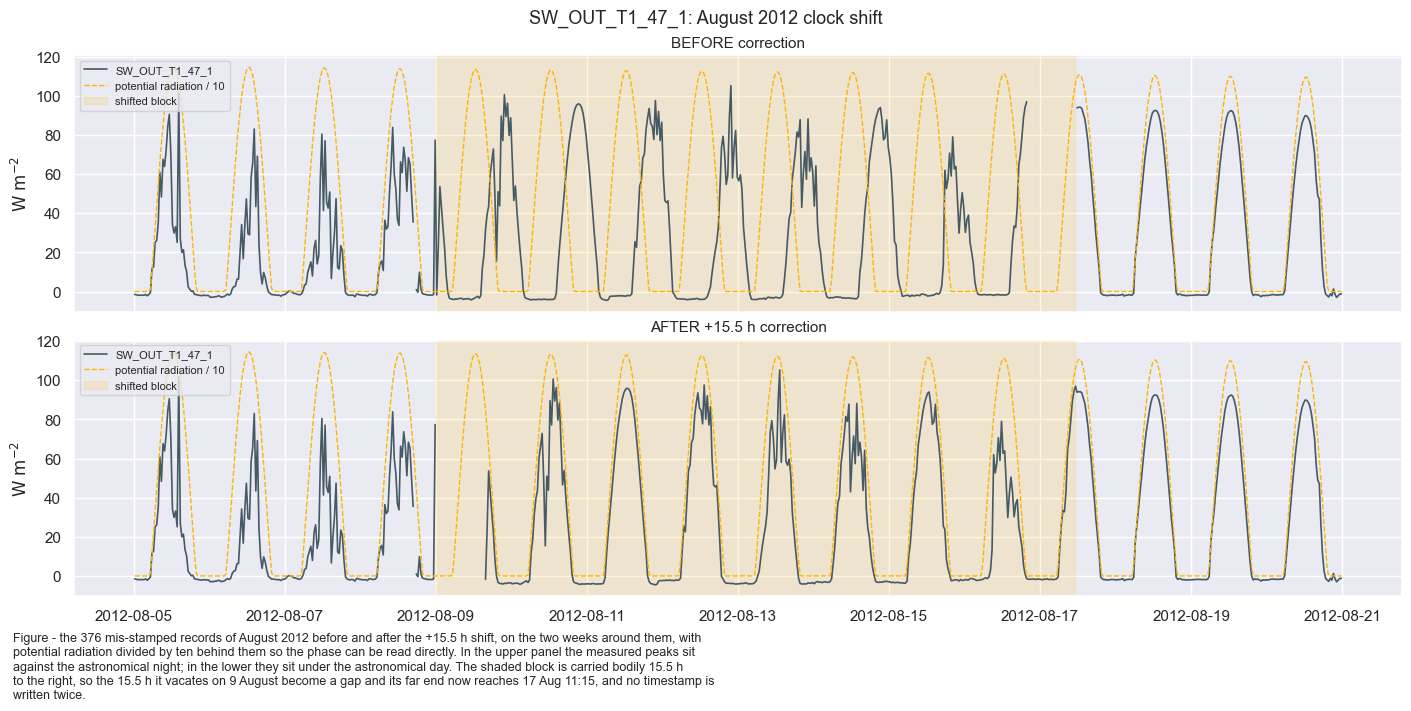

In [19]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained',
                        sharex=True, sharey=True)
fig.suptitle(f'{TARGET}: August 2012 clock shift', fontsize=13)
_win = slice('2012-08-05', '2012-08-20')

for _ax, _series, _title in [(axs[0], _before_shift, 'BEFORE correction'),
                             (axs[1], sw_2005_2025[TARGET], f'AFTER +{SHIFT_HOURS} h correction')]:
    _ax.plot(_series.loc[_win].index, _series.loc[_win].values, color='#455A64', lw=1.2,
             label=TARGET)
    _ax.plot(POTRAD.loc[_win].index, POTRAD.loc[_win].values / 10.0, color='#FFB300', lw=1.0,
             ls='--', label='potential radiation / 10')
    _ax.axvspan(pd.Timestamp('2012-08-09'), _series_shifted.index[-1], color='#FFC107', alpha=.15,
                label='shifted block')
    _ax.set_title(_title, fontsize=11)
    _ax.set_ylabel(r'$\mathrm{W\ m^{-2}}$')
    _ax.legend(fontsize=8, loc='upper left')

figcap(fig, f"the {len(_series_shifted):,} mis-stamped records of August 2012 before and after the "
            f"+{SHIFT_HOURS} h shift, on the two weeks around them, with potential radiation divided "
            f"by ten behind them so the phase can be read directly. In the upper panel the measured "
            f"peaks sit against the astronomical night; in the lower they sit under the astronomical "
            f"day. The shaded block is carried bodily {SHIFT_HOURS} h to the right, so the "
            f"{SHIFT_HOURS} h it vacates on 9 August become a gap and its far end now reaches "
            f"{_series_shifted.index[-1]:%d %b %H:%M}, and no timestamp is written twice.")

### 2️⃣ Damaged periods in 2012

Notebooks `01`, `02`, `03` and `06` remove three windows in 2012, caused by a tower power supply
failure in late July / early August and by storm damage and stressed cables in late October / early
November, both documented in the fieldbook:

> **09.08.2012** Fixed the power problem on the tower: replaced battery and replaced some fuses
> (there were many falsely placed or broken) and replaced the whole power supply
>
> **01.11.2012** Checked Forestfloor and Hut for broken sensors due to fallen trees and big branches
>
> **06.11.2012** checked all sensor cables. especialy the cables at the forest floor are sometimes
> strongly stressed. tried to unstress the cables

The windows are removed here too, for the same reason as in `06`. A documented, logger-wide fault
covers them, and the test available inside this variable is underpowered against it. The albedo can
see a fault confined to the reflected channel, because the incoming channel is the reference. It
cannot see one that moved both channels of the same head together, which is what a power supply
problem would do. Absence of evidence in the table below is therefore not evidence of cleanliness.
Narrowing a window would need positive evidence, which `05` had for `PA` and this variable does not.

In [20]:
# Identical to notebooks 01-03 and 06. Windows are on the CORRECTED time axis (after the +15.5 h
# shift). Kept deliberately wide, for the reason given above.
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    # Inherited from 01-03 unchanged, and deliberately not re-derived. It does NOT begin where the
    # shifted block ends: the last shifted stamp on the corrected axis is 2012-08-17 11:15, four
    # hours before this window opens. Whatever it was drawn around in 01, narrowing or moving it
    # here would make this product disagree with the other tower variables about the same hours for
    # no reason this notebook can give.
    ('2012-08-17 15:30', '2012-08-18 00:00'),
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]
print(f"last shifted timestamp on the corrected axis: {_series_shifted.index[-1]}")
print(f"the inherited second window opens at:         {BAD_WINDOWS_2012[1][0]}")

# What the windows look like from inside this variable, computed rather than quoted so that a future
# re-run cannot silently disagree with the text above.
_alb_2012 = albedo(sw_2005_2025[TARGET])
_rows = []
for _lo, _hi, _lab in [('2012-06-01', '2012-07-25', 'baseline 1 Jun - 25 Jul'),
                       ('2012-07-29', '2012-08-10', 'window 1 (power supply)'),
                       ('2012-10-28', '2012-11-10', 'window 3 (storm damage)'),
                       ('2012-11-11', '2012-12-15', 'baseline 11 Nov - 15 Dec')]:
    _a = _alb_2012.loc[_lo:_hi].dropna()
    _v = sw_2005_2025.loc[_lo:_hi, TARGET]
    _rows.append({'period': _lab, 'albedo half-hours': int(len(_a)),
                  'albedo median': round(float(_a.median()), 4) if len(_a) else np.nan,
                  'albedo p10': round(float(_a.quantile(.10)), 4) if len(_a) else np.nan,
                  'albedo p90': round(float(_a.quantile(.90)), 4) if len(_a) else np.nan,
                  'measured (%)': round(100 * float(_v.notna().mean()), 1),
                  'repeated values': int(_v.dropna().diff().eq(0).sum())})
tabcap("what the two suspect 2012 windows look like from inside this variable, against the clean "
       "weeks around them. The albedo is the only internal test available and it cannot see a fault "
       "that moved both channels of one head together, which is the null result the text above "
       "discusses")
display(pd.DataFrame(_rows).set_index('period'))

_before_n = int(sw_2005_2025[TARGET].notna().sum())
_before_2012 = sw_2005_2025[TARGET].copy()
for _start, _end in BAD_WINDOWS_2012:
    sw_2005_2025.loc[_start:_end, TARGET] = np.nan
REMOVALS['damaged periods in 2012'] = _before_n - int(sw_2005_2025[TARGET].notna().sum())
print(f"Removed {REMOVALS['damaged periods in 2012']:,} records from {TARGET} on provenance grounds "
      f"(left as gaps, nothing is filled).")

last shifted timestamp on the corrected axis: 2012-08-17 11:15:00
the inherited second window opens at:         2012-08-17 15:30
Table - what the two suspect 2012 windows look like from inside this variable, against the clean
weeks around them. The albedo is the only internal test available and it cannot see a fault that
moved both channels of one head together, which is the null result the text above discusses



,albedo half-hours,albedo median,albedo p10,albedo p90,measured (%),repeated values
period,,,,,,
baseline 1 Jun - 25 Jul,1507,0.1067,0.0633,0.1153,99.7,0
window 1 (power supply),7,0.1121,0.1109,0.1134,94.2,0
window 3 (storm damage),15,0.0671,0.0203,0.0907,100.0,0
baseline 11 Nov - 15 Dec,466,0.1128,-0.0210,0.2547,99.9,1


Removed 1,212 records from SW_OUT_T1_47_1 on provenance grounds (left as gaps, nothing is filled).


### 📊 Plot: the 2012 periods removed

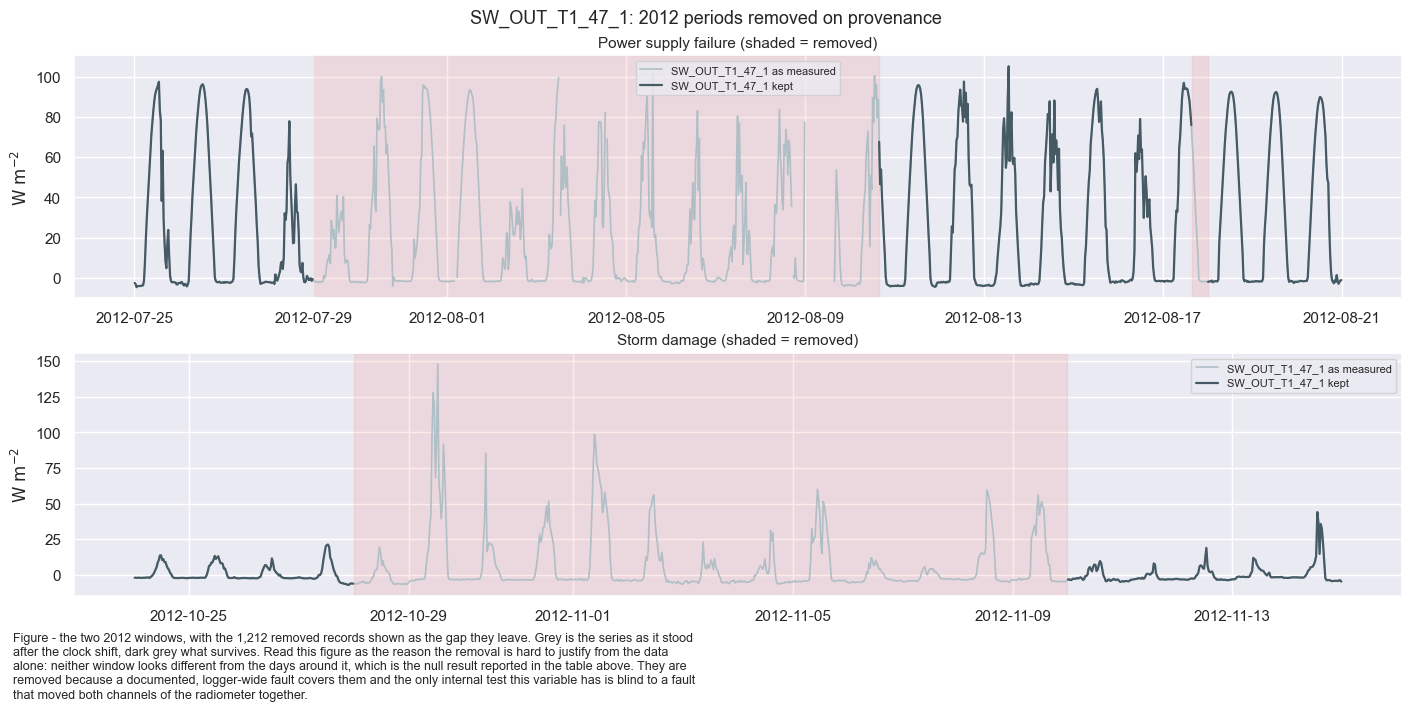

In [21]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained')
fig.suptitle(f'{TARGET}: 2012 periods removed on provenance', fontsize=13)

for _ax, (_lo, _hi, _label) in zip(axs, [('2012-07-25', '2012-08-20', 'Power supply failure'),
                                         ('2012-10-24', '2012-11-14', 'Storm damage')]):
    _w = slice(_lo, _hi)
    _ax.plot(_before_2012.loc[_w].index, _before_2012.loc[_w].values, color='#B0BEC5', lw=1.2,
             label=f'{TARGET} as measured')
    _ax.plot(sw_2005_2025[TARGET].loc[_w].index, sw_2005_2025[TARGET].loc[_w].values,
             color='#455A64', lw=1.6, label=f'{TARGET} kept')
    for _s, _e in BAD_WINDOWS_2012:
        if pd.Timestamp(_s) <= pd.Timestamp(_hi) and pd.Timestamp(_e) >= pd.Timestamp(_lo):
            _ax.axvspan(pd.Timestamp(_s), pd.Timestamp(_e), color='#F44336', alpha=.10)
    _ax.set_title(f'{_label} (shaded = removed)', fontsize=11)
    _ax.set_ylabel(r'$\mathrm{W\ m^{-2}}$')
    _ax.legend(fontsize=8, loc='best')

figcap(fig, f"the two 2012 windows, with the {REMOVALS['damaged periods in 2012']:,} removed records "
            f"shown as the gap they leave. Grey is the series as it stood after the clock shift, "
            f"dark grey what survives. Read this figure as the reason the removal is hard to justify "
            f"from the data alone: neither window looks different from the days around it, which is "
            f"the null result reported in the table above. They are removed because a documented, "
            f"logger-wide fault covers them and the only internal test this variable has is blind to "
            f"a fault that moved both channels of the radiometer together.")

### 3️⃣ The half-hour in which the radiometer was exchanged

The sibling channel dates the swap to the minute. The `LW_OUT` screening notebook removes one 1MIN
record, the minute declared as `INSTALL_ARTEFACT_MINUTE` in the settings, as the artefact of the old
instrument coming off its mount and the new one going on. The `SW_OUT` screening committed no manual
removal, so that minute is still in this series, inside the 30MIN mean that holds it.

It is removed here on **provenance**. The two channels are one instrument head, mounted and wired in
the same minutes by the same visit, and a half-hour in which a radiometer is handled is not a
measurement of the sky.

On the current record the removal takes nothing away, because that half-hour is already empty in both
screenings. The cell prints whether it held a value, and it is written to remove the record rather
than to assume the emptiness, for two reasons: a re-ingest of the raw record could put a value there,
and a half-hour that is empty by accident is not the same thing as one that is empty on purpose. The
table below shows the half-hour and its neighbours either way.

The days that follow are a separate matter. The new instrument was read through the old instrument's
constant there. Those days are flagged rather than removed, and the instrument section measures them.

In [22]:
INSTALL_MINUTE = pd.Timestamp(INSTALL_ARTEFACT_MINUTE)
INSTALL_HALFHOUR = (INSTALL_MINUTE.floor(REQUIRED_TIME_RESOLUTION)
                    + pd.Timedelta(REQUIRED_TIME_RESOLUTION) / 2)
assert INSTALL_HALFHOUR in full_index, \
    f"{INSTALL_HALFHOUR} is not on the exported index - the artefact minute or the index has moved"

_same_tod = sw_2005_2025[TARGET][
    (sw_2005_2025.index.time == INSTALL_HALFHOUR.time())
    & (sw_2005_2025.index >= INSTALL_HALFHOUR - pd.Timedelta(days=7))
    & (sw_2005_2025.index <= INSTALL_HALFHOUR + pd.Timedelta(days=7))].dropna()

_rows = []
for _t in [INSTALL_HALFHOUR - pd.Timedelta(hours=1), INSTALL_HALFHOUR - pd.Timedelta(minutes=30),
           INSTALL_HALFHOUR,
           INSTALL_HALFHOUR + pd.Timedelta(minutes=30), INSTALL_HALFHOUR + pd.Timedelta(hours=1)]:
    _v = sw_2005_2025.loc[_t, TARGET]
    _i = SW_IN_MEASURED.loc[_t]
    _rows.append({'TIMESTAMP_MIDDLE': _t,
                  'SW_OUT (W m-2)': round(float(_v), 2) if pd.notna(_v) else np.nan,
                  'SW_IN measured (W m-2)': round(float(_i), 2) if pd.notna(_i) else np.nan,
                  'ratio': round(float(_v / _i), 4) if pd.notna(_v) and pd.notna(_i) and _i > 0
                  else np.nan})
tabcap(f"the half-hour holding the radiometer swap and the two half-hours on either side of it. The "
       f"same time of day over the fortnight around it has a median of {float(_same_tod.median()):.2f}"
       f" W m-2 over {len(_same_tod)} days, which is the level this half-hour is read against")
display(pd.DataFrame(_rows).set_index('TIMESTAMP_MIDDLE'))

Table - the half-hour holding the radiometer swap and the two half-hours on either side of it. The
same time of day over the fortnight around it has a median of 6.50 W m-2 over 14 days, which is the
level this half-hour is read against



,SW_OUT (W m-2),SW_IN measured (W m-2),ratio
TIMESTAMP_MIDDLE,,,
2021-12-14 12:45:00,NaN,NaN,NaN
2021-12-14 13:15:00,NaN,NaN,NaN
2021-12-14 13:45:00,NaN,NaN,NaN
2021-12-14 14:15:00,NaN,NaN,NaN
2021-12-14 14:45:00,25.12,163.88,0.1533


In [23]:
_had_value = bool(pd.notna(sw_2005_2025.loc[INSTALL_HALFHOUR, TARGET]))
sw_2005_2025.loc[INSTALL_HALFHOUR, TARGET] = np.nan
REMOVALS['the half-hour of the radiometer swap'] = 1 if _had_value else 0

print(f"artefact minute (from the LW_OUT screening): {INSTALL_MINUTE}")
print(f"the 30MIN record holding it:                 {INSTALL_HALFHOUR}")
print(f"it held a value: {_had_value}   removed: "
      f"{REMOVALS['the half-hour of the radiometer swap']} record(s)")
assert bool(sw_2005_2025[TARGET].isna().loc[INSTALL_HALFHOUR]), \
    "the half-hour holding the instrument swap survived the removal"
if _had_value:
    print("\nOne half-hour is discarded on provenance.")
else:
    print("\nThat half-hour was already empty in both screenings, so this removal takes nothing "
          "away on the current record. It stands as a guard: if the raw record is ever re-ingested "
          "and a value appears there, it will be discarded rather than exported.")
print("Nothing else on 14 December 2021 is touched: the days that follow are flagged, not removed.")

artefact minute (from the LW_OUT screening): 2021-12-14 13:34:30
the 30MIN record holding it:                 2021-12-14 13:45:00
it held a value: False   removed: 0 record(s)

That half-hour was already empty in both screenings, so this removal takes nothing away on the current record. It stands as a guard: if the raw record is ever re-ingested and a value appears there, it will be discarded rather than exported.
Nothing else on 14 December 2021 is touched: the days that follow are flagged, not removed.


### 4️⃣ Nighttime zero-offset correction

A pyranometer reads a small non-zero signal at night. That signal is an instrument offset rather than
radiation, and it drifts, so it is removed per day rather than as one constant. It is done here, on
the merged record, because only one of the two screenings did it. The `diive` screening applied it on
the 1MIN data and the MeteoScreeningTool did not. Without this step the first sixteen years of the
product would carry an offset that the last four do not.

::: {.callout-warning title="This correction writes into gaps, so capture the mask first"}
`remove_nighttime_zero_offset()` forces **every** nighttime position to zero, `NaN` included. On a
gappy series it fills nighttime gaps with a real value, and every later step reads them as measured.
Notebook `03` fell into this and turned 7,543 modelled values into apparently measured ones. It is
the same trap the first correction section had to undo in the `diive` era, where it was sprung inside
the screening notebook on the 1MIN data.

The gap mask is therefore taken **before** the correction and restored **after**. The offset goes and
a gap stays a gap.
:::

Applying the correction to a record that is already corrected over part of its length is safe, and
the run shows this rather than asserting it. Over the `diive` era the daily offset comes out at
approximately zero, because that era's nights are already exactly zero. That is a check on the
screening as well as on this cell. A `diive` era offset that is **not** near zero would be a finding
about the screening notebook, and the assertion below turns it into one.

In [24]:
_series = sw_2005_2025[TARGET]
NZO_BEFORE = _series.copy()   # the uncorrected series, kept for the figure and the per-version table

# Capture the gap mask BEFORE correcting: the correction writes zeros into nighttime NaNs and would
# otherwise turn gaps into apparent measurements.
_gaps_before = _series.isna()

NZO = dv.corrections.nighttime_zero_offset_diagnostics(
    series=_series, lat=SITE_LAT, lon=SITE_LON, utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)

_corrected = NZO.corrected.copy()
_corrected[_gaps_before] = np.nan  # restore the gaps the correction just filled

# The correction must not have invented or destroyed data.
assert _corrected.isna().equals(_gaps_before), \
    "the gap structure changed across the nighttime zero-offset correction"
sw_2005_2025[TARGET] = _corrected
REMOVALS['nighttime zero-offset correction'] = 0

tabcap("what the correction removed, per data version. The mst era is the one that needed it; the "
       "diive era's offset comes out at approximately zero because its screening had already taken "
       "it out on the 1MIN data, which is what the assertion below requires")
_rows = []
for _lab, _mask in [('mst', FROM_MST), ('diive', FROM_DIIVE)]:
    _m = _mask & NZO_BEFORE.notna()
    _delta = (_corrected - NZO_BEFORE)[_m]
    _night_before = NZO_BEFORE[_m & FULLY_DARK]
    _rows.append({'data version': _lab, 'measured records': int(_m.sum()),
                  'nighttime reading before, median (W m-2)':
                      round(float(_night_before.median()), 3) if len(_night_before) else np.nan,
                  'daily offset, median (W m-2)': round(float(NZO.offset[_m].median()), 3),
                  'daily offset, min (W m-2)': round(float(NZO.offset[_m].min()), 3),
                  'daily offset, max (W m-2)': round(float(NZO.offset[_m].max()), 3),
                  'change to the values, median |dx| (W m-2)': round(float(_delta.abs().median()), 4),
                  'records changed by > 0.05 W m-2 (%)':
                      round(100 * float((_delta.abs() > 0.05).mean()), 3)})
display(pd.DataFrame(_rows).set_index('data version'))

Table - what the correction removed, per data version. The mst era is the one that needed it; the
diive era's offset comes out at approximately zero because its screening had already taken it out on
the 1MIN data, which is what the assertion below requires



,measured records,"nighttime reading before, median (W m-2)","daily offset, median (W m-2)","daily offset, min (W m-2)","daily offset, max (W m-2)","change to the values, median |dx| (W m-2)",records changed by > 0.05 W m-2 (%)
data version,,,,,,,
mst,281564,-3.295,-3.182,-17.309,9.633,3.1333,99.91
diive,70048,0.000,0.000,0.000,0.000,0.0000,0.00


In [25]:
# Tolerance for the era that was already corrected. 0.05 W m-2 is an order of magnitude below the
# pyranometer's own nighttime scatter and far below the offset the mst era carries, so a correction
# that is genuinely a no-op sits under it. The 1 % allowance is for days whose night is entirely
# missing: those get the record's median offset rather than their own, and their daytime values move
# with it.
DIIVE_NOOP_TOLERANCE_WM2 = 0.05
DIIVE_NOOP_MAX_SHARE = 0.01

_m = FROM_DIIVE & NZO_BEFORE.notna()
_delta = (_corrected - NZO_BEFORE)[_m]
_share = float((_delta.abs() > DIIVE_NOOP_TOLERANCE_WM2).mean())
print(f"diive era: median |change| {float(_delta.abs().median()):.5f} W m-2, "
      f"{100 * _share:.3f} % of records changed by more than {DIIVE_NOOP_TOLERANCE_WM2} W m-2")
assert float(_delta.abs().median()) < DIIVE_NOOP_TOLERANCE_WM2 and _share < DIIVE_NOOP_MAX_SHARE, (
    f"the nighttime zero-offset correction changes the diive era by more than a no-op should. That "
    f"era is supposed to arrive already corrected from its screening notebook, so either the "
    f"screening no longer applies correction_remove_nighttime_zero_offset(), or it is being applied "
    f"twice. Find out which before exporting")

# What is worth checking here, and what is not. diive's remove_nighttime_zero_offset ends with
# `final.loc[nighttime_ix] = 0` and then `final.loc[final < 0] = 0`, so "no negatives remain" and
# "every nighttime record is exactly zero" are true by construction whatever the data did. Rebuilding
# the day/night flag from the same coordinates and the same threshold the function used internally
# does not make them checks either. One of them is kept, cheaply, because it would catch a future
# diive that stopped clamping; the other is replaced by something the function does not guarantee.
_dnf = dv.variables.DaytimeNighttimeFlag(
    timestamp_index=sw_2005_2025.index, nighttime_threshold=0.001,
    lat=SITE_LAT, lon=SITE_LON, utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
_is_night = _dnf.get_nighttime_flag() == 1
_s = sw_2005_2025[TARGET]
_measured = _s.notna()
_n_negative = int((_s[_measured] < 0).sum())
print(f"\nNighttime records: {int(_is_night.sum()):,} of {len(sw_2005_2025):,}")
print(f"  negatives after the correction: {_n_negative:,}")
assert _n_negative == 0, f'{_n_negative} negative values remain after the correction'

# The clamp is a SECOND change to the values, and it is not the one the correction is for. Removing
# an offset is meant to move the whole record by the day's offset; setting a daytime half-hour to
# zero because subtracting a positive offset took it below zero is a truncation of a real, if small,
# measurement. It only happens on days whose offset is positive, and only where the flux is below
# that offset, so it should touch a small share of daylight. That share is what is bounded here.
_daytime_measured = _measured & ~_is_night
_clamped = (NZO.corrected_by_offset < 0) & _daytime_measured
_n_clamped = int(_clamped.sum())
_share_clamped = _n_clamped / max(int(_daytime_measured.sum()), 1)
_worst = float(NZO.corrected_by_offset[_clamped].min()) if _n_clamped else 0.0
print(f"  measured daylight records:      {int(_daytime_measured.sum()):,}")
print(f"  of those, clamped up to zero:   {_n_clamped:,} ({100 * _share_clamped:.2f} %)")
print(f"  furthest below zero before the clamp: {_worst:.2f} W m-2")

# The bound. Clamping can only reach half-hours whose flux is below the day's offset, and the daily
# offset here is at most a few W m-2 positive, so only the dimmest edges of daylight are exposed to
# it. More than a twentieth of daylight would mean the offset is being applied where it does not
# belong, and that is a finding rather than a nuisance.
CLAMPED_DAYTIME_MAX_SHARE = 0.05
assert _share_clamped < CLAMPED_DAYTIME_MAX_SHARE, (
    f"the offset removal clamped {100 * _share_clamped:.1f} % of measured daylight records to zero, "
    f"against a bound of {100 * CLAMPED_DAYTIME_MAX_SHARE:.0f} %. Those records are truncated "
    f"rather than corrected, so an offset of the wrong sign or size is being applied in daylight")
print(f"\nOK: no negatives survive, and the clamp reaches {100 * _share_clamped:.2f} % of measured "
      f"daylight, inside the {100 * CLAMPED_DAYTIME_MAX_SHARE:.0f} % bound.")

diive era: median |change| 0.00000 W m-2, 0.000 % of records changed by more than 0.05 W m-2

Nighttime records: 170,475 of 355,872
  negatives after the correction: 0
  measured daylight records:      183,331
  of those, clamped up to zero:   4,526 (2.47 %)
  furthest below zero before the clamp: -13.82 W m-2

OK: no negatives survive, and the clamp reaches 2.47 % of measured daylight, inside the 5 % bound.


### 📊 Plot: the nighttime zero-offset correction

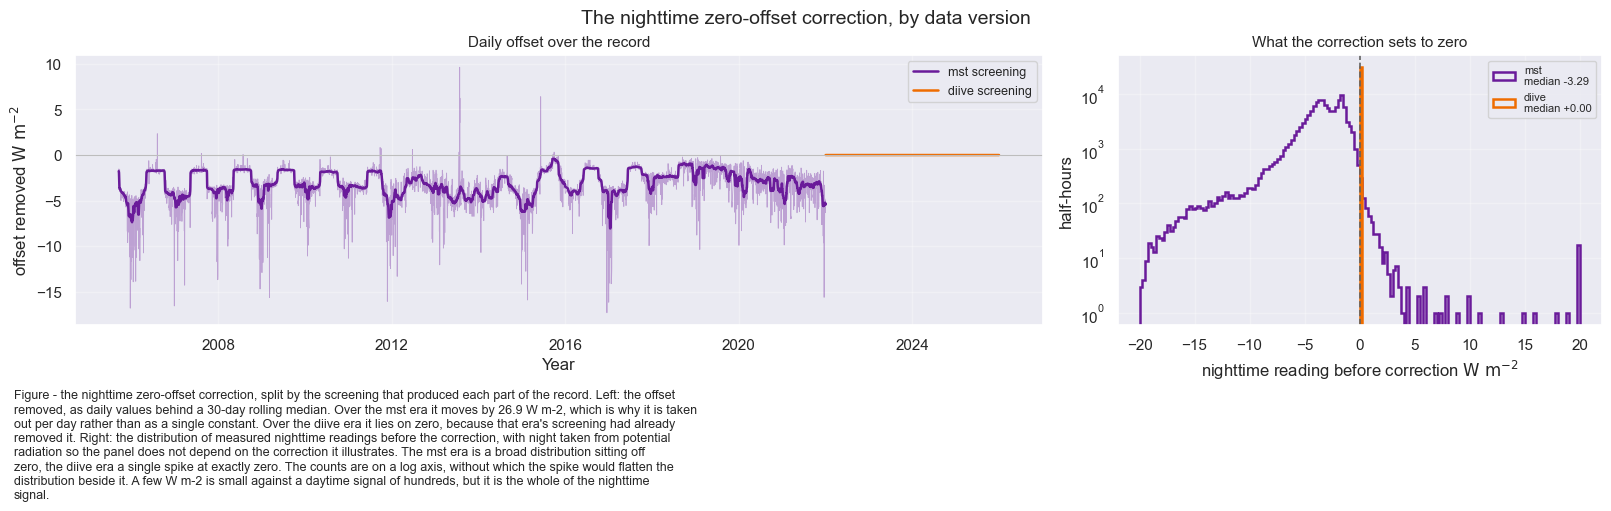

In [26]:
# The correction, drawn. Left: the daily offset over the record, per data version. Right: the
# distribution of measured nighttime readings before the correction, which is the quantity the
# correction sets to zero.
fig, axs = plt.subplots(ncols=2, figsize=(16, 5), dpi=100, layout='constrained',
                        width_ratios=[2, 1])
fig.suptitle('The nighttime zero-offset correction, by data version', fontsize=14)

for _lab, _mask, _colour in [('mst', FROM_MST, '#6A1B9A'), ('diive', FROM_DIIVE, '#EF6C00')]:
    _off = NZO.offset.where(_mask & NZO_BEFORE.notna()).resample('D').mean().dropna()
    axs[0].plot(_off.index, _off, color=_colour, lw=0.6, alpha=0.35)
    axs[0].plot(_off.index, _off.rolling(30, center=True, min_periods=10).median(),
                color=_colour, lw=1.8, label=f'{_lab} screening')
axs[0].axhline(0, color='#BDBDBD', lw=0.8)
axs[0].set_xlabel('Year')
axs[0].set_ylabel(r'offset removed $\mathrm{W\ m^{-2}}$')
axs[0].set_title('Daily offset over the record', fontsize=11)
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=9)

# Night from potential radiation, so this panel does not depend on the correction it illustrates.
_bins = np.linspace(-20, 20, 161)
for _lab, _mask, _colour in [('mst', FROM_MST, '#6A1B9A'), ('diive', FROM_DIIVE, '#EF6C00')]:
    _vals = NZO_BEFORE[_mask & FULLY_DARK].dropna()
    if len(_vals):
        axs[1].hist(_vals.clip(_bins[0], _bins[-1]), bins=_bins, histtype='step', lw=1.8,
                    color=_colour, label=f'{_lab}\nmedian {_vals.median():+.2f}')
axs[1].axvline(0, color='#616161', lw=1.2, ls='--')
axs[1].set_yscale('log')
axs[1].set_xlabel(r'nighttime reading before correction $\mathrm{W\ m^{-2}}$')
axs[1].set_ylabel('half-hours')
axs[1].set_title('What the correction sets to zero', fontsize=11)
axs[1].grid(alpha=0.3)
axs[1].legend(fontsize=8)

_span = float(NZO.offset[FROM_MST].max() - NZO.offset[FROM_MST].min())
figcap(fig, f"the nighttime zero-offset correction, split by the screening that produced each part "
            f"of the record. Left: the offset removed, as daily values behind a 30-day rolling "
            f"median. Over the mst era it moves by {_span:.1f} W m-2, which is why it is taken out "
            f"per day rather than as a single constant. Over the diive era it lies on zero, because "
            f"that era's screening had already removed it. Right: the distribution of measured "
            f"nighttime readings before the correction, with night taken from potential radiation so "
            f"the panel does not depend on the correction it illustrates. The mst era is a broad "
            f"distribution sitting off zero, the diive era a single spike at exactly zero. The "
            f"counts are on a log axis, without which the spike would flatten the distribution "
            f"beside it. A few W m-2 is small against a daytime signal of hundreds, but it is the "
            f"whole of the nighttime signal.")

### Timestamp alignment over the whole record

The August 2012 check above speaks for eight days, so the same statistic is run over the whole record
to make sure no systematic timestamp error survives anywhere else. A wrong timezone offset, or an
end-to-middle conversion applied twice, would move every value in the file, and neither a range check
nor an outlier test would notice, because every value would still be perfectly plausible.

### 📊 Plot: diurnal cycle against potential radiation

mean diurnal peak, measured:  12:45:00
mean diurnal peak, potential: 12:15:00  (1 half-hour bin(s) apart)
solar noon from potential radiation (centroid): 12:27
centroid, measured 12.388 h   potential 12.451 h   apart 3.7 min


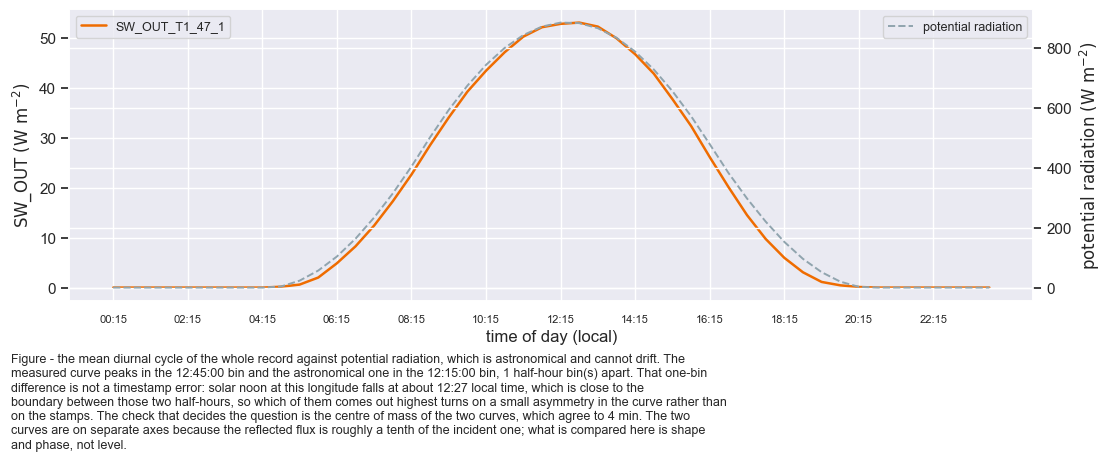

In [27]:
_tod = sw_2005_2025[TARGET].groupby(sw_2005_2025.index.time).mean()
_tod_pot = POTRAD.groupby(POTRAD.index.time).mean()
_peak_obs, _peak_pot = _tod.idxmax(), _tod_pot.idxmax()
_bins_apart = abs(list(_tod.index).index(_peak_obs) - list(_tod_pot.index).index(_peak_pot))


def diurnal_centroid(tod: pd.Series) -> float:
    """Centre of mass of a mean diurnal cycle, in hours of local time.

    The peak bin alone is a blunt statistic: solar noon here falls close to a bin boundary, so which
    of the two half-hours either side of it comes out highest is decided by a small asymmetry rather
    than by anything about the timestamps. The centroid uses the whole curve and moves by the full
    amount of any real shift.
    """
    hours = np.array([t.hour + t.minute / 60 for t in tod.index])
    w = tod.to_numpy(dtype=float)
    w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
    return float((hours * w).sum() / w.sum())


_c_obs, _c_pot = diurnal_centroid(_tod), diurnal_centroid(_tod_pot)
_centroid_gap = abs(_c_obs - _c_pot)

print(f"mean diurnal peak, measured:  {_peak_obs}")
print(f"mean diurnal peak, potential: {_peak_pot}  ({_bins_apart} half-hour bin(s) apart)")
print(f"solar noon from potential radiation (centroid): {int(_c_pot)}:{round((_c_pot % 1) * 60):02d}")
print(f"centroid, measured {_c_obs:.3f} h   potential {_c_pot:.3f} h   "
      f"apart {60 * _centroid_gap:.1f} min")

assert _bins_apart <= 1, (
    f"the mean diurnal cycle peaks {_bins_apart} half-hours away from solar noon. Either the "
    f"timezone offset or the end/middle timestamp conversion is wrong, and every value in this "
    f"product would be on the wrong half-hour")
# The tighter of the two checks, and the one that would catch a shift the peak-bin test can hide.
# Half an hour is one bin; a timestamp fault of the kind this test exists for is hours.
CENTROID_TOLERANCE_H = 0.5
assert _centroid_gap < CENTROID_TOLERANCE_H, (
    f"the measured diurnal cycle sits {60 * _centroid_gap:.0f} min away from the astronomical one "
    f"by centre of mass, against a tolerance of {60 * CENTROID_TOLERANCE_H:.0f} min. The peak-bin "
    f"test can be fooled by solar noon falling near a bin boundary; this one cannot")

fig, ax = plt.subplots(figsize=(11, 4.5), dpi=100, layout='constrained')
ax.plot(range(len(_tod)), _tod.values, color='#EF6C00', lw=1.8, label=TARGET)
ax2 = ax.twinx()
ax2.plot(range(len(_tod_pot)), _tod_pot.values, color='#90A4AE', lw=1.4, ls='--',
         label='potential radiation')
ax.set_xticks(range(0, len(_tod), 4))
ax.set_xticklabels([str(t)[:5] for t in _tod.index[::4]], fontsize=8)
ax.set_ylabel(r'$\mathrm{SW\_OUT\ (W\ m^{-2})}$')
ax2.set_ylabel(r'$\mathrm{potential\ radiation\ (W\ m^{-2})}$')
ax.set_xlabel('time of day (local)')
ax.legend(fontsize=9, loc='upper left')
ax2.legend(fontsize=9, loc='upper right')
figcap(fig, f"the mean diurnal cycle of the whole record against potential radiation, which is "
            f"astronomical and cannot drift. The measured curve peaks in the {_peak_obs} bin and "
            f"the astronomical one in the {_peak_pot} bin, {_bins_apart} half-hour bin(s) apart. "
            f"That one-bin difference is not a timestamp error: solar noon at this longitude falls "
            f"at about {int(_c_pot)}:{round((_c_pot % 1) * 60):02d} local time, which is close to "
            f"the boundary between those two half-hours, so which of them comes out highest turns "
            f"on a small asymmetry in the curve rather than on the stamps. The check that decides "
            f"the question is the centre of mass of the two curves, which agree to "
            f"{60 * _centroid_gap:.0f} min. The two curves are on separate axes because the "
            f"reflected flux is roughly a tenth of the incident one; what is compared here is shape "
            f"and phase, not level.")

***

## 🔎 The instrument, its constants, and the four dates

Four dates in this record are hardware or software events. A hardware change is a hypothesis about
the data, so each has to be answered rather than assumed.

- **21 January 2016.** The tower logger was replaced, CR10X to CR1000. It moved `TA` by 1.3 °C.
- **7 June 2016.** The fieldbook records the radiometer's calibration factor being corrected from
  10.03 to 12.83 µV/W/m². Notebook `06` finds that change in `LW_IN`. Notebook `01` finds no change
  in `SW_IN` at either 2016 date. Whether the outgoing shortwave channel was touched is a separate
  question, and this notebook has to ask it.
- **14 December 2021.** The CNR1 was replaced by a CNR4, whose four channels carry four different
  sensitivities.
- **7 January 2022.** Those sensitivities reached the logger program, 24 days later.

A pyranometer produces microvolts. The number in this file is that voltage divided by a calibration
constant, so the identity of the constant is the identity of the measurement. The programs are read
first, then the maintenance record, then the albedo.

### Helpers for this section

The logger programs and the maintenance record are read in the notebook rather than quoted, so a
re-run re-derives the argument instead of inheriting a stale copy. Both are signed by the people who
did the work, and this notebook renders to a public page, so every string taken out of either passes
through the same redaction used in notebooks `01`, `02`, `06` and `08`.

In [28]:
# --- Fieldbook and logger-script redaction ----------------------------------------------------
# The GIN export and the logger programs both name people. This notebook renders to a public page, so
# every string taken out of either passes through redact_people() at the single point where it is
# flattened. Same map and same rules as notebooks 01, 02, 06 and 08; the map lives beside the export,
# OUTSIDE this repository, so the repo never carries a real name.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')


def unmapped_report_path(label: str) -> Path:
    """Where the unmapped-name candidates of one audit are written.

    Per label, because this notebook audits two sources: a single shared file would let the second
    audit overwrite the first one's findings.
    """
    _slug = re.sub(r'[^a-z0-9]+', '_', label.lower()).strip('_')
    return Path(FIELDBOOK).with_name(f'redact_unmapped_{_slug}.txt')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map.

    Raises if the map is missing. That is the point: carrying on with redaction quietly disabled
    prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the redaction map is missing: {path}. Without it the names these files record would "
            f"print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()
# Longest surface form first, so a bare surname cannot corrupt a double-barrelled one that starts
# with it. Lookarounds rather than \b, because some forms end in an initial.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped name with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


def strip_html(text) -> str:
    """Flatten one GIN fieldbook entry to plain text, with the people it names redacted."""
    flat = html.unescape(re.sub(r'<[^>]+>', ' ', str(text)))
    return redact_people(re.sub(r'\s+', ' ', flat).strip())


_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+(' + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Candidates are never printed - an
    exception message is stored in a notebook like any other output - so they go to a file beside the
    map and only the count is shown.
    """
    allow = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in allow:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        _report = unmapped_report_path(label)
        if write_report:
            _report.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {_report}. Add the people to redact_names.csv and the technical "
            f"terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(allow)} allowlisted terms)")
    return 0


def program_excerpt(path, pattern: str, before: int = 6, after: int = 4, expect: int = 1,
                    must_contain: str = None) -> str:
    """The lines of a logger program around `pattern`, redacted.

    Only the matched instruction is returned, never the file header: these programs are signed by
    their authors. Raises unless the pattern matches exactly `expect` times. Both directions matter:
    no match reads as 'the program does not measure this', and an over-broad pattern quietly prints
    the wrong instruction next to the argument it is supposed to support.

    `must_contain` keeps only the blocks that also match it, and it is needed because a CR10X
    program names a storage location twice: once in the instruction that measures into it, and once
    in the Average instruction that writes it to the data table. Only the first carries a Mult, so
    requiring `Mult` selects the conversion and drops the output instruction. Without it, a search
    for a location matches both and the count check fires on a program that is perfectly normal.
    """
    lines = Path(path).read_text(encoding='latin-1').splitlines()
    blocks = []
    for i, line in enumerate(lines):
        if re.search(pattern, line):
            lo, hi = max(0, i - before), min(len(lines), i + after + 1)
            blocks.append('\n'.join(lines[lo:hi]))
    if must_contain is not None:
        blocks = [b for b in blocks if re.search(must_contain, b)]
    if len(blocks) != expect:
        raise ValueError(f"{Path(path).name}: {pattern!r} matched {len(blocks)} time(s), expected "
                         f"{expect}. The program layout has changed, the wrong file is configured, "
                         f"or the pattern is not specific enough.")
    return redact_people('\n\n'.join(blocks))


def voltdiff_constants(path, channel: str) -> dict:
    """The multiplier and offset a CR1000 program applies to one measured channel.

    The instruction is isolated to its own line before it is parsed. Reading a wider excerpt and
    taking the first VoltDiff in it would return the constants of whichever channel is listed first,
    which at this site is the incoming channel - the very series this section has to tell the
    outgoing one apart from.
    """
    line = program_excerpt(path, rf'VoltDiff\s*\(\s*{re.escape(channel)}\s*,', before=0, after=0)
    call = re.search(r'VoltDiff\s*\(([^)]*)\)', line)
    args = [a.strip() for a in call.group(1).split(',')] if call else []
    mult = re.match(r'([\d.]+)$', args[-2]) if len(args) >= 2 else None
    offset = re.match(r'([\d.]+)$', args[-1]) if len(args) >= 2 else None
    if not (mult and offset):
        raise ValueError(f"{channel}: could not parse a numeric multiplier and offset from "
                         f"{line.strip()!r} - the program language or the layout has changed, or the "
                         f"constant is a named variable rather than a number")
    return {'multiplier': float(mult.group(1)), 'offset': float(offset.group(1))}


CR10X_CHANNELS = ('Kin', 'Kout', 'Lin', 'Lout')   # the CR10X storage locations of the four channels


def cr10x_radiometer_instructions(path) -> list:
    """Every CR10X measurement instruction that fills a radiometer location, with its constants.

    A CR10X program names the storage location, not the column, and one instruction can fill several
    locations: from 14 September 2005 the outgoing pair is a single Ex-Del-Diff with two repetitions,
    so the outgoing shortwave location follows the outgoing longwave one and carries no instruction
    of its own. That is why the constants are asserted across all locations of all programs rather
    than looked up for one channel. Lines naming a location inside an output instruction carry no
    Mult/Offset and are skipped; a program in which nothing at all is found raises.
    """
    lines = Path(path).read_text(encoding='latin-1').splitlines()
    rows = []
    for i, ln in enumerate(lines):
        m = re.search(r'Loc \[\s*(' + '|'.join(CR10X_CHANNELS) + r')\s*\]', ln)
        if not m:
            continue
        mult = offset = reps = None
        for nxt in lines[i + 1:i + 4]:
            _m = re.match(r'\s*\d+:\s*([\d.]+)\s+Mult', nxt)
            _o = re.match(r'\s*\d+:\s*([\d.]+)\s+Offset', nxt)
            if _m:
                mult = float(_m.group(1))
            if _o:
                offset = float(_o.group(1))
        if mult is None or offset is None:
            continue           # an output instruction (Average, Sample), not a measurement
        for prev in lines[max(0, i - 8):i]:
            _r = re.match(r'\s*\d+:\s*(\d+)\s+Reps', prev)
            if _r:
                reps = int(_r.group(1))
        rows.append({'program': Path(path).name, 'first location': m.group(1), 'reps': reps,
                     'multiplier': mult, 'offset': offset})
    if not rows:
        raise ValueError(f"{Path(path).name}: no radiometer measurement instruction found - either "
                         f"this program does not measure the CNR1, or its layout has changed")
    return rows

In [29]:
# The guards guard. A helper that silently returns nothing is worse than no helper, so every failure
# path is exercised before anything is read. The program controls can only run where the programs
# are, so they are skipped with the parsing they belong to; the redaction control is not skipped,
# because the fieldbook and its name map are a hard requirement of this notebook.
LOGGER_SCRIPTS_AVAILABLE = all(Path(p).is_file() for p in PROGRAMS_CR10X + [PROGRAM_CR1000])
print(f"logger programs on disk: {LOGGER_SCRIPTS_AVAILABLE}")

if not LOGGER_SCRIPTS_AVAILABLE:
    print("skipping the four controls that read a logger program")
if LOGGER_SCRIPTS_AVAILABLE:
    try:
        program_excerpt(PROGRAM_CR1000, r'ThisPatternIsNotInAnyLoggerProgram')
    except ValueError as _exc:
        print(f"OK, program_excerpt raised on a pattern that does not occur: {_exc}")
    else:
        raise AssertionError("(!) program_excerpt accepted a pattern that does not occur.")

    # ... and the must_contain filter must be able to reject everything, otherwise a layout change
    # would leave it selecting nothing while the pattern still matched.
    try:
        program_excerpt(PROGRAM_CR1000, r'Net Radiometer',
                        must_contain=r'ThisTextIsNotInAnyProgram')
    except ValueError as _exc:
        print(f"OK, program_excerpt raised when must_contain rejected every block: {_exc}")
    else:
        raise AssertionError("(!) program_excerpt accepted a must_contain that matches nothing.")

    # The PAR channels are measured with named multipliers rather than literal numbers, so they are
    # the natural control for a parser that must refuse what it cannot read.
    try:
        voltdiff_constants(PROGRAM_CR1000, 'PPFD_IN_T1_47_2')
    except ValueError as _exc:
        print(f"OK, voltdiff_constants raised on a channel whose multiplier is not a literal: "
              f"{_exc}")
    else:
        raise AssertionError("(!) voltdiff_constants returned a number for a named multiplier.")

    # And the CR10X reader must refuse a program that does not measure the radiometer at all,
    # rather than return an empty list that would agree with anything.
    try:
        cr10x_radiometer_instructions(PROGRAM_CR1000)
    except ValueError as _exc:
        print(f"OK, cr10x_radiometer_instructions raised on a program in the other language: {_exc}")
    else:
        raise AssertionError("(!) the CR10X reader returned instructions from a CR1000 program.")

# 'Ada Lovelace' is nobody at this site, so the control can spell her out without disclosing
# anything - and it writes no report, so the real one is not overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print("OK, the unknown-name net fired on a name that is not in the map")
else:
    raise AssertionError("(!) the unknown-name net did not fire on an unmapped name.")

logger programs on disk: True
OK, program_excerpt raised on a pattern that does not occur: CH-LAE_iDL_T1_47_1.CR1: 'ThisPatternIsNotInAnyLoggerProgram' matched 0 time(s), expected 1. The program layout has changed, the wrong file is configured, or the pattern is not specific enough.
OK, program_excerpt raised when must_contain rejected every block: CH-LAE_iDL_T1_47_1.CR1: 'Net Radiometer' matched 0 time(s), expected 1. The program layout has changed, the wrong file is configured, or the pattern is not specific enough.
OK, voltdiff_constants raised on a channel whose multiplier is not a literal: PPFD_IN_T1_47_2: could not parse a numeric multiplier and offset from 'VoltDiff(PPFD_IN_T1_47_2,1,mV25,1,True,0,_50Hz,PPFD_IN_T1_47_2_mult,0)' - the program language or the layout has changed, or the constant is a named variable rather than a number
OK, cr10x_radiometer_instructions raised on a program in the other language: CH-LAE_iDL_T1_47_1.CR1: no radiometer measurement instruction found - e

### 1️⃣ One constant for four channels, in every surviving program

The constants this product depends on are **declared in the settings block**, each with the file it
came from, and everything downstream uses those declared values. The logger programs are then read as
a **check** on them, but only when they are present.

That split is deliberate. The programs live in the external data folder beside `workflow/`, and that
folder is not guaranteed to be on the machine running this notebook. If the constants were obtained
by parsing alone, the notebook could not run without it, and a reader of the rendered page would see
only the claim that a file said something rather than the number itself. So the cell below prints the
declared constants first, and then reports whether the programs are available to verify them.

When they are available, every parsed multiplier, offset and sensitivity is asserted equal to the
declared one. That is a stronger check than comparing the programs only against each other, because
it tests the number a reader can actually see. When they are not available, the parsing cells are
skipped and the run says plainly that the constants are declared but unverified.

The programs themselves come in both of the languages this site's loggers used. The CR10X programs of
2005 and 2006 are the only survivors from the first acquisition system, and the CR1000 program of
January 2016 is the only survivor from the second, although that one stayed in force until the update
of January 2022. Nothing survives from between May 2006 and January 2016, and nothing at all from
after January 2016. That gap limits what they can settle: they establish two endpoints but say nothing
about the interval between them, so a constant could in principle have changed and changed back inside
the gap without leaving a trace on disk. Steps 3 and 5 below therefore go on to test the same
questions in the data, where the whole interval is visible.

::: {.callout-note title="The outgoing shortwave channel usually has no instruction of its own"}
A CR10X program names storage locations rather than columns, and one instruction can fill several
locations at once. That matters here more than for any other variable in this stage, because this is
the outgoing shortwave notebook and the outgoing shortwave location, `Kout`, is the one most often
filled that way.

The programs come in two layouts. The program of **18 August 2005**, which is where the CNR1
instruction first appears, measures all four channels with an instruction each, so `Kout` has its own
`Mult` and `Offset`. From the relay change of **14 September 2005** the two outgoing channels are
measured together by a single `Ex-Del-Diff` with two repetitions, and such an instruction names only
its first location, which is `Lout`. `Kout` is then the location after it and carries the same
constants, so it appears nowhere in the program text.

Reading that absence as "the outgoing shortwave was not measured" would be wrong, and looking `Kout`
up directly would make the September and May programs look broken when they are perfectly normal. So
the cell below does not require any one channel to be present in any one program. It reports the
layout of each program, accepts either of the two, and asserts the constants across every location
that does carry an instruction.

The 14 September 2005 date is worth keeping separate from all of this. It is the day the tower
`SW_IN` record begins, which is a fact about the data, and it is also the day the relay changed, which
is a fact about the program. It is not the day the CNR1 first appears in a program.
:::

In [30]:
# The declared constants, and whether the files that would verify them are here. Everything below
# uses these names, so the results of this notebook do not depend on the external folder being
# present - only the verification does.
MULT_CNR1 = CNR1_MULTIPLIER
S_CNR1 = CNR1_SENSITIVITY
SENSITIVITIES_CNR4 = dict(CNR4_SENSITIVITIES)
SENS_2016_OLD, SENS_2016_NEW = CAL_2016_FROM, CAL_2016_TO

tabcap("the conversion constants this notebook applies, as declared in the settings block. The "
       "source column names the file each one was read from when it was written down; whether that "
       "file is present now is reported below the table")
display(pd.DataFrame([
    {'constant': 'CNR1 multiplier', 'value': MULT_CNR1, 'unit': '-',
     'source': 'CR10X and CR1000 programs'},
    {'constant': 'CNR1 offset', 'value': CNR1_OFFSET, 'unit': '-',
     'source': 'CR10X and CR1000 programs'},
    {'constant': 'CNR1 sensitivity, all four channels', 'value': S_CNR1, 'unit': 'uV W-1 m2',
     'source': 'CR10X and CR1000 programs'},
    {'constant': 'NetRad factor before 7 Jun 2016', 'value': SENS_2016_OLD, 'unit': 'uV W-1 m2',
     'source': 'fieldbook 2016-06-07'},
    {'constant': 'NetRad factor after 7 Jun 2016', 'value': SENS_2016_NEW, 'unit': 'uV W-1 m2',
     'source': 'fieldbook 2016-06-07'},
] + [{'constant': f'CNR4 sensitivity, {_ch}', 'value': _v, 'unit': 'uV W-1 m2',
      'source': 'fieldbook 2022-01-07'}
     for _ch, _v in SENSITIVITIES_CNR4.items()]).set_index('constant'))

# The declaration has to be internally consistent, and that costs nothing to check even when no
# file is present: a multiplier is 1000 divided by a sensitivity, by definition.
assert abs(1000.0 / MULT_CNR1 - S_CNR1) < 0.005, (
    f"the declared CNR1 multiplier {MULT_CNR1} implies a sensitivity of {1000.0 / MULT_CNR1:.4f} "
    f"uV W-1 m2, not the declared {S_CNR1}. One of the two was mistyped")
assert SENSITIVITIES_CNR4['SW_IN'] != SENSITIVITIES_CNR4['SW_OUT'], (
    "the two declared CNR4 shortwave sensitivities are equal, which would make its albedo "
    "independent of the constants in the same way the CNR1's is")
assert abs(SENS_2016_OLD - S_CNR1) < 0.01, (
    "the factor the June 2016 entry replaces is not the one declared for the CNR1, so the entry "
    "and the programs are not describing the same measurement")

print(f"\nLogger programs on disk: {LOGGER_SCRIPTS_AVAILABLE}")
if LOGGER_SCRIPTS_AVAILABLE:
    print("The cells below read them and assert that every parsed constant equals the declared one.")
else:
    print("The external data folder is not available on this machine, so the constants above are "
          "DECLARED BUT UNVERIFIED for this run. The parsing cells below are skipped. Nothing else "
          "changes: every result in this notebook uses the declared values either way.")

Table - the conversion constants this notebook applies, as declared in the settings block. The
source column names the file each one was read from when it was written down; whether that file is
present now is reported below the table



,value,unit,source
constant,,,
CNR1 multiplier,99.7009,-,CR10X and CR1000 programs
CNR1 offset,0.0000,-,CR10X and CR1000 programs
"CNR1 sensitivity, all four channels",10.0300,uV W-1 m2,CR10X and CR1000 programs
NetRad factor before 7 Jun 2016,10.0300,uV W-1 m2,fieldbook 2016-06-07
NetRad factor after 7 Jun 2016,12.8300,uV W-1 m2,fieldbook 2016-06-07
"CNR4 sensitivity, SW_IN",13.8900,uV W-1 m2,fieldbook 2022-01-07
"CNR4 sensitivity, SW_OUT",14.3800,uV W-1 m2,fieldbook 2022-01-07
"CNR4 sensitivity, LW_IN",10.8500,uV W-1 m2,fieldbook 2022-01-07
"CNR4 sensitivity, LW_OUT",11.3300,uV W-1 m2,fieldbook 2022-01-07



Logger programs on disk: True
The cells below read them and assert that every parsed constant equals the declared one.


In [31]:
if LOGGER_SCRIPTS_AVAILABLE:
    # must_contain='Mult' selects the instruction that MEASURES this location. Without it the
    # pattern also matches the Average instruction that writes the same location to the data
    # table, which carries no constants, and the count check would fire on a normal program.
    _excerpt = program_excerpt(PROGRAMS_CR10X[-1], r'Loc \[ Lout', before=10, after=3,
                               must_contain=r'Mult')
    # The logger programs are signed, so anything taken out of one passes BOTH redaction nets, not
    # just the substitution. program_excerpt applies redact_people; the audit is what catches a name
    # the map has never seen, and it has to run on every string printed from a program.
    audit_unmapped_names([_excerpt], 'logger program excerpts')
    print(_excerpt)

  logger program excerpts: no unmapped name-shaped tokens (58 allowlisted terms)

; with the new (14.09.2005) relais active, we measure Lout in DIFF3 and Kout on DIFF4

20:  Ex-Del-Diff (P8)
 1: 2        Reps
 2: 32       7.5 mV 50 Hz Rejection Range (Delay must be zero)
 3: 3        DIFF Channel
 4: 2        Excite all reps w/Exchan 2
 5: 2        Delay (0.01 sec units)
 6: 2500     mV Excitation
 7: 25       Loc [ Lout      ]
 8: 99.7009  Mult
 9: 0.0      Offset



In [32]:
if LOGGER_SCRIPTS_AVAILABLE:
    _cr10x = pd.DataFrame([r for _p in PROGRAMS_CR10X for r in cr10x_radiometer_instructions(_p)])
    tabcap("every radiometer measurement instruction in the surviving CR10X programs. In the 2005 "
           "programs of August the outgoing channels have an instruction each; from the relay "
           "change of 14 September 2005 they are one two-repetition instruction whose first "
           "location is the outgoing longwave one, so the outgoing shortwave location follows it "
           "and shares its constants")
    display(_cr10x)

    # Which channels each program actually converts. A channel missing from a program is a fact
    # about that program's layout, not a missing measurement, so it is reported rather than
    # asserted on.
    _rows = []
    for _name, _grp in _cr10x.groupby('program'):
        _locs = sorted(_grp['first location'].unique())
        _direct = 'Kout' in _locs
        _paired = bool(((_grp['first location'] == 'Lout') & (_grp['reps'] == 2)).any())
        _rows.append({
            'program': _name,
            'locations with a conversion': ', '.join(_locs),
            'outgoing shortwave': ('its own instruction' if _direct else
                                   ('repetition 2 of the Lout instruction' if _paired
                                    else 'NOT COVERED')),
            'multipliers': ', '.join(sorted({f'{m:g}' for m in _grp['multiplier']})),
            'offsets': ', '.join(sorted({f'{o:g}' for o in _grp['offset']})),
        })
    tabcap("the layout of each surviving CR10X program: which radiometer locations it converts, and "
           "how the outgoing shortwave is covered. The two layouts are the reason this cell accepts "
           "a set of layouts rather than looking one channel up in every file")
    display(pd.DataFrame(_rows).set_index('program'))

    # What every program must do, in one of the two ways above, is cover the outgoing shortwave.
    for _row in _rows:
        assert _row['outgoing shortwave'] != 'NOT COVERED', (
            f"{_row['program']}: the outgoing shortwave location is neither measured by an "
            f"instruction of its own nor the second repetition of the outgoing longwave one, so "
            f"this program does not establish how this channel was converted")

    # And every location that does carry an instruction, in every program, must carry the same
    # constants. That is the claim about the instrument, and it does not depend on which layout a
    # given program happens to use.
    assert _cr10x['multiplier'].nunique() == 1 and _cr10x['offset'].nunique() == 1, (
        f"the CR10X programs no longer agree on one multiplier and offset across all radiometer "
        f"locations (multipliers {sorted(set(_cr10x['multiplier']))}, offsets "
        f"{sorted(set(_cr10x['offset']))})")
    print(f"  {len(_cr10x)} conversions across {_cr10x['program'].nunique()} programs, all with "
          f"multiplier {_cr10x['multiplier'].iloc[0]} and offset {_cr10x['offset'].iloc[0]}")
else:
    _cr10x = None
    print("skipped: the CR10X programs are not on this machine")

Table - every radiometer measurement instruction in the surviving CR10X programs. In the 2005
programs of August the outgoing channels have an instruction each; from the relay change of 14
September 2005 they are one two-repetition instruction whose first location is the outgoing longwave
one, so the outgoing shortwave location follows it and shares its constants



,program,first location,reps,multiplier,offset
0,LAEGEREN.20050818.CSI,Kin,1,99.7009,0.0
1,LAEGEREN.20050818.CSI,Lin,1,99.7009,0.0
2,LAEGEREN.20050818.CSI,Lout,1,99.7009,0.0
3,LAEGEREN.20050818.CSI,Kout,1,99.7009,0.0
4,LAEGEREN.20050914.CSI,Kin,1,99.7009,0.0
5,LAEGEREN.20050914.CSI,Lin,1,99.7009,0.0
6,LAEGEREN.20050914.CSI,Lout,2,99.7009,0.0
7,LAEGEREN.20060524.csi,Kin,1,99.7009,0.0
8,LAEGEREN.20060524.csi,Lin,1,99.7009,0.0
9,LAEGEREN.20060524.csi,Lout,2,99.7009,0.0


Table - the layout of each surviving CR10X program: which radiometer locations it converts, and how
the outgoing shortwave is covered. The two layouts are the reason this cell accepts a set of layouts
rather than looking one channel up in every file



,locations with a conversion,outgoing shortwave,multipliers,offsets
program,,,,
LAEGEREN.20050818.CSI,"Kin, Kout, Lin, Lout",its own instruction,99.7009,0
LAEGEREN.20050914.CSI,"Kin, Lin, Lout",repetition 2 of the Lout instruction,99.7009,0
LAEGEREN.20060524.csi,"Kin, Lin, Lout",repetition 2 of the Lout instruction,99.7009,0


  10 conversions across 3 programs, all with multiplier 99.7009 and offset 0.0


In [33]:
if LOGGER_SCRIPTS_AVAILABLE:
    _excerpt = program_excerpt(PROGRAM_CR1000, r'Net Radiometer', before=0, after=9)
    audit_unmapped_names([_excerpt], 'logger program excerpts')
    print(_excerpt)
else:
    print("skipped: the CR1000 program is not on this machine")

  logger program excerpts: no unmapped name-shaped tokens (58 allowlisted terms)
        'Messungen des Net Radiometer CNR1 der NABEL-Station, SN:020484, Eichfaktor: 10.03
        '-----------------------------------
        PulsePort (2,10000)
        'NetRadiometer CNR1
        VoltDiff(SW_IN_T1_47_1,1,mV25,1,True,0,_50Hz,99.7009, 0)
        VoltDiff(LW_IN_T1_47_1,1,mV7_5,2,True,0,_50Hz,99.7009, 0)
        PulsePort (2,10000)
        VoltDiff(SW_OUT_T1_47_1,1,mV7_5,1,True,0,_50Hz,99.7009, 0)
        VoltDiff(LW_OUT_T1_47_1,1,mV7_5,2,True,0,_50Hz,99.7009, 0)
        PulsePort (2,10000)


In [34]:
CR1000_CHANNELS = ['SW_IN_T1_47_1', 'SW_OUT_T1_47_1', 'LW_IN_T1_47_1', 'LW_OUT_T1_47_1']

if LOGGER_SCRIPTS_AVAILABLE:
    _cr1000 = pd.DataFrame({ch: voltdiff_constants(PROGRAM_CR1000, ch)
                            for ch in CR1000_CHANNELS}).T
    _cr1000.index.name = 'channel'

    _all_mult = sorted(set(_cr10x['multiplier']).union(_cr1000['multiplier']))
    _all_off = sorted(set(_cr10x['offset']).union(_cr1000['offset']))

    tabcap("what the January 2016 CR1000 program applies to each of the four radiometer channels. "
           "The multiplier is 1000 divided by the sensitivity in uV/W/m2, so one multiplier for "
           "four channels means one sensitivity for four channels")
    _show = _cr1000.copy()
    _show['implied sensitivity (uV/W/m2)'] = (1000.0 / _show['multiplier']).round(2)
    display(_show)

    # First the check the programs can make among themselves: all four channels of both languages
    # share one multiplier and one offset.
    assert len(_all_mult) == 1 and len(_all_off) == 1, (
        f"the radiometer channels no longer share one multiplier and offset across the surviving "
        f"programs (multipliers {_all_mult}, offsets {_all_off}). The statement that the outgoing "
        f"channel was converted with the incoming channel's constant no longer holds, and neither "
        f"does the claim that the albedo of the CNR1 era is independent of that constant")

    # Then the check that matters more: the one number they all agree on is the number declared in
    # the settings block and used everywhere in this notebook. Without this, the programs could be
    # perfectly self-consistent about a constant the product does not actually apply.
    assert abs(float(_all_mult[0]) - CNR1_MULTIPLIER) < 1e-6, (
        f"the programs apply a multiplier of {_all_mult[0]}, but this notebook is declared to use "
        f"{CNR1_MULTIPLIER} and every result below rests on that. Correct the declaration in the "
        f"settings block rather than this assertion")
    assert abs(float(_all_off[0]) - CNR1_OFFSET) < 1e-9, (
        f"the programs apply an offset of {_all_off[0]}, not the declared {CNR1_OFFSET}")
    assert abs(1000.0 / float(_all_mult[0]) - CNR1_SENSITIVITY) < 0.005, (
        f"the programs imply a sensitivity of {1000.0 / float(_all_mult[0]):.4f} uV/W/m2, not the "
        f"declared {CNR1_SENSITIVITY}")

    print(f"\nAll four channels, in every surviving program of both languages: multiplier "
          f"{_all_mult[0]}, offset {_all_off[0]}, i.e. one sensitivity of "
          f"{1000.0 / float(_all_mult[0]):.2f} uV/W/m2 for the whole instrument.")
    print(f"Programs read: {len(PROGRAMS_CR10X)} CR10X + 1 CR1000, spanning "
          f"{Path(PROGRAMS_CR10X[0]).name} to {Path(PROGRAM_CR1000).name}.")
    print(f"VERIFIED: the declared constants (multiplier {CNR1_MULTIPLIER}, offset {CNR1_OFFSET}, "
          f"sensitivity {CNR1_SENSITIVITY} uV/W/m2) are what the programs apply.")
else:
    print(f"NOT VERIFIED against the programs on this run. The notebook uses the declared "
          f"multiplier {CNR1_MULTIPLIER}, offset {CNR1_OFFSET} and sensitivity "
          f"{CNR1_SENSITIVITY} uV/W/m2 throughout, exactly as it would have done had the files "
          f"been present.")

Table - what the January 2016 CR1000 program applies to each of the four radiometer channels. The
multiplier is 1000 divided by the sensitivity in uV/W/m2, so one multiplier for four channels means
one sensitivity for four channels



,multiplier,offset,implied sensitivity (uV/W/m2)
channel,,,
SW_IN_T1_47_1,99.7009,0.0,10.03
SW_OUT_T1_47_1,99.7009,0.0,10.03
LW_IN_T1_47_1,99.7009,0.0,10.03
LW_OUT_T1_47_1,99.7009,0.0,10.03



All four channels, in every surviving program of both languages: multiplier 99.7009, offset 0.0, i.e. one sensitivity of 10.03 uV/W/m2 for the whole instrument.
Programs read: 3 CR10X + 1 CR1000, spanning LAEGEREN.20050818.CSI to CH-LAE_iDL_T1_47_1.CR1.
VERIFIED: the declared constants (multiplier 99.7009, offset 0.0, sensitivity 10.03 uV/W/m2) are what the programs apply.


A CNR1 head holds four detectors, and the factory calibrates each one separately, so the
upward-facing and the downward-facing pyranometer have sensitivities that differ by a few per cent.
The logger programs, however, convert all four channels with a single factor, which is what the table
above shows and all that it shows. At least three of the four channels are therefore converted with a
constant that is not their own.

Which detector's factory value that single number is remains an **inference**. The programs record
one number for four channels and do not say where it came from, and the CNR1's calibration
certificate is in neither the repository nor the maintenance record. The usual reading is that it is
the incoming channel's, both because the incoming channel is the one a site cares most about and
because notebook `06` found the same pattern on the longwave side, where the pyrgeometer was read
with the pyranometer's factor until June 2016. That is a plausible account rather than a documented
one, and nothing in this notebook depends on which of the four it is.

This has one consequence that helps a reader and one that does not.

It helps because both shortwave channels were divided by the same number, which therefore cancels
exactly when you take their ratio. Whatever the older instrument's absolute scale was, in other words,
the albedo of the CNR1 era does not depend on it.

It does not help for the absolute level, because the two detectors really do differ and this one was
read as though they did not. The `SW_OUT` values of the CNR1 era therefore carry the difference
between the two detectors' sensitivities, and so does the albedo, since only one of the two constants
in the ratio is now the wrong one. Step 5 tries to measure how large that difference is, by
comparing this instrument's albedo against the CNR4's, and finds that the year-to-year movement of
the stand's albedo is larger than the difference being looked for. So the mismatch is real in
principle and unquantified in practice.

### 2️⃣ What the maintenance record holds for this radiometer

Evidence first, fieldbook second. The record is read and filtered here rather than quoted. The filter
runs on the **device columns as well as the free text**, because the entries that explain a
radiometer are routinely filed under the logger. The dates the flag below turns on come from the
entries themselves.

In [35]:
fb = pd.read_csv(FIELDBOOK)
fb['Date'] = pd.to_datetime(fb['Date'], format='%d.%m.%Y', errors='coerce')
fb['text'] = fb['Text'].apply(strip_html)
audit_unmapped_names(fb['text'], 'fieldbook entries')
print(f"fieldbook: {len(fb):,} entries, {fb['Date'].min().date()} -> {fb['Date'].max().date()}")

_dev = fb[['Device Name', 'Device Model']].astype(str).agg(' '.join, axis=1)
_RADIOMETER = r'CNR1|CNR4|net ?radiom|NetRad|Kipp|SENSITIVITY_iCNR|Eichfaktor'
_by_device = _dev.str.contains(_RADIOMETER, case=False, regex=True, na=False)
_by_text = fb['text'].str.contains(_RADIOMETER, case=False, regex=True, na=False)
# 1 January 2016 and the other backdated rows are the GIN inventory import, not events.
hits = fb[(_by_device | _by_text) & (fb['Date'] != '2016-01-01')].sort_values('Date')
assert len(hits) > 0, "no radiometer entries at all - is this the right export?"
print(f"entries naming the radiometer: {len(hits)} "
      f"({int(_by_device.sum())} by device column, {int(_by_text.sum())} by free text)")


def fragment(text, pattern=_RADIOMETER, width=70) -> str:
    """The part of one entry that names the radiometer, rather than its first hundred characters.

    Several of these entries are whole-day visit reports in which the instrument is named once,
    halfway through; truncating from the start shows the drive to the site instead.
    """
    _m = re.search(pattern, str(text), re.I)
    if not _m:
        return str(text)[:2 * width]
    _lo, _hi = max(0, _m.start() - width), min(len(str(text)), _m.end() + width)
    return ('...' if _lo else '') + str(text)[_lo:_hi] + ('...' if _hi < len(str(text)) else '')


tabcap("every fieldbook entry naming the tower radiometer over the whole record, shown around the "
       "words that name it. Rows whose device columns read 'na' were found by the free text alone, "
       "which is why the device filter alone is not enough")
_show = hits[['Date', 'Device Model', 'Operation Tag', 'text']].copy()
_show['Date'] = _show['Date'].dt.date
_show['text'] = _show['text'].apply(fragment)
with pd.option_context('display.max_colwidth', 150, 'display.max_rows', 60):
    display(_show.set_index('Date'))

  fieldbook entries: no unmapped name-shaped tokens (58 allowlisted terms)
fieldbook: 2,102 entries, 2003-10-24 -> 2026-07-17
entries naming the radiometer: 29 (9 by device column, 25 by free text)
Table - every fieldbook entry naming the tower radiometer over the whole record, shown around the
words that name it. Rows whose device columns read 'na' were found by the free text alone, which is
why the device filter alone is not enough



,Device Model,Operation Tag,text
Date,,,
2011-06-03,na,na,...tation was necessary 07.10.2008 (person 07) Meteo Replaced relais for CNR1 (Meteo-logger CR10X on tower) 01.10.2008 (person 22) QCLAS-system mo...
2016-01-08,na,na,...struments A100LK cup anemometer wwith SN 16697 installed a new direct Kipp&Zonen par ( SN:) sensor and replaced the reflective par ( SN:) on th...
2016-05-26,na,na,...ule (after the IRGA cell) Radiation boom in from 9:30 to 9:50 checked CNR1 NetRadiometer (NABEL) connection to our tower logger. all correct. r...
2016-05-27,na,na,...am to the logger again and tried some minor program changes to avoid skipped system scans –> not yet suceeded
2016-05-30,na,na,.... Data is saved as data table. Checked function of the logger. Still skipped system scans and 2 skipped scans. Probalby during referencing. The...
2016-06-07,na,na,...alise processing effort Due to new information from person 129 (EMPA) NetRad calibration factor changed from 10.03 to 12.83 Fixed ntp connectio...
2016-06-17,na,na,...his scritp is running in sequential mode again. Thias leads to minor skipped system scans but should solve most of the other timing issues. The...
2016-12-12,na,na,"...ter of the li7200, reinstalled filter and inlet tube cleaned BF3, and Kipp&Zonen PAR lite. 15:00 set T1B3 boom back cleaned the profile windson..."
2018-05-29,CNR1,na,Added device to site.


In [36]:
# The June 2016 entry, found by the sentence that records the change rather than by its date, so a
# re-export that moved the date still finds it. It is the entry notebook 06 turns on, and the
# question here is whether it touched this channel as well as the longwave ones.
_cal_entries = fb[fb['text'].str.contains(r'calibration factor changed', case=False, na=False)]
assert len(_cal_entries) >= 1, (
    "the fieldbook no longer records a change of the radiometer calibration factor - step 3 below "
    "rests on this entry and must be re-derived")
_cal_2016 = _cal_entries.sort_values('Date').iloc[0]
CAL_ENTRY_DATE = pd.Timestamp(_cal_2016['Date'].date())
print(f"--- {CAL_ENTRY_DATE.date()} (calibration factor)")
print(textwrap.fill(_cal_2016['text'], 110))

_m = re.search(r'calibration factor changed from ([\d.]+) to ([\d.]+)', _cal_2016['text'], re.I)
assert _m, "the calibration-factor sentence no longer has the shape this cell parses"
_parsed_old, _parsed_new = float(_m.group(1)), float(_m.group(2))
print(f"\nNetRad calibration factor in the entry: {_parsed_old} -> {_parsed_new} uV/W/m2")
print(f"declared in the settings block:         {SENS_2016_OLD} -> {SENS_2016_NEW} uV/W/m2")
# The entry is the source of the declared values, so it has to still say what they say. The parsed
# numbers are not used anywhere: everything below runs on the declared ones.
assert (abs(_parsed_old - SENS_2016_OLD) < 1e-9 and abs(_parsed_new - SENS_2016_NEW) < 1e-9), (
    f"the fieldbook entry now records a change from {_parsed_old} to {_parsed_new} uV/W/m2, but "
    f"this notebook is declared to use {SENS_2016_OLD} -> {SENS_2016_NEW}. Correct the declaration "
    f"in the settings block rather than this assertion")
assert CAL_ENTRY_DATE == pd.Timestamp(CAL_CHANGE), (
    f"the calibration entry has moved from {CAL_CHANGE} to {CAL_ENTRY_DATE.date()} - the windows "
    f"step 3 compares are built on that date")
print(f"\nIf this channel took the new factor, its values after {CAL_ENTRY_DATE.date()} would be "
      f"{SENS_2016_OLD / SENS_2016_NEW:.4f} times what the old factor produced, i.e. the albedo "
      f"would step by {100 * (SENS_2016_OLD / SENS_2016_NEW - 1):+.1f} % - which step 3 measures.")

--- 2016-06-07 (calibration factor)
07.06.2016 (person 01) downloaded manually the logger data from logger CH-LAE_iDL_T1_47_1 to the embedded and
saved the loggernet tables to the data upload folder uploaded new loggerprogram CH-LAE_CR1000_T1_47_1_20160606
to the logger. The program corrects following bugs: New variable windvector replaces 'Average
(1,WD_VANE_T1_47_1,IEEE4,False)' which clearly leads to incorrect values. New variables:
WS_CUP_SCALAR_T1_47_1_WVc(1), WS_CUP_SCALAR_T1_47_1_WVc(2), WS_CUP_SCALAR_T1_47_1_WVc(3),
WS_CUP_SCALAR_T1_47_1_WVc(4). Removed variables: WD_VANE_T1_47_1_AVG, WD_VANE_T1_47_1_Std New variable Public
LW_IN_COR_T1_47_1 and LW_OUT_COR_T1_47_1 (not in variabel list) values with boltzmann correction function. New
variables in table: , LW_IN_COR_T1_47_1_Avg, LW_OUT_COR_T1_47_1_Avg, LW_IN_COR_T1_47_1_Std,
LW_OUT_COR_T1_47_1_Std. Keeping LW_IN_T1_47_1 and LW_OUT_T1_47_1 besides this variable actually should be
named LW_IN_RAW_T1_47_1 and LW_IN_RAW_T1_47_1 accor

In [37]:
# The December 2021 installation entry: found by the sentence that says the constants still had to be
# changed. That sentence is what makes the following days a data-quality window rather than an
# ordinary sensor change.
_install = fb[fb['text'].str.contains(r'logger script needs to be adapted', case=False, na=False)]
assert len(_install) >= 1, (
    "the fieldbook no longer records that the logger script still needed the new calibration "
    "constants. The changeover window rests on that sentence and must be re-derived")
CNR4_INSTALLED = pd.Timestamp(_install['Date'].min().date())
print(f"--- {CNR4_INSTALLED.date()} (installation)")
print(textwrap.fill(_install.sort_values('Date').iloc[0]['text'], 110))

# The entry that changed them, found by the constants it declares.
_SENS_RX = r'SENSITIVITY_iCNR4_(SW_IN|SW_OUT|LW_IN|LW_OUT)\s*=\s*([\d.]+)'
_cal4 = fb[fb['text'].str.contains(r'SENSITIVITY_iCNR4_SW_OUT', case=False, na=False)]
assert len(_cal4) >= 1, (
    "the fieldbook no longer records the CNR4 sensitivities. The changeover window's end date and "
    "the predicted size of the error both come from that entry and must be re-derived")
_cal4_row = _cal4.sort_values('Date').iloc[0]
CNR4_CONSTANTS = pd.Timestamp(_cal4_row['Date'].date())
print(f"\n--- {CNR4_CONSTANTS.date()} (constants reach the logger program)")
print(textwrap.fill(_cal4_row['text'], 110))

_parsed_cnr4 = {m.group(1): float(m.group(2)) for m in re.finditer(_SENS_RX, _cal4_row['text'])}
assert set(_parsed_cnr4) == {'SW_IN', 'SW_OUT', 'LW_IN', 'LW_OUT'}, (
    f"only {sorted(_parsed_cnr4)} of the four CNR4 sensitivities could be parsed from the entry - "
    f"its shape has changed")
print(f"\nCNR4 sensitivities in the entry: {_parsed_cnr4}")
print(f"declared in the settings block:  {SENSITIVITIES_CNR4}")
# Same rule as for the 2016 factor: the entry is the source of the declaration and has to agree with
# it, and the declaration is what the rest of the notebook uses.
assert _parsed_cnr4 == SENSITIVITIES_CNR4, (
    f"the fieldbook entry now declares {_parsed_cnr4}, but this notebook is declared to use "
    f"{SENSITIVITIES_CNR4}. Correct the declaration in the settings block rather than this "
    f"assertion")

--- 2021-12-14 (installation)
Installed the new CNR4 (including the climatic housing) and connected the sensor to the data logger. The
logger script needs to be adapted by the new calibration constants

--- 2022-01-07 (constants reach the logger program)
Updated the software of the CR1000 at T1, 47m to read out the data of the newly installed CNR4 sensor. New
Variables: SW_VIN_T1_47_1, SW_VOUT_T1_47_1, LW_VIN_T1_47_1, LW_VOUT_T1_47_1 New Timeserver: time.google.com
New NetRad (CNR4) means new calibration factors: Const SENSITIVITY_iCNR4_SW_IN = 13.89 Const
SENSITIVITY_iCNR4_SW_OUT = 14.38 Const SENSITIVITY_iCNR4_LW_IN = 10.85 Const SENSITIVITY_iCNR4_LW_OUT = 11.33
link to software commit

CNR4 sensitivities in the entry: {'SW_IN': 13.89, 'SW_OUT': 14.38, 'LW_IN': 10.85, 'LW_OUT': 11.33}
declared in the settings block:  {'SW_IN': 13.89, 'SW_OUT': 14.38, 'LW_IN': 10.85, 'LW_OUT': 11.33}


In [38]:
CHANGEOVER_DAYS = (CNR4_CONSTANTS - CNR4_INSTALLED).days
print(f"installed:                {CNR4_INSTALLED.date()}")
print(f"constants in the program: {CNR4_CONSTANTS.date()}")
print(f"the two are {CHANGEOVER_DAYS} days apart")

assert CNR4_CONSTANTS > CNR4_INSTALLED, \
    "the constants entry now predates the installation entry, which cannot be"
assert CNR4_INSTALLED.date() == INSTALL_MINUTE.date(), (
    f"the fieldbook dates the installation to {CNR4_INSTALLED.date()} but the artefact minute the "
    f"LW_OUT screening removed is on {INSTALL_MINUTE.date()}. One of the two is wrong, and the "
    f"removal above and the flag below both rest on them agreeing")
# What the record says if the old constant was still in force while the new instrument was mounted.
PREDICTED_INFLATION = {ch: SENSITIVITIES_CNR4[ch] / S_CNR1 for ch in ('SW_IN', 'SW_OUT')}
PREDICTED_ALBEDO_INFLATION = PREDICTED_INFLATION['SW_OUT'] / PREDICTED_INFLATION['SW_IN']
print(f"\nIf the CNR4 was read through the CNR1's constant of {S_CNR1:.2f} uV/W/m2, then over those "
      f"{CHANGEOVER_DAYS} days")
print(f"  SW_IN  reads {100 * (PREDICTED_INFLATION['SW_IN'] - 1):+.1f} % "
      f"(factor {PREDICTED_INFLATION['SW_IN']:.4f})")
print(f"  SW_OUT reads {100 * (PREDICTED_INFLATION['SW_OUT'] - 1):+.1f} % "
      f"(factor {PREDICTED_INFLATION['SW_OUT']:.4f})")
print(f"  and the albedo, being their ratio, only "
      f"{100 * (PREDICTED_ALBEDO_INFLATION - 1):+.1f} %")
print("\nSo the albedo is nearly blind to this fault and the levels are not. That test has to be "
      "made against an instrument outside this tower, which is step 4.")

installed:                2021-12-14
constants in the program: 2022-01-07
the two are 24 days apart

If the CNR4 was read through the CNR1's constant of 10.03 uV/W/m2, then over those 24 days
  SW_IN  reads +38.5 % (factor 1.3848)
  SW_OUT reads +43.4 % (factor 1.4337)
  and the albedo, being their ratio, only +3.5 %

So the albedo is nearly blind to this fault and the levels are not. That test has to be made against an instrument outside this tower, which is step 4.


### 3️⃣ The two 2016 dates: measured in the albedo

Two changes fall four months apart in 2016 and a whole-year statistic cannot separate them. The
albedo is therefore compared over the months **between** them as well as either side of both. `06`
uses the same construction on the same pair of dates.

The prediction is specific. `01` finds no change in `SW_IN` at either date, so if the June 2016 entry
put the new factor on the outgoing channel, the albedo would step by the ratio of the two factors,
about twenty per cent. That is the size of effect this test looks for.

In [39]:
# The window between the two 2016 dates, and the same calendar window in the years around it. April
# onwards only: the months before it are the snow season, whose albedo is a statistic about snow.
_WIN_FROM, _WIN_TO = (4, 1), (6, 6)   # 1 April to 6 June, i.e. up to the day before CAL_CHANGE
_rows = []
for _lab, _years in [('2013-2015 (before both)', (2013, 2014, 2015)),
                     ('2016 (between the two dates)', (2016,)),
                     ('2017-2020 (after both)', (2017, 2018, 2019, 2020))]:
    _r = albedo_days(sw_2005_2025[TARGET], _years, _WIN_FROM, _WIN_TO)
    _rows.append({'period': _lab, **_r})
tabcap("the albedo over 1 April to 6 June, which lies between the January 2016 acquisition change "
       "and the June 2016 calibration entry, in 2016 and in the years either side of it. The 2016 "
       "row carries the new logger and the old calibration factor, so it separates the two dates")
_win2016 = pd.DataFrame(_rows).set_index('period')
display(_win2016.round(4))

_a_before = float(_win2016.loc['2013-2015 (before both)', 'albedo'])
_a_between = float(_win2016.loc['2016 (between the two dates)', 'albedo'])
_a_after = float(_win2016.loc['2017-2020 (after both)', 'albedo'])
print(f"January 2016 acquisition change: {100 * (_a_between / _a_before - 1):+.2f} %")
print(f"June 2016 calibration entry:     {100 * (_a_after / _a_between - 1):+.2f} %")
print(f"a new factor on this channel alone would give "
      f"{100 * (SENS_2016_OLD / SENS_2016_NEW - 1):+.1f} %")

Table - the albedo over 1 April to 6 June, which lies between the January 2016 acquisition change
and the June 2016 calibration entry, in 2016 and in the years either side of it. The 2016 row
carries the new logger and the old calibration factor, so it separates the two dates



,albedo,n
period,,
2013-2015 (before both),0.1069,5024
2016 (between the two dates),0.1097,1681
2017-2020 (after both),0.1123,6714


January 2016 acquisition change: +2.68 %
June 2016 calibration entry:     +2.30 %
a new factor on this channel alone would give -21.8 %


In [40]:
# The season-controlled statistic either side of both 2016 dates, with a placebo pair of periods in
# which nothing happened, so the two changes are read against what this statistic does when it is
# measuring nothing.
_eras_2016 = {
    '2007-2015 (CR10X, one factor)': albedo_season(sw_2005_2025[TARGET], tuple(range(2007, 2016))),
    '2017-2020 (CR1000, after June 2016)': albedo_season(sw_2005_2025[TARGET], (2017, 2018, 2019, 2020)),
    'placebo 2007-2010': albedo_season(sw_2005_2025[TARGET], (2007, 2008, 2009, 2010)),
    'placebo 2011-2015': albedo_season(sw_2005_2025[TARGET], tuple(range(2011, 2016))),
}
tabcap("season-controlled albedo either side of the two 2016 dates, and the same statistic between "
       "two periods of the earlier era in which nothing happened. The placebo pair is the yardstick: "
       "a step is only a step if it is larger than what this statistic does when nothing changed")
display(pd.DataFrame(_eras_2016).T.round(4))

STEP_2016 = (_eras_2016['2017-2020 (CR1000, after June 2016)']['albedo']
             / _eras_2016['2007-2015 (CR10X, one factor)']['albedo'])
PLACEBO_2016 = (_eras_2016['placebo 2011-2015']['albedo']
                / _eras_2016['placebo 2007-2010']['albedo'])
CAL_RATIO_2016 = SENS_2016_OLD / SENS_2016_NEW

print(f"across both 2016 dates: {100 * (STEP_2016 - 1):+.2f} %")
print(f"placebo, same era:      {100 * (PLACEBO_2016 - 1):+.2f} %")
print(f"a change of factor on this channel alone would be "
      f"{100 * (CAL_RATIO_2016 - 1):+.1f} %")

# The claim this notebook makes about 2016 is a NEGATIVE one, so it is the negative result that is
# asserted. A single constant applied to one channel of a ratio cannot hide: it would move the
# albedo by a fifth.
assert abs(STEP_2016 - 1) < 0.5 * abs(CAL_RATIO_2016 - 1), (
    f"the albedo moves by {100 * (STEP_2016 - 1):+.1f} % across the two 2016 dates, which is of the "
    f"order the June 2016 calibration change would produce on this channel. This product currently "
    f"claims the outgoing shortwave channel was NOT touched in 2016 and exports no flag for it; that "
    f"claim has to be revisited before this file is used")
assert abs(STEP_2016 - 1) < max(0.05, 2 * abs(PLACEBO_2016 - 1)), (
    f"the albedo moves by {100 * (STEP_2016 - 1):+.1f} % across the two 2016 dates against "
    f"{100 * (PLACEBO_2016 - 1):+.1f} % for a placebo split of the same era, so something did happen "
    f"there even though it is smaller than a calibration change")
print("\nNegative result: neither the January 2016 acquisition change nor the June 2016 calibration "
      "entry moved this channel. The entry changed the factor applied to the longwave channels, "
      "which notebook 06 measures; the shortwave channels kept the constant every surviving program "
      "applies to them, which is why no flag code separates the two 2016 eras below.")

Table - season-controlled albedo either side of the two 2016 dates, and the same statistic between
two periods of the earlier era in which nothing happened. The placebo pair is the yardstick: a step
is only a step if it is larger than what this statistic does when nothing changed



,albedo,n,monthly min,monthly max
"2007-2015 (CR10X, one factor)",0.1119,40510.0,0.1004,0.1180
"2017-2020 (CR1000, after June 2016)",0.1108,18356.0,0.0977,0.1185
placebo 2007-2010,0.1149,17967.0,0.1025,0.1219
placebo 2011-2015,0.1088,22543.0,0.0961,0.1150


across both 2016 dates: -0.97 %
placebo, same era:      -5.34 %
a change of factor on this channel alone would be -21.8 %

Negative result: neither the January 2016 acquisition change nor the June 2016 calibration entry moved this channel. The entry changed the factor applied to the longwave channels, which notebook 06 measures; the shortwave channels kept the constant every surviving program applies to them, which is why no flag code separates the two 2016 eras below.


### 4️⃣ The changeover window, measured against MeteoSwiss Lägern

Step 2 predicts an error of tens of per cent on both shortwave channels. That is testable, because
MeteoSwiss Lägern measures the incoming flux independently, 2.5 km away on the same ridge. The
statistic is the median ratio of the tower's measured `SW_IN` to the station's, over the calendar
window from the installation date to the day before the constants date. It is computed for the
changeover winter and for the winters around it as controls. All of them lie after the October 2010
rebuild of that station, so its step does not enter the comparison.

Two limits of the test are worth stating before its result. The first is that it is a **midwinter**
test, so it rests on a few hundred illuminated half-hours rather than a few thousand, and at low sun
two sites on the same ridge disagree more than they do in summer. The second is that it tests the
**incoming** channel, because that is the only one the station can see. It can therefore establish
whether the constants were wrong, but the size of the error on the outgoing channel has to be
inferred from the two sensitivities rather than measured.

In [41]:
POTRAD_WINTER_MIN = 50.0   # W m-2; midwinter has no half-hours above the summer threshold
REF_MIN = 20.0             # W m-2; below this the reference carries no scale information


def winter_window(year_start: int) -> pd.Series:
    """The installation-to-constants calendar window of one winter, as a tower/reference ratio."""
    lo = pd.Timestamp(f'{year_start}-{CNR4_INSTALLED.month:02d}-{CNR4_INSTALLED.day:02d}')
    hi = (pd.Timestamp(f'{year_start + 1}-{CNR4_CONSTANTS.month:02d}-{CNR4_CONSTANTS.day:02d}')
          - pd.Timedelta(minutes=15))
    sel = ((full_index >= lo) & (full_index <= hi)
           & (POTRAD > POTRAD_WINTER_MIN) & (SW_IN_REF > REF_MIN) & SW_IN_MEASURED.notna())
    return (SW_IN_MEASURED / SW_IN_REF).where(sel).dropna()


_label = (lambda y: f'{y}-{CNR4_INSTALLED.month:02d}-{CNR4_INSTALLED.day:02d} -> '
                    f'{y + 1}-{CNR4_CONSTANTS.month:02d}-{CNR4_CONSTANTS.day:02d}')
_rows = []
for _y in range(CNR4_INSTALLED.year - 4, CNR4_INSTALLED.year + 4):
    _r = winter_window(_y)
    _rows.append({'window': _label(_y), 'half-hours': int(len(_r)),
                  'tower / Laegern, median': round(float(_r.median()), 4) if len(_r) else np.nan,
                  'instrument': 'CNR1' if _y < CNR4_INSTALLED.year
                                else ('CNR4, old constant?' if _y == CNR4_INSTALLED.year else 'CNR4')})
tabcap("the tower's incoming shortwave against the MeteoSwiss Lägern station over the same calendar "
       "window in the winters around the instrument change. The changeover winter is the one row "
       "that could carry the fault; the others are what an ordinary winter looks like in the same "
       "statistic")
_wins = pd.DataFrame(_rows).set_index('window')
display(_wins)

TEST_WINDOW = _label(CNR4_INSTALLED.year)
_obs = float(_wins.loc[TEST_WINDOW, 'tower / Laegern, median'])
_quiet = _wins.drop(index=TEST_WINDOW)['tower / Laegern, median'].astype(float).dropna()
_rel = _obs / float(_quiet.median())

assert int(_wins.loc[TEST_WINDOW, 'half-hours']) >= 50, (
    f"only {int(_wins.loc[TEST_WINDOW, 'half-hours'])} usable half-hours fall in the changeover "
    f"window, which is too few for the median to mean anything. The window would then have to be "
    f"reported as untested rather than as tested and cleared")

print(f"changeover window: {_obs:.4f}   other winters: {_quiet.min():.4f} to {_quiet.max():.4f} "
      f"(median {_quiet.median():.4f})")
print(f"the changeover window sits {100 * (_rel - 1):+.1f} % away from an ordinary winter")
print(f"the CNR1 constant still in force would put it "
      f"{100 * (PREDICTED_INFLATION['SW_IN'] - 1):+.1f} %")

# How far the observed value is from each of the two hypotheses, in units of the scatter between
# ordinary winters. Without this the two percentages above cannot be judged: the question is not
# whether the window differs from an ordinary winter, but whether it differs by the amount the old
# constant would produce.
# The scatter has to be a robust width, not the full range: one winter of the seven sits far below
# the others, and a max-minus-min inflated by that single value would make any distance look small.
_quiet_spread = float(_quiet.quantile(0.75) - _quiet.quantile(0.25))
_expected = float(_quiet.median()) * PREDICTED_INFLATION['SW_IN']
print(f"\nbetween-winter scatter (interquartile): {_quiet_spread:.4f}   "
      f"full range: {float(_quiet.max() - _quiet.min()):.4f}")
print(f"distance from an ordinary winter:          "
      f"{abs(_obs - float(_quiet.median())) / _quiet_spread:.1f} interquartile widths")
print(f"distance from the old-constant prediction: "
      f"{abs(_obs - _expected) / _quiet_spread:.1f} interquartile widths")

_verdict = ('CONSISTENT with the CNR1 constant still being in force'
            if _rel > 1 + 0.5 * (PREDICTED_INFLATION['SW_IN'] - 1)
            else 'NOT consistent with the CNR1 constant still being in force')
print(f"\nVerdict: {_verdict}.")
print("Read the two distances above rather than the percentages: the window has to be judged "
      "against the size of the effect being looked for, not against zero.")
print("How strongly this excludes the old constant depends on those two distances. Seven winters "
      "of a midwinter statistic are few, and the station-to-station scatter at low sun is wide, so "
      "this test can rule out an effect of tens of per cent and cannot rule out a small one. It is "
      "evidence against the old constant having been in force, not a demonstration that the window "
      "is clean, which is why the interval keeps a flag code of its own either way.")

Table - the tower's incoming shortwave against the MeteoSwiss Lägern station over the same calendar
window in the winters around the instrument change. The changeover winter is the one row that could
carry the fault; the others are what an ordinary winter looks like in the same statistic



,half-hours,"tower / Laegern, median",instrument
window,,,
2017-12-14 -> 2018-01-07,308,0.9916,CNR1
2018-12-14 -> 2019-01-07,317,0.8801,CNR1
2019-12-14 -> 2020-01-07,336,1.0187,CNR1
2020-12-14 -> 2021-01-07,323,1.0470,CNR1
2021-12-14 -> 2022-01-07,316,1.1070,"CNR4, old constant?"
2022-12-14 -> 2023-01-07,312,1.0224,CNR4
2023-12-14 -> 2024-01-07,318,1.0662,CNR4
2024-12-14 -> 2025-01-07,346,1.0452,CNR4


changeover window: 1.1070   other winters: 0.8801 to 1.0662 (median 1.0224)
the changeover window sits +8.3 % away from an ordinary winter
the CNR1 constant still in force would put it +38.5 %

between-winter scatter (interquartile): 0.0410   full range: 0.1861
distance from an ordinary winter:          2.1 interquartile widths
distance from the old-constant prediction: 7.5 interquartile widths

Verdict: NOT consistent with the CNR1 constant still being in force.
Read the two distances above rather than the percentages: the window has to be judged against the size of the effect being looked for, not against zero.
How strongly this excludes the old constant depends on those two distances. Seven winters of a midwinter statistic are few, and the station-to-station scatter at low sun is wide, so this test can rule out an effect of tens of per cent and cannot rule out a small one. It is evidence against the old constant having been in force, not a demonstration that the window is clean, whi

::: {.callout-important title="What this notebook does and does not do about the changeover window"}
The window is **flagged, not corrected**, whichever way the ratio falls.

If the ratio shows the inflation the sensitivities predict, the fix is a known factor and could be
applied. It would have to be applied to `SW_IN` and `SW_OUT` **together**, in notebook `01` and here,
and to `LW_IN` and `LW_OUT` as well, since all four channels ran through the same program. Rescaling
one channel of four would leave the shortwave levels inconsistent with the longwave ones and the
incoming levels inconsistent with the outgoing ones. That decision belongs to the whole radiation
product. It is recorded here, not taken here.

If the ratio shows no inflation, the window is still not clean. The test speaks for the incoming
channel, and the outgoing channel's constant was a different number in the same program. What it
would establish is that the program in force was not the January 2016 one. That is worth knowing,
because that program is part of the evidence for how the CNR1 era was converted.

Either way, the exported flag names the window so a reader can exclude it in one filter.
:::

### 5️⃣ The December 2021 instrument change in the albedo

The level of the exported series across December 2021 is the first question a user of this file will
ask. It cannot be answered on the level itself, because the reflected flux follows the incident flux,
and the two instruments cover different years with different weather. The albedo divides the incident
flux out, and the three controls in the helper remove the seasonal and illumination effects.

What is left is the quantity step 1 made explicit. The older instrument divided both of its shortwave
channels by one number, whereas the newer one divides its two channels by two different numbers of
its own. So a step in the albedo across the swap would be the older instrument's own channel
mismatch, measured against the newer instrument.

That reasoning rests on an assumption: that the stand's growing-season albedo did not itself change
between the two periods. The assumption is the weak point of the argument, so it is tested rather
than asserted. The placebo splits the later era, in which no instrument changed, into two halves and
applies exactly the same statistic to them. Whatever the placebo produces is what this statistic does
when it is measuring nothing, and a step only counts as a step if it is larger than that.

**On the current record the placebo is larger than the effect**, so this comparison does not
establish a channel mismatch. The cell below asserts that, the per-year table beneath it shows why,
and the conclusion at the end of the section says what does and does not survive.

**This comparison uses the `diive` screening on both sides of the swap, not the exported series.**
The exported series changes screening at the start of 2022, only weeks after the instrument changed,
so a comparison made on it would put two boundaries a fortnight apart into one number and could not
say which of them moved the albedo. The next section goes on to show that the two screenings are in
fact on one scale, but that is a result of this notebook rather than something to assume while
measuring the instrument. The `diive` screening runs continuously from January 2020 to the end of the
record, covering two growing seasons of the CNR1 and four of the CNR4, so using it alone removes the
question entirely.

One confound remains and cannot be removed here. The albedo's denominator is the `SW_IN` product of
notebook `01`, which changes screening at the same 2022 boundary. If `01`'s two screenings differ in
scale, part of any step measured below belongs to the denominator rather than to this variable. That
check belongs in `01`.

In [42]:
# One screening on both sides of the swap. The diive version already has its own nighttime offset
# removed by its screening notebook, so it needs no correction here; the half-hour of the instrument
# swap is dropped from it for the same reason it is dropped from the exported series.
DIIVE_ONE_SCALE = DIIVE.copy()
DIIVE_ONE_SCALE.loc[INSTALL_HALFHOUR] = np.nan

CNR1_YEARS = tuple(range(DIIVE.first_valid_index().year, CNR4_INSTALLED.year + 1))
CNR4_YEARS = tuple(range(CNR4_CONSTANTS.year, int(RECORD_END[:4]) + 1))
print(f"CNR1 seasons inside the diive screening: {CNR1_YEARS}")
print(f"CNR4 seasons inside the diive screening: {CNR4_YEARS}")
assert len(CNR1_YEARS) >= 2 and len(CNR4_YEARS) >= 2, (
    "there are fewer than two growing seasons on one side of the swap inside the diive screening, "
    "so the season-controlled comparison below cannot be made on one scale")

_era_1 = albedo_season(DIIVE_ONE_SCALE, CNR1_YEARS)
_era_4 = albedo_season(DIIVE_ONE_SCALE, CNR4_YEARS)
# A placebo: the same statistic between two halves of the later era, where no instrument changed.
_plac_a = albedo_season(DIIVE_ONE_SCALE, CNR4_YEARS[:len(CNR4_YEARS) // 2])
_plac_b = albedo_season(DIIVE_ONE_SCALE, CNR4_YEARS[len(CNR4_YEARS) // 2:])

tabcap("season-controlled albedo either side of the instrument change, measured on the diive "
       "screening alone, and the same statistic inside the later era where no instrument changed. "
       "The placebo rows are the yardstick: a step counts as a step only if it is larger than what "
       "this statistic does when nothing changed")
display(pd.DataFrame({
    f'CNR1 {CNR1_YEARS[0]}-{CNR1_YEARS[-1]}': _era_1,
    f'CNR4 {CNR4_YEARS[0]}-{CNR4_YEARS[-1]}': _era_4,
    f'placebo, CNR4 {CNR4_YEARS[0]}-{CNR4_YEARS[len(CNR4_YEARS) // 2 - 1]}': _plac_a,
    f'placebo, CNR4 {CNR4_YEARS[len(CNR4_YEARS) // 2]}-{CNR4_YEARS[-1]}': _plac_b,
}).T.round(4))

ALBEDO_STEP = _era_1['albedo'] / _era_4['albedo']
_placebo_step = _plac_a['albedo'] / _plac_b['albedo']
CNR4_CHANNEL_RATIO = SENSITIVITIES_CNR4['SW_OUT'] / SENSITIVITIES_CNR4['SW_IN']

print(f"albedo ratio across the instrument change: {ALBEDO_STEP:.4f} "
      f"({100 * (ALBEDO_STEP - 1):+.1f} %)")
print(f"the same statistic inside the later era:   {_placebo_step:.4f} "
      f"({100 * (_placebo_step - 1):+.1f} %)")
print(f"the CNR4's own two shortwave channels differ by a factor {CNR4_CHANNEL_RATIO:.4f}")

for _label_e, _era in [(f'CNR1 {CNR1_YEARS[0]}-{CNR1_YEARS[-1]}', _era_1),
                       (f'CNR4 {CNR4_YEARS[0]}-{CNR4_YEARS[-1]}', _era_4)]:
    assert 0.05 < _era['albedo'] < 0.30, (
        f"{_label_e}: a growing-season albedo of {_era['albedo']:.3f} is not that of a temperate "
        f"mixed forest, so the ratio being compared is not the quantity this section claims")

# The comparison this section exists to make. The placebo is the same statistic applied where nothing
# changed, so it is the floor below which a step cannot be read as an instrument effect. On the
# current record the effect is BELOW that floor, and this assertion says so: it fails if a future
# run ever finds the step to be the larger of the two, because the prose beneath it would then be
# wrong in the other direction.
assert abs(ALBEDO_STEP - 1) < abs(_placebo_step - 1), (
    f"the December 2021 albedo step is now {100 * abs(ALBEDO_STEP - 1):.1f} % against a placebo of "
    f"{100 * abs(_placebo_step - 1):.1f} %, so this statistic has become able to separate the "
    f"instrument change from the interannual scatter. The prose in this section says it cannot; "
    f"re-derive it rather than relaxing this assertion")
print(f"\nThe placebo is {abs(_placebo_step - 1) / max(abs(ALBEDO_STEP - 1), 1e-9):.1f} times the "
      f"effect. Two periods in which no instrument changed differ by more than the two instruments "
      f"do, so this statistic cannot separate the CNR1's channel mismatch from the year-to-year "
      f"movement of the stand's albedo. Nothing here is a measurement of the instrument.")

CNR1 seasons inside the diive screening: (2020, 2021)
CNR4 seasons inside the diive screening: (2022, 2023, 2024, 2025)
Table - season-controlled albedo either side of the instrument change, measured on the diive
screening alone, and the same statistic inside the later era where no instrument changed. The
placebo rows are the yardstick: a step counts as a step only if it is larger than what this
statistic does when nothing changed



,albedo,n,monthly min,monthly max
CNR1 2020-2021,0.1084,9178.0,0.0962,0.1182
CNR4 2022-2025,0.1040,18305.0,0.0879,0.1122
"placebo, CNR4 2022-2023",0.1081,9175.0,0.0900,0.1183
"placebo, CNR4 2024-2025",0.0983,9130.0,0.0854,0.1084


albedo ratio across the instrument change: 1.0423 (+4.2 %)
the same statistic inside the later era:   1.0998 (+10.0 %)
the CNR4's own two shortwave channels differ by a factor 1.0353

The placebo is 2.4 times the effect. Two periods in which no instrument changed differ by more than the two instruments do, so this statistic cannot separate the CNR1's channel mismatch from the year-to-year movement of the stand's albedo. Nothing here is a measurement of the instrument.


In [43]:
# Why the placebo comes out so large, shown rather than argued: the growing-season albedo moves
# from year to year by more than the two instruments differ, and the two years after the swap sit on
# either side of the two before it.
_alb_one_yearly = albedo(DIIVE_ONE_SCALE)
_alb_one_yearly = (_alb_one_yearly.where(_alb_one_yearly.index.month.isin(ALBEDO_MONTHS))
                   .groupby(_alb_one_yearly.index.year).agg(['count', 'median']))
_alb_one_yearly['instrument'] = ['CNR1' if _y <= CNR4_INSTALLED.year else 'CNR4'
                                 for _y in _alb_one_yearly.index]
_alb_one_yearly.index.name = 'YEAR'
tabcap("the season-controlled albedo year by year inside the diive screening, which is the scatter "
       "the placebo measures. Read the CNR4 years against the CNR1 years: they do not sit on one "
       "side of them, which is why the era-to-era ratio above cannot be attributed to the "
       "instrument")
display(_alb_one_yearly.round(4))
print(f"year-to-year spread within the CNR4 era alone: "
      f"{_alb_one_yearly.loc[list(CNR4_YEARS), 'median'].max() - _alb_one_yearly.loc[list(CNR4_YEARS), 'median'].min():.4f}")
print(f"difference between the two era medians:        "
      f"{abs(_era_1['albedo'] - _era_4['albedo']):.4f}")

Table - the season-controlled albedo year by year inside the diive screening, which is the scatter
the placebo measures. Read the CNR4 years against the CNR1 years: they do not sit on one side of
them, which is why the era-to-era ratio above cannot be attributed to the instrument



,count,median,instrument
YEAR,,,
2005,0,NaN,CNR1
2006,0,NaN,CNR1
2007,0,NaN,CNR1
2008,0,NaN,CNR1
2009,0,NaN,CNR1
2010,0,NaN,CNR1
2011,0,NaN,CNR1
2012,0,NaN,CNR1
2013,0,NaN,CNR1


year-to-year spread within the CNR4 era alone: 0.0148
difference between the two era medians:        0.0044


### 📊 Plot: albedo across the 2021 change

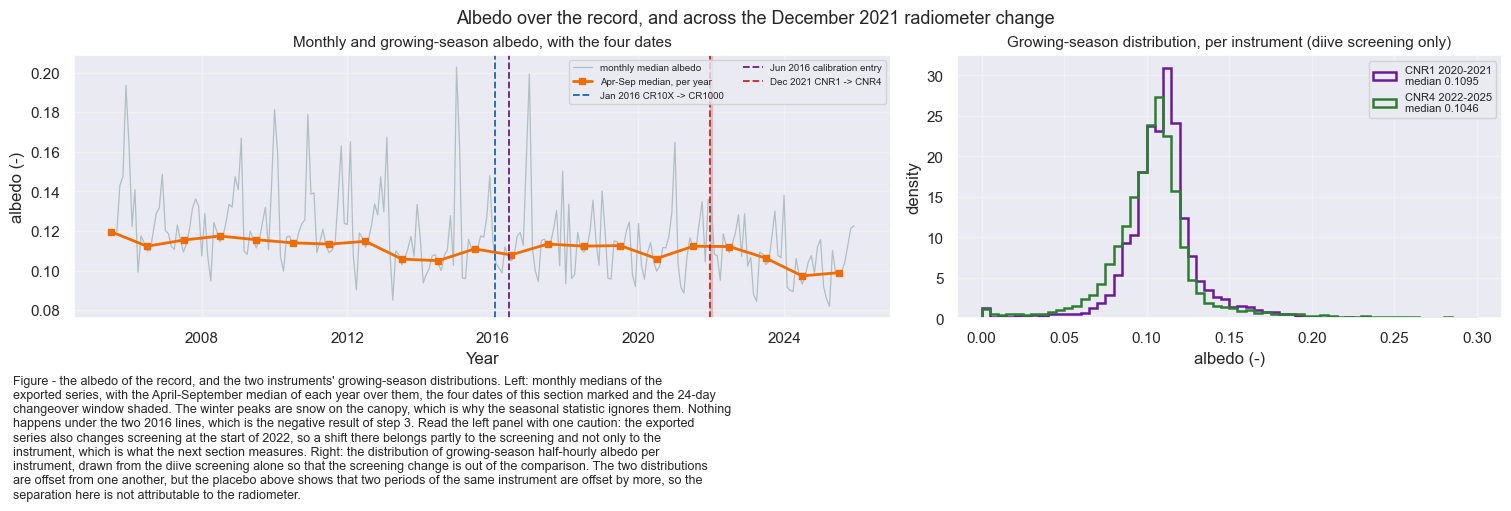

In [44]:
fig, axs = plt.subplots(ncols=2, figsize=(15, 5), dpi=100, layout='constrained',
                        width_ratios=[1.5, 1])
fig.suptitle('Albedo over the record, and across the December 2021 radiometer change', fontsize=13)

_alb = albedo(sw_2005_2025[TARGET])
_monthly = _alb.resample('MS').median()
axs[0].plot(_monthly.index, _monthly.values, color='#B0BEC5', lw=0.9, label='monthly median albedo')
_season = _alb[_alb.index.month.isin(ALBEDO_MONTHS)].resample('YS').median()
axs[0].plot(_season.index + pd.Timedelta(days=182), _season.values, color='#EF6C00', lw=2.0,
            marker='s', ms=4, label='Apr-Sep median, per year')
for _d, _c, _l in [(pd.Timestamp(LOGGER_CHANGE), '#1565C0', 'Jan 2016 CR10X -> CR1000'),
                   (CAL_ENTRY_DATE, '#6A1B9A', 'Jun 2016 calibration entry'),
                   (CNR4_INSTALLED, '#C62828', 'Dec 2021 CNR1 -> CNR4')]:
    axs[0].axvline(_d, color=_c, ls='--', lw=1.3, label=_l)
axs[0].axvspan(CNR4_INSTALLED, CNR4_CONSTANTS, color='#C62828', alpha=.18)
axs[0].set_ylabel('albedo (-)')
axs[0].set_xlabel('Year')
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=7, loc='upper right', ncol=2)
axs[0].set_title('Monthly and growing-season albedo, with the four dates', fontsize=11)

# The right panel is drawn from the diive screening alone, for the reason given above the previous
# cell: the exported series changes screening weeks after the instrument changed.
_alb_one = albedo(DIIVE_ONE_SCALE)
for _years, _colour, _lab in [(CNR1_YEARS, '#6A1B9A', f'CNR1 {CNR1_YEARS[0]}-{CNR1_YEARS[-1]}'),
                              (CNR4_YEARS, '#2E7D32', f'CNR4 {CNR4_YEARS[0]}-{CNR4_YEARS[-1]}')]:
    _v = _alb_one[_alb_one.index.year.isin(list(_years))
                  & _alb_one.index.month.isin(list(ALBEDO_MONTHS))].dropna()
    axs[1].hist(_v, bins=np.linspace(0, 0.30, 61), histtype='step', lw=1.8, color=_colour,
                density=True, label=f'{_lab}\nmedian {_v.median():.4f}')
axs[1].set_xlabel('albedo (-)')
axs[1].set_ylabel('density')
axs[1].grid(alpha=0.3)
axs[1].legend(fontsize=8)
axs[1].set_title('Growing-season distribution, per instrument (diive screening only)', fontsize=11)

figcap(fig, f"the albedo of the record, and the two instruments' growing-season distributions. "
            f"Left: monthly medians of the exported series, with the April-September median of each "
            f"year over them, the four dates of this section marked and the {CHANGEOVER_DAYS}-day "
            f"changeover window shaded. The winter peaks are snow on the canopy, which is why the "
            f"seasonal statistic ignores them. Nothing happens under the two 2016 lines, which is "
            f"the negative result of step 3. Read the left panel with one caution: the exported "
            f"series also changes screening at the start of 2022, so a shift there belongs partly "
            f"to the screening and not only to the instrument, which is what the next section "
            f"measures. Right: the distribution of growing-season half-hourly albedo per "
            f"instrument, drawn from the diive screening alone so that the screening change is out "
            f"of the comparison. The two distributions are offset from one another, but the placebo "
            f"above shows that two periods of the same instrument are offset by more, so the "
            f"separation here is not attributable to the radiometer.")

#### What this section settles

Until 14 December 2021 this channel comes from one instrument, a Kipp & Zonen CNR1, and every
surviving program in both logger languages converts all four of its channels with one constant. From
that date the instrument is a CNR4, whose two shortwave channels are converted with two different
constants of its own.

Across **both 2016 dates the record is homogeneous**. The January 2016 change replaced the logger but
not the conversion, and the June 2016 calibration entry changed the factor applied to the longwave
channels, which is where notebook `06` finds its effect. Neither of them moved this channel. That is
a negative result, and because a negative result is still a claim it is the claim step 3 asserts: a
change of factor on one channel of a ratio would move the albedo by about a fifth, so a re-run that
ever finds such a step will fail there rather than export a file that reports a calibration change as
a change in the canopy.

Across **December 2021 the conversion changes**, and that much is documented rather than inferred:
the CNR1 was replaced by a CNR4, the older instrument's four channels were converted with one
constant, and the newer instrument's two shortwave channels are converted with two different
constants of its own. The instrument flag exists for that reason and should be used before comparing
values across the date.

**How large the resulting step is, this notebook cannot say.** Step 5 measures a difference between
the two instruments' season-controlled albedo, but the same statistic applied to two periods in which
no instrument changed produces a larger difference still. The stand's growing-season albedo moves
from year to year by more than the two eras differ, so the CNR1's own channel mismatch is not
separable from that movement with the years available. An earlier version of this notebook reported
the era-to-era ratio as a property of the instrument; it was the placebo that showed it could not be.

Nothing is corrected for the change either way. Undoing it would need the older instrument's two true
detector sensitivities, and nothing at this site recorded them. `01` and `03` give the same reason for
the slow drifts they find, and `06` for its own December 2021 boundary.

The weeks between the new instrument going up and its constants reaching the logger are a separate
problem again. Step 4 measures them, and the instrument flag gives them a code of their own so they
can be excluded in one filter.

***

## 🔬 The scale difference between the two screenings

**The outcome first: the two screenings agree, so nothing is rescaled and the exported file carries
no homogenized column.** The cells below measure the ratio between them on the well-illuminated
half-hours that both versions report while both describe the CNR1, and the printed factor is what
that measurement gives. This section is built to find a difference and reports finding none, which is
a result rather than an absence of one.

The earlier merge cell reported a much larger difference, and that number was an artefact. It was
measured before the nighttime zero-offset was removed, and an offset of a few W m-2 is a large
fraction of a small flux, so it inflated the ratio wherever the reflected flux was low. Once the
offset is out and only well-illuminated half-hours are used, which is what this section does, the
difference disappears.

Why a difference was worth looking for at all. Over almost the whole overlap the two versions describe
the same instrument, the CNR1, because the radiometer was not swapped until the middle of December
2021, and they describe the same half-hours, since only records that both of them report are used. A
pyranometer's output is a voltage, and the number stored in the database is that voltage divided by a
calibration constant. So two pipelines that reported different numbers for one voltage would have to
have divided it by different constants, and the ratio between their numbers would be the ratio between
those constants. That is a real possibility here, because the two pipelines did not read the same
input files.

This overlap also makes the question easier to settle than the two precedents in this stage. Notebook
`08` could splice its two acquisition eras only after showing them to be one series. `SWC` could not
splice its two sensor generations at all, and because those generations never overlap it had to
rescale one of them onto climatology. Here the two eras **do** overlap, for two full years, so the
ratio between them is measured directly on simultaneous records of one instrument.

**What happens next depends on the measured factor**, and the notebook decides rather than the author.
If it departs from 1 by more than `SCALE_DIFFERENCE_TOLERANCE`, the section runs its full machinery:
it checks that the difference is multiplicative rather than an offset, checks that it is stable in
time, and builds a `_HOMOGENIZED` column in which the `mst` era is rescaled onto the `diive` scale.
If it does not, that machinery is skipped and no second column is exported. Notebook `09` gives the
reason for not exporting one anyway: a duplicate column invites a reader to difference it, get zero,
and draw a conclusion from that.

The tables of the next few cells are shown either way, because they are the evidence for the negative
result. Only their assertions are skipped when no factor is applied. The reason is that each of those
assertions compares a scatter against the size of the effect, so when the effect is zero the
comparison has no floor left and the assertion fires on ordinary noise. A threshold that sits below
the measurement's own scatter is mis-set rather than strict, and it can never be informative.

In [45]:
# The factor is measured on the part of the overlap where both versions describe the CNR1, on
# well-illuminated half-hours, and after the nighttime offset has been taken out of the mst side.
# Selecting on potential radiation keeps the selection independent of either measurement.
MST_CORRECTED = sw_2005_2025[TARGET].where(FROM_MST)
BRIGHT = POTRAD > POTRAD_ALBEDO_MIN
OVERLAP_CNR1 = OVERLAP & (full_index < INSTALL_HALFHOUR) & BRIGHT

_pair = pd.DataFrame({'mst': MST_CORRECTED.where(OVERLAP_CNR1),
                      'diive': DIIVE.where(OVERLAP_CNR1)}).dropna()
_pair = _pair[_pair['mst'] > 0]
RATIO = _pair['diive'] / _pair['mst']

MST_TO_DIIVE = float(RATIO.median())
_sd_ratio = float(_pair['diive'].std() / _pair['mst'].std())
_months = len({(t.year, t.month) for t in _pair.index})

print(f"well-illuminated CNR1 half-hours reported by both versions: {len(_pair):,}")
print(f"they fall in {_months} distinct calendar months, "
      f"{_pair.index[0]} -> {_pair.index[-1]}")
print(f"measured factor, diive / mst:  {MST_TO_DIIVE:.5f} ({100 * (MST_TO_DIIVE - 1):+.2f} %)")
print(f"ratio of standard deviations:  {_sd_ratio:.5f}")

assert len(_pair) >= 500 and _months >= 12, (
    f"the factor rests on {len(_pair):,} half-hours in {_months} calendar months, which is too "
    f"little of the year to decide anything about sixteen years of record")

# A pure change of scale multiplies the spread by the same number as the level. This holds whichever
# way the decision below goes, and it is cheap, so it is checked either way.
assert abs(_sd_ratio / MST_TO_DIIVE - 1) < 0.05, (
    f"the level ratio is {MST_TO_DIIVE:.4f} but the spread ratio is {_sd_ratio:.4f}, so the two "
    f"screenings differ in a way that is not a single multiplicative factor. Find out what else "
    f"differs before going on")

# The decision the rest of the section turns on. It is made against an absolute tolerance, not
# against the size of the effect: a threshold proportional to the effect would shrink to nothing
# exactly when the effect does, and would then fail on any scatter at all.
SCALE_DIFFERS = abs(MST_TO_DIIVE - 1) > SCALE_DIFFERENCE_TOLERANCE
print(f"\ntolerance for treating this as a difference in conversion: "
      f"{100 * SCALE_DIFFERENCE_TOLERANCE:.1f} %")
if SCALE_DIFFERS:
    print(f"DECISION: the two screenings are on different scales. The checks below test whether one "
          f"factor describes the difference, and a homogenized column is built from it.")
else:
    print(f"DECISION: the two screenings agree to {100 * abs(MST_TO_DIIVE - 1):.2f} %, which is "
          f"inside the tolerance. They are two screenings of one measurement on one scale.")
    print("No rescaling is applied and no homogenized column is exported. The tables below are "
          "still shown, because they are the evidence for that conclusion, but their assertions "
          "are skipped: each compares a scatter against the size of the effect, and there is no "
          "effect here for them to be a fraction of.")

well-illuminated CNR1 half-hours reported by both versions: 14,542
they fall in 24 distinct calendar months, 2020-01-02 09:45:00 -> 2021-12-14 10:45:00
measured factor, diive / mst:  0.99970 (-0.03 %)
ratio of standard deviations:  0.99955

tolerance for treating this as a difference in conversion: 1.0 %
DECISION: the two screenings agree to 0.03 %, which is inside the tolerance. They are two screenings of one measurement on one scale.
No rescaling is applied and no homogenized column is exported. The tables below are still shown, because they are the evidence for that conclusion, but their assertions are skipped: each compares a scatter against the size of the effect, and there is no effect here for them to be a fraction of.


In [46]:
# Is the ratio the same at every irradiance? An additive difference would show up as a ratio that
# grows towards the low end, because a fixed number is a larger share of a smaller flux.
# The bins are on the OUTGOING flux, which at this site tops out around 240 W m-2, so they have to
# be spaced for a tenth of the incoming flux rather than for the incoming flux itself. An earlier
# version used incoming-sized edges starting at 50, which put three bins beyond anything the record
# contains and threw away roughly two thirds of the pairs - including the whole low end, which is
# the only place an additive residual would show.
_edges = [0, 5, 10, 20, 50, 100, 250]
_band = pd.cut(_pair['mst'], bins=_edges)
_by_band = RATIO.groupby(_band, observed=True).agg(['count', 'median'])
_by_band['median'] = _by_band['median'].round(5)
_by_band['departure from the overall factor (%)'] = (
    100 * (_by_band['median'] / MST_TO_DIIVE - 1)).round(2)
tabcap("the ratio between the two screenings, in bands of reflected irradiance. A single factor "
       "describes the difference only if these are the same number; a ratio that climbed towards "
       "the low end would mean part of the difference is an offset rather than a scale")
display(_by_band)

_flat = float(_by_band['median'].max() - _by_band['median'].min())
print(f"spread of the band medians: {_flat:.5f}, against a departure from unity of "
      f"{abs(MST_TO_DIIVE - 1):.5f}")
if SCALE_DIFFERS:
    assert _flat < 0.5 * abs(MST_TO_DIIVE - 1), (
        f"the ratio varies by {_flat:.4f} across irradiance bands, which is a large part of the "
        f"{abs(MST_TO_DIIVE - 1):.4f} it departs from unity. The difference between the two "
        f"screenings is then not purely multiplicative, and one factor cannot represent it")
else:
    print(f"assertion skipped: no factor is being applied, so there is nothing for this spread to "
          f"be a fraction of. Read the table instead - the bands agree with each other to "
          f"{_flat:.5f}, which is what a difference of nothing looks like across irradiance.")

Table - the ratio between the two screenings, in bands of reflected irradiance. A single factor
describes the difference only if these are the same number; a ratio that climbed towards the low end
would mean part of the difference is an offset rather than a scale



,count,median,departure from the overall factor (%)
mst,,,
"(0, 5]",1281,1.00197,0.23
"(5, 10]",1470,0.99940,-0.03
"(10, 20]",2239,0.99953,-0.02
"(20, 50]",4294,0.99959,-0.01
"(50, 100]",4889,0.99977,0.01
"(100, 250]",369,0.99979,0.01


spread of the band medians: 0.00257, against a departure from unity of 0.00030
assertion skipped: no factor is being applied, so there is nothing for this spread to be a fraction of. Read the table instead - the bands agree with each other to 0.00257, which is what a difference of nothing looks like across irradiance.


In [47]:
# Is the ratio stable over the overlap? A factor that drifts is not one factor, and averaging it
# over two years would hide that.
_monthly_ratio = RATIO.groupby([RATIO.index.year, RATIO.index.month]).median()
_yearly = RATIO.groupby(RATIO.index.year).agg(['count', 'median', 'std'])
_yearly['median'] = _yearly['median'].round(5)
tabcap("the measured factor per year of the overlap, and the number of half-hours behind each. Two "
       "years that disagree here would mean the difference between the screenings changed over "
       "time, which one factor cannot describe")
display(_yearly.round(4))

_iqr = float(_monthly_ratio.quantile(0.75) - _monthly_ratio.quantile(0.25))
print(f"monthly factors: {len(_monthly_ratio)} months, "
      f"{_monthly_ratio.min():.4f} to {_monthly_ratio.max():.4f}, "
      f"interquartile spread {_iqr:.5f}")
if SCALE_DIFFERS:
    assert _iqr < 0.5 * abs(MST_TO_DIIVE - 1), (
        f"the monthly factors have an interquartile spread of {_iqr:.4f}, which is a large part of "
        f"the {abs(MST_TO_DIIVE - 1):.4f} the factor departs from unity. The difference between the "
        f"two screenings drifts, so a single factor is the wrong correction for it")
else:
    print(f"assertion skipped, for the same reason as in the previous cell. What the table shows is "
          f"that every month of the overlap agrees with every other to within {_iqr:.5f}, so the "
          f"agreement between the two screenings is not an average over months that disagree.")

Table - the measured factor per year of the overlap, and the number of half-hours behind each. Two
years that disagree here would mean the difference between the screenings changed over time, which
one factor cannot describe



,count,median,std
TIMESTAMP_MIDDLE,,,
2020,7370,0.9996,0.6783
2021,7172,0.9998,0.2267


monthly factors: 24 months, 0.9993 to 1.0001, interquartile spread 0.00031
assertion skipped, for the same reason as in the previous cell. What the table shows is that every month of the overlap agrees with every other to within 0.00031, so the agreement between the two screenings is not an average over months that disagree.


### What a difference would have had to look like

A negative result is only worth anything if the test could have seen a positive one, so the cell below
puts the measured factor next to every conversion difference this site is known to have. Those are the
sizes a real difference between two pipelines would come in, and comparing against them is what turns
"we found nothing" into "we would have found something this large, and it is not there".

The comparison is set up as follows. Every value in this variable is a voltage divided by a
calibration constant. If the `diive` values use the constant that the logger programs declare, and the
`mst` values had used some other constant, then that other constant would be the declared one
multiplied by the measured factor. So the cell prints the sensitivity the factor implies, which makes
the question concrete: it stops being "what is this percentage?" and becomes "which of the site's
known sensitivities would this be?".

One candidate deserves setting out in advance, because it is the one a reader is most likely to worry
about. A CNR1 head holds four detectors, and the factory calibrates each of them separately, so the
upward-facing and the downward-facing pyranometer have sensitivities that differ by a few per cent.
The logger programs nevertheless convert all four channels with a single constant, as step 1 shows.
So if the MeteoScreeningTool's source had been converted with the **outgoing** detector's own
sensitivity instead of with that shared constant, the factor measured above would have come out as
the ratio between the two detectors.

Step 5 went after the same quantity by a different route, comparing the albedo of the CNR1 against
the albedo of the CNR4 inside the `diive` screening, and it did not settle it: the year-to-year
movement of the stand's albedo turned out to be larger than the difference between the two
instruments. Its ratio is printed in the table below as a fourth row, but as a number of unknown
provenance rather than as a measurement of the mismatch. If the factor measured here were real and
were the mismatch, the two would have to agree; they are shown together so that can be seen, not
because the step-5 figure carries weight of its own.

In [48]:
S_MST_IMPLIED = S_CNR1 * MST_TO_DIIVE
print(f"this notebook converts the channel with {S_CNR1:.2f} uV/W/m2 (multiplier {MULT_CNR1})")
print(f"the measured factor implies the mst pipeline used "
      f"{S_MST_IMPLIED:.2f} uV/W/m2 for the same detector")

# The documented differences are kept apart from the measured one: the first three are constants
# somebody wrote down, the fourth is a measurement made elsewhere in this notebook.
_documented = {
    f'June 2016 NetRad factor change ({SENS_2016_NEW} / {SENS_2016_OLD})':
        SENS_2016_NEW / SENS_2016_OLD,
    f"CNR4 outgoing constant against the CNR1 constant "
    f"({SENSITIVITIES_CNR4['SW_OUT']} / {S_CNR1:.2f})":
        SENSITIVITIES_CNR4['SW_OUT'] / S_CNR1,
    f"CNR4's own two shortwave channels ({SENSITIVITIES_CNR4['SW_OUT']} / "
    f"{SENSITIVITIES_CNR4['SW_IN']})":
        SENSITIVITIES_CNR4['SW_OUT'] / SENSITIVITIES_CNR4['SW_IN'],
}
_candidates = dict(_documented)
_candidates['December 2021 albedo ratio (step 5, NOT attributable to the instrument)'] = ALBEDO_STEP
_candidates['MEASURED between the two screenings'] = MST_TO_DIIVE

tabcap("what a difference between the two screenings would have had to look like. The first three "
       "rows are conversion ratios somebody wrote down at this site, the fourth is a measurement of "
       "the same instrument's channel mismatch made elsewhere in this notebook, and the last is "
       "what the overlap actually gives")
_cmp = pd.DataFrame({
    'ratio': [round(v, 5) for v in _candidates.values()],
    'as a percentage': [f'{100 * (v - 1):+.2f} %' for v in _candidates.values()],
    'distance from the measured factor': [f'{100 * (v - MST_TO_DIIVE):+.2f} points'
                                          for v in _candidates.values()],
}, index=list(_candidates))
display(_cmp)

_smallest = min(abs(v - 1) for v in _documented.values())
_measured = abs(MST_TO_DIIVE - 1)
print(f"measured factor: {MST_TO_DIIVE:.5f} ({100 * _measured:+.2f} % from unity)")
print(f"smallest documented conversion difference at this site: {100 * _smallest:.1f} %")
print(f"tolerance for calling the two screenings different:     "
      f"{100 * SCALE_DIFFERENCE_TOLERANCE:.1f} %")

if SCALE_DIFFERS:
    _closest = min(_candidates, key=lambda k: abs(_candidates[k] - MST_TO_DIIVE))
    print(f"\nclosest candidate: {_closest}")
    print(f"agreement with the independent albedo estimate of the CNR1 channel mismatch: "
          f"{100 * (MST_TO_DIIVE / ALBEDO_STEP - 1):+.2f} % apart")
else:
    print(f"\nThe measured difference is {_smallest / max(_measured, 1e-9):.0f} times smaller than "
          f"the smallest difference this site is known to have produced, and "
          f"{SCALE_DIFFERENCE_TOLERANCE / max(_measured, 1e-9):.0f} times smaller than the "
          f"tolerance. A difference of any documented size would have been unmissable on "
          f"{len(_pair):,} half-hours, so this is a measurement of no difference rather than a "
          f"test too blunt to find one.")
    print(f"The December 2021 albedo ratio of {100 * abs(ALBEDO_STEP - 1):.1f} % is a separate "
          f"matter and is not settled either: step 5 found the year-to-year movement of the "
          f"stand's albedo to be larger than it. Whatever the CNR1's channel mismatch is, it is "
          f"not measured anywhere in this notebook, and both screenings carry it equally.")

this notebook converts the channel with 10.03 uV/W/m2 (multiplier 99.7009)
the measured factor implies the mst pipeline used 10.03 uV/W/m2 for the same detector
Table - what a difference between the two screenings would have had to look like. The first three
rows are conversion ratios somebody wrote down at this site, the fourth is a measurement of the same
instrument's channel mismatch made elsewhere in this notebook, and the last is what the overlap
actually gives



,ratio,as a percentage,distance from the measured factor
June 2016 NetRad factor change (12.83 / 10.03),1.27916,+27.92 %,+27.95 points
CNR4 outgoing constant against the CNR1 constant (14.38 / 10.03),1.43370,+43.37 %,+43.40 points
CNR4's own two shortwave channels (14.38 / 13.89),1.03528,+3.53 %,+3.56 points
"December 2021 albedo ratio (step 5, NOT attributable to the instrument)",1.04230,+4.23 %,+4.26 points
MEASURED between the two screenings,0.99970,-0.03 %,+0.00 points


measured factor: 0.99970 (+0.03 % from unity)
smallest documented conversion difference at this site: 3.5 %
tolerance for calling the two screenings different:     1.0 %

The measured difference is 118 times smaller than the smallest difference this site is known to have produced, and 33 times smaller than the tolerance. A difference of any documented size would have been unmissable on 14,542 half-hours, so this is a measurement of no difference rather than a test too blunt to find one.
The December 2021 albedo ratio of 4.2 % is a separate matter and is not settled either: step 5 found the year-to-year movement of the stand's albedo to be larger than it. Whatever the CNR1's channel mismatch is, it is not measured anywhere in this notebook, and both screenings carry it equally.


::: {.callout-important title="What this settles, and what it deliberately does not"}
Read the table and the printout above before this note, because which branch the notebook takes is a
property of the run rather than of this text.

**When the two screenings agree**, which is what the current data give, three things follow. The two
data versions can be spliced without any rescaling, so the exported file carries one value column and
no homogenized twin. The `mst` and `diive` eras are on one scale, so a trend or a multi-year mean can
be taken straight across the boundary between them. And the earlier merge cell's much larger figure is
explained rather than left standing: it was the nighttime offset seen as a fraction of small fluxes,
and it is gone once the offset is removed.

The screening flag is still exported. Which pipeline produced a value is worth recording even when the
two agree, because it is the thing a later re-screening would change, and because a reader comparing
this product against an older copy of it needs to know which half came from where.

**What this does not settle** is the CNR1's own channel mismatch. That is a difference between the two
detectors in one head, both screenings carry it equally, and it is measured in step 5 of the previous
section rather than here. Settling it would need the calibration certificate of CNR1 serial 020484,
which is in neither the repository nor the maintenance record.

**If a re-run ever measures a difference above the tolerance**, the section does not stop at reporting
it. The irradiance-band and stability checks become live assertions, a `_HOMOGENIZED` column is built
in which the `mst` era is rescaled onto the `diive` scale, and the export gains a fourth column. The
direction is fixed and traceable: the `diive` values come from `ch-lae_raw`, whose conversion is
written in a logger program and declared in the settings block, whereas nothing on disk records what
the MeteoScreeningTool's delivered files had been converted with.
:::

In [49]:
if SCALE_DIFFERS:
    HOMOGCOL = f'{TARGET}_HOMOGENIZED'

    # The measured column keeps the measured values. The homogenized column puts the mst era on the
    # diive scale by the factor measured above, and leaves the diive era untouched.
    sw_2005_2025[HOMOGCOL] = sw_2005_2025[TARGET].where(~FROM_MST,
                                                        sw_2005_2025[TARGET] * MST_TO_DIIVE)

    _m_meas = sw_2005_2025[TARGET]
    _m_homog = sw_2005_2025[HOMOGCOL]
    print(f"factor applied to the mst era: {MST_TO_DIIVE:.5f}")
    print(f"mst records rescaled:    {int((FROM_MST & _m_meas.notna()).sum()):,}")
    print(f"diive records untouched: {int((FROM_DIIVE & _m_meas.notna()).sum()):,}")

    # The homogenization must not touch the later era, must not turn a gap into a value or back,
    # and must have scaled the earlier era by exactly the factor and by nothing else.
    assert _m_homog.isna().equals(_m_meas.isna()), \
        "the homogenized column does not have the same gaps as the measured one"
    assert bool(_m_homog.where(FROM_DIIVE).equals(_m_meas.where(FROM_DIIVE))), \
        "the homogenization modified the diive era, which is the scale it rescales onto"
    _scaled = (_m_homog / _m_meas).where(FROM_MST & (_m_meas > 0)).dropna()
    assert float((_scaled - MST_TO_DIIVE).abs().max()) < 1e-9, \
        "the mst era was not scaled by exactly the measured factor"
    print(f"\nOK: {len(_scaled):,} positive mst records all scaled by exactly the factor, the "
          f"diive era is unchanged, and the gap structure is identical.")
else:
    HOMOGCOL = None
    print(f"No homogenized column is built. The two screenings agree to "
          f"{100 * abs(MST_TO_DIIVE - 1):.2f} %, so a rescaled twin of the measured column would "
          f"differ from it by less than the measurement's own resolution.")
    print("Notebook 09 gives the reason for not exporting one anyway: a duplicate column invites a "
          "reader to difference it against the measured one, get zero, and conclude something from "
          "that. Where a real difference exists, as at the SWC sensor change, the second column "
          "earns its place; here it would only be noise with a name.")

# Everything downstream reads these two names rather than testing SCALE_DIFFERS again, so the export
# and the figures do not each have to know how the decision went.
VALUE_COLUMNS = [TARGET] + ([HOMOGCOL] if HOMOGCOL else [])
ALBEDO_BASIS = HOMOGCOL or TARGET
print(f"\nvalue columns to export: {VALUE_COLUMNS}")
print(f"albedo statistics below are computed on: {ALBEDO_BASIS}")

No homogenized column is built. The two screenings agree to 0.03 %, so a rescaled twin of the measured column would differ from it by less than the measurement's own resolution.
Notebook 09 gives the reason for not exporting one anyway: a duplicate column invites a reader to difference it against the measured one, get zero, and conclude something from that. Where a real difference exists, as at the SWC sensor change, the second column earns its place; here it would only be noise with a name.

value columns to export: ['SW_OUT_T1_47_1']
albedo statistics below are computed on: SW_OUT_T1_47_1


### 📊 Plot: the two screenings compared

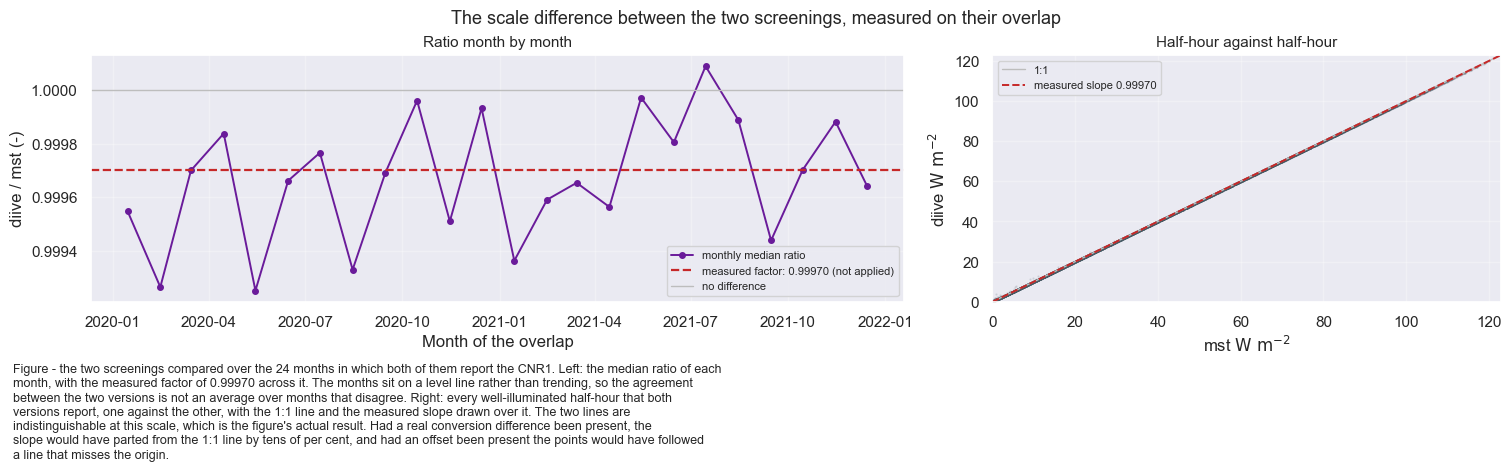

In [50]:
fig, axs = plt.subplots(ncols=2, figsize=(15, 4.6), dpi=100, layout='constrained',
                        width_ratios=[1.6, 1])
fig.suptitle('The scale difference between the two screenings, measured on their overlap',
             fontsize=13)

_mr = _monthly_ratio.copy()
_mr.index = [pd.Timestamp(year=y, month=m, day=15) for y, m in _mr.index]
axs[0].plot(_mr.index, _mr.values, color='#6A1B9A', lw=1.4, marker='o', ms=4,
            label='monthly median ratio')
axs[0].axhline(MST_TO_DIIVE, color='#C62828', lw=1.6, ls='--',
               label=(f'factor applied: {MST_TO_DIIVE:.4f}' if SCALE_DIFFERS
                      else f'measured factor: {MST_TO_DIIVE:.5f} (not applied)'))
axs[0].axhline(1.0, color='#BDBDBD', lw=1.0, label='no difference')
axs[0].set_ylabel('diive / mst (-)')
axs[0].set_xlabel('Month of the overlap')
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=8)
axs[0].set_title('Ratio month by month', fontsize=11)

axs[1].plot(_pair['mst'], _pair['diive'], '.', ms=1.2, alpha=0.15, color='#455A64')
_lim = [0, float(np.nanpercentile(_pair['mst'], 99.9)) * 1.05]
axs[1].plot(_lim, _lim, color='#BDBDBD', lw=1.0, ls='-', label='1:1')
axs[1].plot(_lim, [MST_TO_DIIVE * v for v in _lim], color='#C62828', lw=1.4, ls='--',
            label=f'measured slope {MST_TO_DIIVE:.5f}')
axs[1].set_xlim(_lim)
axs[1].set_ylim(_lim)
axs[1].set_xlabel(r'mst $\mathrm{W\ m^{-2}}$')
axs[1].set_ylabel(r'diive $\mathrm{W\ m^{-2}}$')
axs[1].grid(alpha=0.3)
axs[1].legend(fontsize=8)
axs[1].set_title('Half-hour against half-hour', fontsize=11)

figcap(fig, f"the two screenings compared over the {_months} months in which both of them report "
            f"the CNR1. Left: the median ratio of each month, with the measured factor of "
            f"{MST_TO_DIIVE:.5f} across it. The months sit on a level line rather than trending, so "
            f"the agreement between the two versions is not an average over months that disagree. "
            f"Right: every well-illuminated half-hour that both versions report, one against the "
            f"other, with the 1:1 line and the measured slope drawn over it. The two lines are "
            f"indistinguishable at this scale, which is the figure's actual result. Had a real "
            f"conversion difference been present, the slope would have parted from the 1:1 line by "
            f"tens of per cent, and had an offset been present the points would have followed a "
            f"line that misses the origin.")

## 🏷️ Two provenance flags

One column name spans two instruments and two screenings, and those are different boundaries falling
on different dates, so the exported file carries a flag for each of them. Putting both into one
column would mean inventing a code for every combination, and a reader wanting only one of the two
distinctions would then have to know which codes to group.

`FLAG_SW_OUT_T1_47_1_SOURCE` names the **screening** that produced each value. The previous section
measured the two screenings to be on one scale, so this flag is provenance rather than a warning:
filter on it to select an era, or to see which half of the record a later re-screening would change.
It is also the flag a homogenized column would be keyed to, if a re-run ever found one to be needed.

It carries a third code for half-hours that neither screening ever covered. That is not the same as
a gap: a half-hour one screening supplied and this notebook then discarded, such as a record inside
the 2012 damage windows, keeps that screening's code and carries `NaN`. Code 2 says nothing was ever
offered for the slot. Keeping the two apart matters because the flag is also how the provenance of
the August 2012 block is checked, and that block moves between half-hours.
`FLAG_SW_OUT_T1_47_1_INSTRUMENT` names the **instrument and its conversion constant**, which is the
boundary the December 2021 sections are about, and that one is a real break. Filter on it before
comparing values across the radiometer swap, and drop its changeover code before using those weeks.

The instrument vocabulary is short on purpose. There is **no code for the January 2016 acquisition
change and none for the June 2016 calibration entry**, because step 3 of the previous section measured
both and neither moved this channel. A code for a boundary that the data deny would invite a reader to
difference across it, find nothing, and then distrust the rest of the file. The changeover interval
does get a code of its own rather than being assigned to one side, as in `06` and `08`.

Both flags come from dates the previous section read out of the maintenance record rather than from
dates typed here a second time. The fieldbook records dates but no times, so the boundary at the
constants date carries a day of slack. The boundary at the installation does not, because the artefact
minute the sibling channel supplies puts it inside a single half-hour.

In [51]:
FLAGCOL = f'FLAG_{TARGET}_SOURCE'        # which screening
INSTRCOL = f'FLAG_{TARGET}_INSTRUMENT'   # which instrument and which conversion constant
# Written with inclusive end dates, so each legend reads the way a data user would filter.
_last_cnr1 = INSTALL_HALFHOUR - pd.Timedelta(REQUIRED_TIME_RESOLUTION)
_last_changeover = CNR4_CONSTANTS - pd.Timedelta(minutes=15)

SOURCE_LEGEND = {
    0: '0 = diive screening, on the scale of the logger program that feeds ch-lae_raw',
    1: (f'1 = mst screening, rescaled onto the diive scale in the homogenized column by the '
        f'measured factor {MST_TO_DIIVE:.5f}') if SCALE_DIFFERS else
       (f'1 = mst screening, measured to be on the same scale as diive '
        f'({MST_TO_DIIVE:.5f} over their overlap, no rescaling applied)'),
    2: '2 = neither screening supplied a value for this half-hour',
}
INSTRUMENT_LEGEND = {
    0: f'0 = CNR4, each shortwave channel on its own constant (SW_OUT '
       f"{SENSITIVITIES_CNR4['SW_OUT']} uV/W/m2, from {CNR4_CONSTANTS.date()})",
    1: f'1 = CNR1, one constant of {S_CNR1:.2f} uV/W/m2 for all four channels of the head '
       f'(to {_last_cnr1:%Y-%m-%d %H:%M})',
    2: f'2 = changeover interval ({INSTALL_HALFHOUR:%Y-%m-%d %H:%M} to '
       f'{_last_changeover:%Y-%m-%d %H:%M}): after the CNR4 went up and before the logger program '
       f'was updated, conversion in force not established',
}

# Code 2 is not a synonym for a gap. A half-hour a screening supplied and this notebook then removed
# keeps that screening's code and carries NaN; code 2 means no screening ever offered a value.
source = pd.Series(2, index=full_index, dtype='int8', name=FLAGCOL)
source.loc[FROM_DIIVE] = 0
source.loc[FROM_MST] = 1

instrument = pd.Series(0, index=full_index, dtype='int8', name=INSTRCOL)
instrument.loc[:_last_cnr1] = 1
instrument.loc[INSTALL_HALFHOUR:_last_changeover] = 2
# code 0 is what remains, from the constants date onwards


def flag_table(flag, legend, valcol=TARGET):
    """One flag by code, with the share of measured records each code carries."""
    tab = pd.DataFrame({
        'meaning': {c: legend[c] for c in sorted(legend)},
        'records': flag.value_counts().reindex(sorted(legend)).fillna(0).astype(int),
        'measured records': flag.where(sw_2005_2025[valcol].notna()).value_counts()
                                .reindex(sorted(legend)).fillna(0).astype(int),
    })
    tab['share of measured (%)'] = (100 * tab['measured records']
                                    / tab['measured records'].sum()).round(2)
    tab.index.name = 'code'
    return tab


tabcap("the screening flag, by code. It records which pipeline produced each value, which is "
       "worth knowing even where the two are on one scale, because it is what a later re-screening "
       "would change")
with pd.option_context('display.max_colwidth', 150):
    display(flag_table(source, SOURCE_LEGEND))

tabcap("the instrument flag, by code. Code 1 is the era whose two shortwave channels share one "
       "constant, so its albedo carries the instrument's own channel mismatch. Code 2 is the "
       "changeover window, which is flagged rather than corrected")
with pd.option_context('display.max_colwidth', 150):
    display(flag_table(instrument, INSTRUMENT_LEGEND))

# Both flags are defined everywhere and describe the whole index once.
for _flag, _legend, _name in [(source, SOURCE_LEGEND, FLAGCOL),
                              (instrument, INSTRUMENT_LEGEND, INSTRCOL)]:
    assert _flag.notna().all(), f"{_name} is not defined everywhere"
    assert set(_flag.unique()).issubset(set(_legend)), \
        f"{_name} carries a code that its legend does not describe"

# The screening flag is re-derived here from the two DOWNLOADS rather than compared against the
# masks it was written from. Checking a flag against the mask that built it two lines earlier is not
# a check: it passes however wrong the mask is, which is exactly how a batch of 2012 records came to
# be exported as diive-screened in an earlier version of this notebook.
_check_mst = mst_sw[TARGET].reindex(full_index).notna()
_check_diive = diive_sw[TARGET].reindex(full_index).notna()
# The August 2012 block moved, so the re-derivation has to move with it in the same way the values
# and the masks did. Anything that reconstructs provenance without this lands the block in the wrong
# era, which is the bug this cell exists to catch.
_check_mst = shift_mask(_check_mst)
_check_diive = shift_mask(_check_diive)

_expected = pd.Series(2, index=full_index, dtype='int8')
_expected.loc[_check_diive] = 0
_expected.loc[_check_mst] = 1
assert bool(source.equals(_expected.rename(FLAGCOL))), (
    f"the screening flag disagrees with a fresh derivation from the two downloads at "
    f"{int((source != _expected).sum()):,} records. Either the provenance masks did not travel with "
    f"the timestamp shift, or a correction moved values without moving their provenance")

# And against the counts the merge printed, which is a second statement of the same thing from
# numbers computed before any correction ran. They are not simply equal: the August 2012 shift
# blanks the hours its block vacates, and a slot that loses its value loses its provenance with it,
# so the credited totals fall by exactly what the ledger recorded there.
_n_mst_now, _n_diive_now = int(source.eq(1).sum()), int(source.eq(0).sum())
_vacated_ledger = REMOVALS['records vacated by the August 2012 clock shift']
print(f"credited now: mst {_n_mst_now:,}, diive {_n_diive_now:,}")
print(f"counted at the merge: mst {N_FROM_MST_AT_MERGE:,}, diive {N_FROM_DIIVE_AT_MERGE:,}; "
      f"vacated by the clock shift: {_vacated_ledger:,}")
assert _n_mst_now <= N_FROM_MST_AT_MERGE and _n_diive_now <= N_FROM_DIIVE_AT_MERGE, (
    "a screening is credited with more records than it supplied at the merge, so the shift has "
    "created provenance rather than carrying it")
assert _n_mst_now + _n_diive_now == (N_FROM_MST_AT_MERGE + N_FROM_DIIVE_AT_MERGE
                                     - _vacated_ledger), (
    f"the flag credits {_n_mst_now + _n_diive_now:,} records to a screening, against "
    f"{N_FROM_MST_AT_MERGE + N_FROM_DIIVE_AT_MERGE - _vacated_ledger:,} expected from the merge "
    f"counts less the records the clock shift vacated. Provenance has been lost or invented "
    f"somewhere between the merge and here")
# Code 2 is what neither screening covers, so it must hold no measured value at all.
assert int(sw_2005_2025.loc[source == 2, TARGET].notna().sum()) == 0, \
    "a half-hour flagged as covered by neither screening carries a value"

# The instrument flag's boundaries are asserted against the two dates themselves, not against the
# slices used to write them. INSTALL_ARTEFACT_MINUTE is the settings constant the sibling channel
# supplies; CNR4_CONSTANTS is the date parsed out of the fieldbook entry.
assert int(instrument.loc[pd.Timestamp(INSTALL_ARTEFACT_MINUTE)
                          .floor(REQUIRED_TIME_RESOLUTION)
                          + pd.Timedelta(REQUIRED_TIME_RESOLUTION) / 2]) == 2, \
    "the half-hour holding the artefact minute is not inside the changeover window"
# The bin BEFORE the artefact's own bin. Derived from the floored bin rather than by subtracting
# from the raw minute: INSTALL_ARTEFACT_MINUTE is a 1MIN stamp at :34:30, so subtracting half an
# hour from it lands at :04:30, which is not on the 30MIN TIMESTAMP_MID grid at all.
assert int(instrument.loc[pd.Timestamp(INSTALL_ARTEFACT_MINUTE)
                          .floor(REQUIRED_TIME_RESOLUTION)
                          + pd.Timedelta(REQUIRED_TIME_RESOLUTION) / 2
                          - pd.Timedelta(REQUIRED_TIME_RESOLUTION)]) == 1, \
    "the half-hour before the artefact minute is not the CNR1 era"
assert int(instrument.loc[CNR4_CONSTANTS + pd.Timedelta(minutes=15)]) == 0, \
    "the first half-hour of the constants date is not the CNR4 era"
assert int(instrument.loc[CNR4_CONSTANTS - pd.Timedelta(minutes=15)]) == 2, \
    "the last half-hour before the constants date is not the changeover interval"
assert instrument.loc[:_last_cnr1].eq(1).all() and instrument.loc[CNR4_CONSTANTS:].eq(0).all(), \
    "the two instrument eras are no longer contiguous either side of the changeover interval"

# The two flags are about different boundaries, so they must not be copies of one another. If they
# ever became identical, one of them would be redundant and the four-column product unjustified.
assert not bool(source.eq(instrument).all()), \
    "the screening flag and the instrument flag are now identical, so they no longer describe two "\
    "different boundaries"
tabcap("how the two flags cross. Each cell is a combination of screening and instrument that "
       "actually occurs in the record, which is why the two are kept as separate columns rather "
       "than merged into one vocabulary")
_cross = pd.crosstab(source.rename('screening'), instrument.rename('instrument'))
display(_cross)

Table - the screening flag, by code. It records which pipeline produced each value, which is worth
knowing even where the two are on one scale, because it is what a later re-screening would change



,meaning,records,measured records,share of measured (%)
code,,,,
0,"0 = diive screening, on the scale of the logger program that feeds ch-lae_raw",70048,70048,19.92
1,"1 = mst screening, measured to be on the same scale as diive (0.99970 over their overlap, no rescaling applied)",282776,281564,80.08
2,2 = neither screening supplied a value for this half-hour,3048,0,0.00


Table - the instrument flag, by code. Code 1 is the era whose two shortwave channels share one
constant, so its albedo carries the instrument's own channel mismatch. Code 2 is the changeover
window, which is flagged rather than corrected



,meaning,records,measured records,share of measured (%)
code,,,,
0,"0 = CNR4, each shortwave channel on its own constant (SW_OUT 14.38 uV/W/m2, from 2022-01-07)",69840,69760,19.84
1,"1 = CNR1, one constant of 10.03 uV/W/m2 for all four channels of the head (to 2021-12-14 13:15)",284907,280729,79.84
2,"2 = changeover interval (2021-12-14 13:45 to 2022-01-06 23:45): after the CNR4 went up and before the logger program was updated, conversion in fo...",1125,1123,0.32


credited now: mst 282,776, diive 70,048
counted at the merge: mst 282,776, diive 70,048; vacated by the clock shift: 0
Table - how the two flags cross. Each cell is a combination of screening and instrument that
actually occurs in the record, which is why the two are kept as separate columns rather than merged
into one vocabulary



instrument,0,1,2
screening,,,
0,69760,0,288
1,0,281941,835
2,80,2966,2


***

## ❓ A candidate window left in place: July 2024

The `SW_OUT` screening notebook carries a `REMOVE_DATES` entry for
`2024-07-14 07:15` to `2024-07-19 00:00`, but its `addflag()` cell was never executed, so nothing was
committed and those records are in the series this notebook downloaded. A window written down but not
committed is a hypothesis. It is not adopted here on the strength of having been typed.

The albedo is the check that could settle it. A fault in the reflected channel alone moves the ratio
away from the level of the surrounding weeks. Cloud and sun move both channels together and leave it
alone. The window is measured against the four weeks either side of it and against the same calendar
days of the other years, the fieldbook is asked what happened, and the outcome is reported rather
than acted on. The `G` screening notebooks treat their own unsettled excursion the same way.

In [52]:
_w_lo, _w_hi = [pd.Timestamp(t) for t in CANDIDATE_WINDOW_2024]
assert _w_lo.month == _w_hi.month, \
    "the candidate window now spans two months, so the same-days-of-other-years selection below no "\
    "longer selects the same days"
_alb = albedo(sw_2005_2025[TARGET])
# Calendar day of month rather than day of year: 2024 is a leap year and most of the others are not,
# so a day-of-year selection would compare 14-19 July against 13-18 July.
_OTHER_YEARS = [y for y in range(2016, int(RECORD_END[:4]) + 1) if y != _w_lo.year]

_rows = []
for _lab, _sel in [
    (f'window {_w_lo:%d}-{_w_hi:%d %b %Y}', (full_index >= _w_lo) & (full_index <= _w_hi)),
    ('4 weeks before', (full_index >= _w_lo - pd.Timedelta(days=28)) & (full_index < _w_lo)),
    ('4 weeks after', (full_index > _w_hi) & (full_index <= _w_hi + pd.Timedelta(days=28))),
    ('same calendar days, 2016-2025 without 2024',
     np.isin(full_index.year, _OTHER_YEARS) & (full_index.month == _w_lo.month)
     & (full_index.day >= _w_lo.day) & (full_index.day <= _w_hi.day)),
]:
    _a = _alb[_sel].dropna()
    _s = sw_2005_2025[TARGET][_sel]
    _rows.append({'period': _lab, 'albedo half-hours': int(len(_a)),
                  'albedo median': round(float(_a.median()), 4) if len(_a) else np.nan,
                  'albedo p10': round(float(_a.quantile(.10)), 4) if len(_a) else np.nan,
                  'albedo p90': round(float(_a.quantile(.90)), 4) if len(_a) else np.nan,
                  'SW_OUT max (W m-2)': round(float(_s.max()), 1) if _s.notna().any() else np.nan,
                  'measured (%)': round(100 * float(_s.notna().mean()), 2)})
tabcap("the uncommitted July 2024 candidate window against the weeks around it and against the same "
       "calendar days of the other years. A fault confined to the reflected channel would move the "
       "albedo; weather would not")
display(pd.DataFrame(_rows).set_index('period'))

Table - the uncommitted July 2024 candidate window against the weeks around it and against the same
calendar days of the other years. A fault confined to the reflected channel would move the albedo;
weather would not



,albedo half-hours,albedo median,albedo p10,albedo p90,SW_OUT max (W m-2),measured (%)
period,,,,,,
window 14-19 Jul 2024,131,0.0917,0.0632,0.1081,102.4,100.00
4 weeks before,730,0.0954,0.0650,0.1351,103.0,95.98
4 weeks after,717,0.0928,0.0665,0.1059,105.4,99.93
"same calendar days, 2016-2025 without 2024",1438,0.1085,0.0922,0.1214,118.3,100.00


In [53]:
# The fieldbook, asked about the window rather than about a device: the entries that explain a
# radiation fault are routinely filed under the logger or under a site visit.
_fb_win = fb[fb['Date'].between(_w_lo.normalize() - pd.Timedelta(days=14),
                                _w_hi.normalize() + pd.Timedelta(days=14))].sort_values('Date')
print(f"fieldbook entries within a fortnight of the window: {len(_fb_win)}")
if len(_fb_win):
    _show = _fb_win[['Date', 'Device Model', 'Operation Tag', 'text']].copy()
    _show['Date'] = _show['Date'].dt.date
    _show['text'] = _show['text'].str.slice(0, 160)
    tabcap("what the maintenance record holds around the candidate window")
    with pd.option_context('display.max_colwidth', 165, 'display.max_rows', 40):
        display(_show.set_index('Date'))
else:
    print("The record is silent here. Silence is not evidence that nothing happened; it is evidence "
          "that the record stops there, and it is not a reason to remove data.")

_alb_win = _alb[(full_index >= _w_lo) & (full_index <= _w_hi)].dropna()
_alb_ctx = _alb[(full_index >= _w_lo - pd.Timedelta(days=28))
                & (full_index <= _w_hi + pd.Timedelta(days=28))
                & ~((full_index >= _w_lo) & (full_index <= _w_hi))].dropna()
_ratio = (float(_alb_win.median()) / float(_alb_ctx.median())
          if len(_alb_win) and len(_alb_ctx) else np.nan)
print(f"\nwindow albedo median / surrounding weeks: {_ratio:.4f} ({100 * (_ratio - 1):+.1f} %) on "
      f"{len(_alb_win):,} half-hours")
print("The window is NOT removed. It stays in the product, it is not flagged, and this cell is the "
      "record of why: the ratio above is what a re-run recomputes, and a removal would need it to "
      "stand apart from the surrounding weeks by more than those weeks differ among themselves. "
      "Whoever settles it should do so in the screening notebook, where a removal is committed on "
      "the 1MIN data and travels with the flags, rather than here.")

fieldbook entries within a fortnight of the window: 8
Table - what the maintenance record holds around the candidate window



,Device Model,Operation Tag,text
Date,,,
2024-07-15,na,na,Power interruption from 29th June (~18:00). Fixed from 1st July at the tower 1 and 2and forestfloor.
2024-07-16,AtA,CH-LAE_iWEATHER_T1_25_1,The CO2 sensors is not providing data anymore
2024-07-23,na,na,Arrived and left the site
2024-07-23,15188H,CH-LAE_iPREC_T1_47_1,Worked on the device installed a new transformer for the heater on PREC T_1_47
2024-07-23,AtA,CH-LAE_iWEATHER_T1_25_1,Worked on the device replace 17.5m CO2 sensor of profile
2024-07-23,ZN11-T-WP,CH-LAE_iD_TR8005_1.5_1,Worked on the device Dendrometers 8005 and 8004 and 8009 cleaned and checked
2024-07-23,ZN11-T-WP,CH-LAE_iD_TR8004_1.5_1,Worked on the device Dendrometers 8005 and 8004 and 8009 cleaned and checked
2024-07-23,ZN11-T-WP,CH-LAE_iD_TR8009_1.5_1,Worked on the device Dendrometers 8005 and 8004 and 8009 cleaned and checked



window albedo median / surrounding weeks: 0.9744 (-2.6 %) on 131 half-hours
The window is NOT removed. It stays in the product, it is not flagged, and this cell is the record of why: the ratio above is what a re-run recomputes, and a removal would need it to stand apart from the surrounding weeks by more than those weeks differ among themselves. Whoever settles it should do so in the screening notebook, where a removal is committed on the 1MIN data and travels with the flags, rather than here.


***

## 🚫 No gap-filling here

As in notebooks `05` and `06`, the series is exported exactly as it was measured, and the reason is
stronger here than in either of those. Gap-filling needs a driver, and a driver for reflected
shortwave would have to be something that measures what this canopy reflects. No weather service
measures that, NABEL does not, and the site's only other outgoing shortwave channel sits below the
canopy and sees a different quantity. The one thing available would be the incoming channel combined
with a modelled albedo, which would fill the gaps with the model rather than with the weather, and
would have to do so straight across the instrument change the previous sections document.

What this means for anything that reads the file:

- The value column **contains `NaN`**, so code that assumes a complete series will either break or
  quietly propagate the gaps. The gaps are genuine outages of the measurement.
- There is **no `FLAG_..._ISFILLED` column**, because nothing is filled. A non-null record is a
  measurement.
- The two screening eras are on one scale, so a trend or a multi-year mean can be taken straight
  across the boundary between them. `FLAG_SW_OUT_T1_47_1_SOURCE` says which era a value came from
  if you need to know.
- Filter on `FLAG_SW_OUT_T1_47_1_INSTRUMENT` before comparing values across December 2021, and drop
  its changeover code before using December 2021 or early January 2022 at all. That boundary is a
  real one, unlike the screening boundary.
- If a complete series is needed later, fill it downstream, where the fill can be flagged in that
  product's own terms. Whoever does that should not train one model across either boundary.

***

## ➡️ Prepare dataframe for export

In [54]:
VALCOL = TARGET

export_df = sw_2005_2025[VALUE_COLUMNS].copy()
export_df[FLAGCOL] = source
export_df[INSTRCOL] = instrument
EXPORT_COLUMNS = VALUE_COLUMNS + [FLAGCOL, INSTRCOL]
export_df = export_df[EXPORT_COLUMNS]
tabcap("the exported frame: the measured series, the two flags naming the screening and the "
       "instrument behind each value, and a rescaled second value column where the two screenings "
       "were found to be on different scales" + ("" if HOMOGCOL else " (not the case here)"))
display(export_df)

Table - the exported frame: the measured series, the two flags naming the screening and the
instrument behind each value, and a rescaled second value column where the two screenings were found
to be on different scales (not the case here)



,SW_OUT_T1_47_1,FLAG_SW_OUT_T1_47_1_SOURCE,FLAG_SW_OUT_T1_47_1_INSTRUMENT
TIMESTAMP_MIDDLE,,,
2005-09-14 00:15:00,NaN,2,1
2005-09-14 00:45:00,NaN,2,1
2005-09-14 01:15:00,NaN,2,1
2005-09-14 01:45:00,NaN,2,1
2005-09-14 02:15:00,NaN,2,1
...,...,...,...
2025-12-31 21:45:00,0.0,0,0
2025-12-31 22:15:00,0.0,0,0
2025-12-31 22:45:00,0.0,0,0


Sanity check. The series is **not** expected to be complete, so completeness is not what is tested
here. What is tested is that the index is sound, that every exported value is plausible reflected
shortwave, that both flags are defined at every record, and that the records this notebook removed
are the only ones missing beyond the record's own gaps. Where a homogenized column exists, it is
also checked to stand in exactly the relationship the homogenization claims; where none exists, the
frame is checked not to have grown one.

In [55]:
_lo, _hi = SW_OUT_EXPORT_WM2

print(f"Records:          {len(export_df):,}")
print(f"Measured:         {int(export_df[VALCOL].notna().sum()):,} "
      f"({100 * export_df[VALCOL].notna().mean():.2f}%)")
print(f"Missing (NaN):    {int(export_df[VALCOL].isnull().sum()):,} "
      f"({100 * export_df[VALCOL].isna().mean():.2f}%)")
print(f"Duplicate index:  {int(export_df.index.duplicated().sum())}")
print(f"Index gaps:       "
      f"{int((export_df.index.to_series().diff().dropna() != pd.Timedelta(REQUIRED_TIME_RESOLUTION)).sum())}")
print(f"Index:            {export_df.index[0]} -> {export_df.index[-1]}")
for _c in VALUE_COLUMNS:
    print(f"{_c}: min / max {export_df[_c].min():.2f} / {export_df[_c].max():.2f} W m-2")

assert export_df.index.duplicated().sum() == 0, "duplicate timestamps"
assert (export_df.index.to_series().diff().dropna()
        == pd.Timedelta(REQUIRED_TIME_RESOLUTION)).all(), "index not continuous 30MIN"
assert export_df[VALCOL].notna().any(), "no data at all"

# Both value columns have to be physically plausible, and both flags defined at every record. The
# homogenized column gets the same lower wall and an upper wall raised by the factor: rescaling a
# value that sat just inside the band can legitimately carry it just outside, and a wall that did
# not allow for that would fire on the correction working rather than on a fault.
_bands = {VALCOL: (_lo, _hi)}
if HOMOGCOL:
    _bands[HOMOGCOL] = (_lo, _hi * max(1.0, MST_TO_DIIVE))
for _c, (_clo, _chi) in _bands.items():
    assert export_df[_c].min() >= _clo and export_df[_c].max() <= _chi, \
        f"{_c}: values outside {_clo:.1f}-{_chi:.1f} W m-2"
for _c in (FLAGCOL, INSTRCOL):
    assert export_df[_c].notna().all(), f"{_c} is not defined at every record"

if HOMOGCOL:
    # Where a rescaled column exists it must agree exactly with the measured one in the diive era
    # and differ by exactly the factor in the mst era. Same claim as the homogenization cell,
    # restated on the frame that is actually written.
    assert bool(export_df.loc[source == 0, HOMOGCOL].equals(export_df.loc[source == 0, VALCOL])), \
        "the two value columns differ in the diive era, where nothing should have been rescaled"
    _ratio_mst = (export_df[HOMOGCOL] / export_df[VALCOL]).where(
        (source == 1) & (export_df[VALCOL] > 0)).dropna()
    assert float((_ratio_mst - MST_TO_DIIVE).abs().max()) < 1e-9, \
        "the mst era of the homogenized column is not exactly the measured column times the factor"
    assert export_df[HOMOGCOL].isna().equals(export_df[VALCOL].isna()), \
        "the two value columns do not have the same gaps"
else:
    # And where none exists, the file must not carry one under any name. A homogenized column that
    # appeared without the decision having been taken would be a duplicate nobody had checked.
    assert not any(c.endswith('_HOMOGENIZED') for c in export_df.columns), \
        "a homogenized column is being exported although the two screenings were found to agree"

# Reflected shortwave cannot exceed incident shortwave. Nothing else in this notebook tests that,
# because every other check is on this series alone and a scale error multiplies the whole series
# without taking any value outside its own plausible band. This one crosses to the incoming channel,
# where such an error would be obvious.
#
# The cap is 1.05 rather than 1.0. The two channels are different detectors read in the same scan,
# so a half-hour at low sun with fast-moving cloud can genuinely give a ratio a little above one,
# and the incoming series has had its own corrections applied by notebook 01. Records below
# 20 W m-2 of incoming flux are excluded, because there the ratio is dominated by the resolution of
# two instruments rather than by the surface.
ALBEDO_SANITY_MAX = 1.05
# A handful of half-hours legitimately exceed the cap, so the count is bounded rather than required
# to be zero. Two things put a ratio above one without anything being wrong with either series:
# snow lying on the upward-facing pyranometer while the downward-facing one sees bright snow below,
# and low sun, where the two detectors see different geometry. Both are winter phenomena at low
# incoming flux, which is what the month and flux columns below are printed to show.
#
# The share, not the count, is what is capped: a genuine scale error multiplies the whole series
# and would put a large fraction over the cap, not a few dozen records clustered in midwinter.
ALBEDO_EXCEED_MAX_SHARE = 0.001      # 0.1 % of judged half-hours
# The median is the check that actually catches a scale error. A forest in leaf reflects roughly
# 5-20 % of the shortwave that reaches it, and no plausible band of that shape survives a series
# that is out by a factor.
ALBEDO_MEDIAN_BAND = (0.02, 0.30)

_ratio_check = (export_df[VALCOL] / SW_IN_MEASURED).where(
    export_df[VALCOL].notna() & (SW_IN_MEASURED > 20)).dropna()
_over = _ratio_check[_ratio_check > ALBEDO_SANITY_MAX]
_share = len(_over) / max(1, len(_ratio_check))
_median = float(_ratio_check.median())
print(f"\nhalf-hours with SW_IN above 20 W m-2 and a measured SW_OUT: {len(_ratio_check):,}")
print(f"  median ratio SW_OUT / SW_IN: {_median:.4f}")
print(f"  above {ALBEDO_SANITY_MAX}: {len(_over):,} ({100 * _share:.3f} %)   "
      f"maximum: {float(_ratio_check.max()):.3f}")

if len(_over):
    _exc = pd.DataFrame({'ratio': _over.round(2),
                         'SW_IN': SW_IN_MEASURED[_over.index].round(1),
                         'SW_OUT': export_df[VALCOL][_over.index].round(1)})
    _by_month = _exc.groupby(_exc.index.month).size()
    print(f"  they carry a median incoming flux of {float(_exc['SW_IN'].median()):.0f} W m-2, and "
          f"{int(_by_month.reindex([12, 1, 2, 3]).fillna(0).sum())} of {len(_exc)} fall between "
          f"December and March")
    tabcap('every exported half-hour reflecting more shortwave than arrived. They sit at low '
           'incoming flux and cluster in the winter months, which is what snow on the '
           'upward-facing sensor and low-sun geometry produce; a scale error would not select '
           'winter or select low flux.')
    display(_exc.sort_values('ratio', ascending=False).head(15))

assert ALBEDO_MEDIAN_BAND[0] <= _median <= ALBEDO_MEDIAN_BAND[1], (
    f"the median ratio SW_OUT / SW_IN over {len(_ratio_check):,} well-lit half-hours is "
    f"{_median:.4f}, outside the {ALBEDO_MEDIAN_BAND} a forest canopy can produce. One of the two "
    f"series is on the wrong scale, and no other check in this notebook would see it")
assert _share <= ALBEDO_EXCEED_MAX_SHARE, (
    f"{len(_over):,} half-hours ({100 * _share:.3f} %) reflect more shortwave than arrived, above "
    f"the {100 * ALBEDO_EXCEED_MAX_SHARE:.1f} % a winter of snow and low sun explains. A share "
    f"this large is a scale problem rather than a handful of special half-hours")

tabcap("what each correction removed. The exported record count is this arithmetic rather than a "
       "matter of trust, and the assertion below checks it")
display(pd.Series(REMOVALS, name='records removed').to_frame())
assert int(export_df[VALCOL].notna().sum()) == MEASURED_AT_MERGE - sum(REMOVALS.values()), (
    "the exported series has lost or gained records beyond the removals listed above, so something "
    "else in this notebook is modifying the data")
print("\nAll checks passed.")

tabcap("summary statistics of the exported value column or columns, over all records and over "
       "daylight only. The all-records statistics are dominated by the nights, which are exactly "
       "zero after the correction, so the daylight columns are the ones to read")
display(pd.concat(
    [s for _c in VALUE_COLUMNS
     for s in (export_df[_c].describe().rename(f'{_c}, all'),
               export_df[_c].where(POTRAD > 0).describe().rename(f'{_c}, daylight'))],
    axis=1).round(3))

Records:          355,872
Measured:         351,612 (98.80%)
Missing (NaN):    4,260 (1.20%)
Duplicate index:  0
Index gaps:       0
Index:            2005-09-14 00:15:00 -> 2025-12-31 23:45:00
SW_OUT_T1_47_1: min / max 0.00 / 236.24 W m-2

half-hours with SW_IN above 20 W m-2 and a measured SW_OUT: 157,444
  median ratio SW_OUT / SW_IN: 0.1123
  above 1.05: 35 (0.022 %)   maximum: 3.417
  they carry a median incoming flux of 65 W m-2, and 28 of 35 fall between December and March
Table - every exported half-hour reflecting more shortwave than arrived. They sit at low incoming
flux and cluster in the winter months, which is what snow on the upward-facing sensor and low-sun
geometry produce; a scale error would not select winter or select low flux.



,ratio,SW_IN,SW_OUT
TIMESTAMP_MIDDLE,,,
2013-07-15 15:45:00,3.42,20.0,68.4
2010-02-07 15:45:00,2.82,23.2,65.6
2009-01-21 11:45:00,1.78,107.2,191.0
2007-11-07 08:45:00,1.77,33.5,59.3
2008-05-18 15:45:00,1.60,133.2,212.9
2010-12-26 15:15:00,1.52,44.0,66.7
2010-12-26 14:45:00,1.50,56.6,85.1
2010-12-26 15:45:00,1.50,29.6,44.3
2015-07-17 12:45:00,1.49,67.0,99.7


Table - what each correction removed. The exported record count is this arithmetic rather than a
matter of trust, and the assertion below checks it



,records removed
records vacated by the August 2012 clock shift,0
damaged periods in 2012,1212
the half-hour of the radiometer swap,0
nighttime zero-offset correction,0



All checks passed.
Table - summary statistics of the exported value column or columns, over all records and over
daylight only. The all-records statistics are dominated by the nights, which are exactly zero after
the correction, so the daylight columns are the ones to read



,"SW_OUT_T1_47_1, all","SW_OUT_T1_47_1, daylight"
count,351612.000,183331.000
mean,16.909,32.430
std,27.409,30.619
min,0.000,0.000
25%,0.000,5.737
50%,0.180,22.033
75%,24.086,54.682
max,236.242,236.242


### Per-year statistics

`coverage_%` shows where the real gaps are. 2005 is a partial year by construction, because the
record only starts in September, and 2012 is low because that is the year whose fault periods were
removed.

The `screening` and `instrument` columns give the flag codes carried by the **measured** records of
each year, so a year showing two codes is a year holding a boundary. Gaps are left out of those two
columns on purpose: a year of ordinary outages would otherwise show the code for "neither screening
covers this half-hour" beside its real one, and every year would look like a boundary year.

The albedo column is the season-controlled statistic of the instrument section, computed per year.
Read it rather than the level columns when looking for a change in the instrument, because the level
follows how sunny a year was and the albedo does not. Its year-to-year movement is also the scatter
that stops the December 2021 comparison from settling anything.

A second daytime-median column appears here only when a homogenized column exists, which on the
current record it does not.

In [56]:
_day = export_df[VALCOL].where(POTRAD > 0)
_yr = export_df[VALCOL].groupby(export_df.index.year).agg(['count', 'max'])
_yr['daytime median'] = _day.groupby(export_df.index.year).median()
_yr['daytime mean'] = _day.groupby(export_df.index.year).mean()
_yr['possible'] = export_df[VALCOL].groupby(export_df.index.year).size()
_yr['coverage_%'] = (100 * _yr['count'] / _yr['possible']).round(2)
if HOMOGCOL:
    _yr['homogenized daytime median'] = (export_df[HOMOGCOL].where(POTRAD > 0)
                                         .groupby(export_df.index.year).median())
_yr['albedo Apr-Sep'] = (albedo(export_df[ALBEDO_BASIS])
                         .where(export_df.index.month.isin(ALBEDO_MONTHS))
                         .groupby(export_df.index.year).median())
# Over measured records only. The screening flag has a code for half-hours neither version covers,
# and every year has gaps, so counting those would put that code in every row and hide which years
# actually hold a boundary.
_measured_only = export_df[VALCOL].notna()
_yr['screening'] = (export_df[FLAGCOL].where(_measured_only).groupby(export_df.index.year)
                    .agg(lambda s: '/'.join(str(int(v)) for v in sorted(s.dropna().unique()))))
_yr['instrument'] = (export_df[INSTRCOL].where(_measured_only).groupby(export_df.index.year)
                     .agg(lambda s: '/'.join(str(int(v)) for v in sorted(s.dropna().unique()))))
tabcap("the exported series year by year, with the codes of both flags present in each year. The "
       "albedo column is the season-controlled level of the instrument section, per year rather "
       "than per era, computed on " + ALBEDO_BASIS + " so that it is on one scale down the whole "
       "table" + (". Where a homogenized column exists its daytime median is shown beside the "
                  "measured one, and the two differ by the factor in every year the screening flag "
                  "reads 1" if HOMOGCOL else ""))
display(_yr.round(3))

_med = _yr['daytime median']
assert (_med > 0).all(), "a yearly daytime median is not positive, which no reflecting surface does"
print(f"All yearly daytime medians between {_med.min():.2f} and {_med.max():.2f} W m-2.")
print(f"Coverage per year ranges from {_yr['coverage_%'].min():.2f} % "
      f"({int(_yr['coverage_%'].idxmin())}) to {_yr['coverage_%'].max():.2f} %.")

Table - the exported series year by year, with the codes of both flags present in each year. The
albedo column is the season-controlled level of the instrument section, per year rather than per
era, computed on SW_OUT_T1_47_1 so that it is on one scale down the whole table



,count,max,daytime median,daytime mean,possible,coverage_%,albedo Apr-Sep,screening,instrument
TIMESTAMP_MIDDLE,,,,,,,,,
2005,5196,152.198,17.021,26.155,5232,99.31,0.120,1,1
2006,17462,228.334,22.715,32.898,17520,99.67,0.112,1,1
2007,17477,209.187,23.295,33.519,17520,99.75,0.115,1,1
2008,17499,223.738,22.014,32.598,17568,99.61,0.117,1,1
2009,16978,236.242,22.819,33.755,17520,96.91,0.116,1,1
2010,17330,168.921,20.734,31.133,17520,98.92,0.114,1,1
2011,17489,128.268,25.929,34.822,17520,99.82,0.113,1,1
2012,16283,151.190,22.458,32.925,17568,92.69,0.115,1,1
2013,17419,184.913,18.560,30.094,17520,99.42,0.106,1,1


All yearly daytime medians between 15.66 and 26.48 W m-2.
Coverage per year ranges from 92.69 % (2012) to 100.00 %.


### 📊 Plot: the exported product, per year

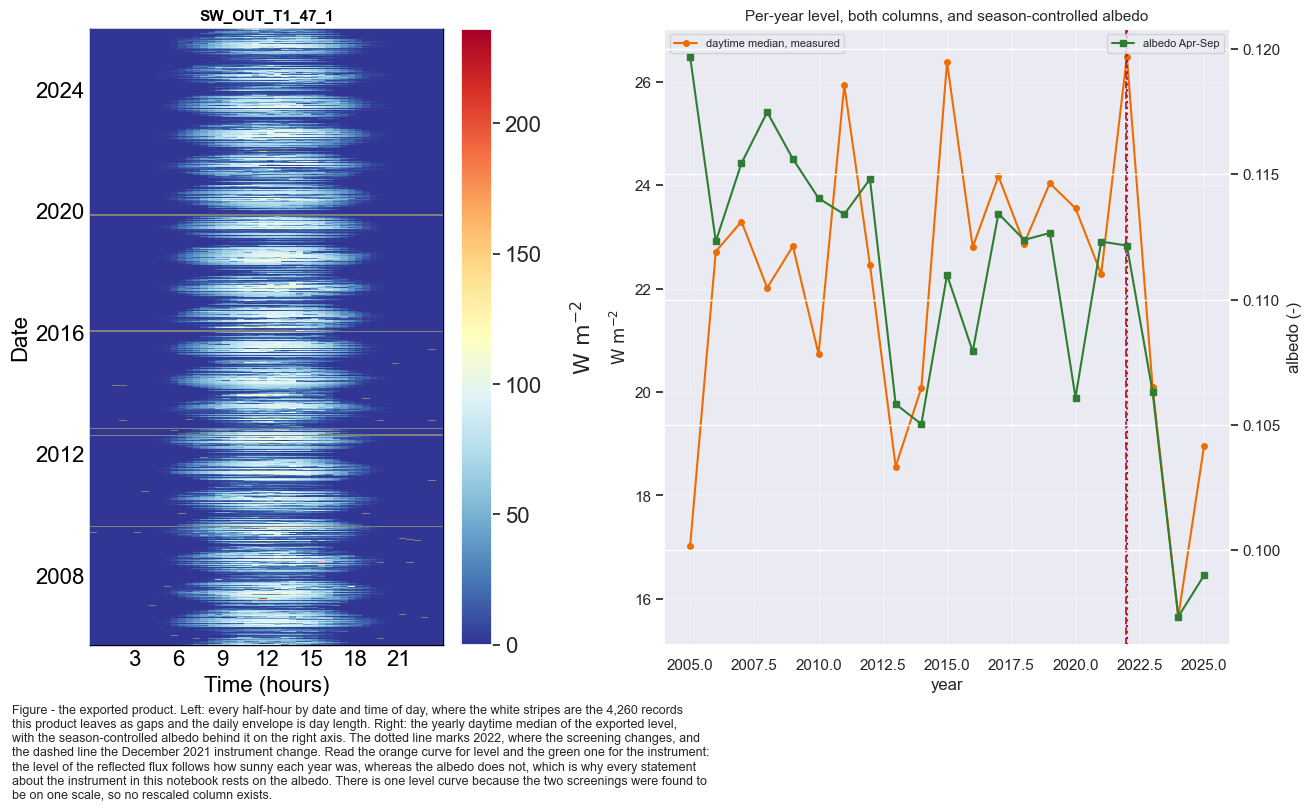

In [57]:
fig, axs = plt.subplots(ncols=2, figsize=(13, 8), dpi=100, layout='constrained',
                        width_ratios=[1, 1.6])
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))

_yr['daytime median'].plot(ax=axs[1], marker='o', ms=4,
                           color=('#B0BEC5' if HOMOGCOL else '#EF6C00'),
                           label='daytime median, measured')
if HOMOGCOL:
    _yr['homogenized daytime median'].plot(ax=axs[1], marker='o', ms=4, color='#EF6C00',
                                           label='daytime median, homogenized')
axs[1].set_ylabel(r'$\mathrm{W\ m^{-2}}$')
axs[1].set_xlabel('year')
axs[1].grid(alpha=0.3)
_ax2 = axs[1].twinx()
_yr['albedo Apr-Sep'].plot(ax=_ax2, marker='s', ms=4, color='#2E7D32', label='albedo Apr-Sep')
_ax2.set_ylabel('albedo (-)')
_first_diive_year = int(export_df.loc[source == 0].index.year.min())
axs[1].axvline(_first_diive_year, color='#6A1B9A', ls=':', lw=1.6)
axs[1].axvline(CNR4_INSTALLED.year + CNR4_INSTALLED.dayofyear / 366, color='#C62828', ls='--',
               lw=1.4)
axs[1].set_title('Per-year level, both columns, and season-controlled albedo', fontsize=11)
axs[1].legend(fontsize=8, loc='upper left')
_ax2.legend(fontsize=8, loc='upper right')

figcap(fig, f"the exported product. Left: every half-hour by date and time of day, where the white "
            f"stripes are the {int(export_df[VALCOL].isna().sum()):,} records this product leaves "
            f"as gaps and the daily envelope is day length. Right: the yearly daytime median of "
            f"the exported level, with the season-controlled albedo behind it on the right axis. "
            f"The dotted line marks {_first_diive_year}, where the screening changes, and the "
            f"dashed line the December 2021 instrument change. Read the orange curve for level and "
            f"the green one for the instrument: the level of the reflected flux follows how sunny "
            f"each year was, whereas the albedo does not, which is why every statement about the "
            f"instrument in this notebook rests on the albedo."
            + (" The grey curve is the measured column and the orange one the homogenized column, "
               "and they part only before the dotted line, which is the factor being applied to "
               "the mst era and to nothing else." if HOMOGCOL else
               " There is one level curve because the two screenings were found to be on one "
               "scale, so no rescaled column exists."))

***

## 💾 Save to file

In [58]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\12_METEO_SW_OUT_2005-2025.parquet (0.053 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\12_METEO_SW_OUT_2005-2025.parquet


### Verify the written file

Reading the parquet back and checking it directly, rather than trusting the in-memory frame.

In [59]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns:   {list(_written.columns)}")
print(f"index:     {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)")
print(f"measured:  {int(_written[VALCOL].notna().sum()):,} "
      f"({100 * _written[VALCOL].notna().mean():.2f}%)")
print(f"daytime median: {float(_written[VALCOL].where(POTRAD > 0).median()):.2f} W m-2")
print(f"min / max: {float(_written[VALCOL].min()):.2f} / {float(_written[VALCOL].max()):.2f} W m-2")

assert list(_written.columns) == EXPORT_COLUMNS, "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
for _c in VALUE_COLUMNS:
    assert _written[_c].notna().sum() == export_df[_c].notna().sum(), \
        f"{_c}: measured count changed on write"
    assert float(_written[_c].min()) >= _bands[_c][0], \
        f"{_c}: a negative value appeared on write"
    assert bool(_written[_c].loc[FULLY_DARK].fillna(0).eq(0).all()), \
        f"{_c}: a fully dark half-hour is not zero in the written file"
for _c in (FLAGCOL, INSTRCOL):
    assert _written[_c].equals(export_df[_c]), f"{_c} changed on write"

if HOMOGCOL:
    # The factor has to survive the round trip, because it is the one number a reader would need in
    # order to undo the rescaling and it is not stored anywhere in the file itself.
    _rt = (_written[HOMOGCOL] / _written[VALCOL]).where(
        (_written[FLAGCOL] == 1) & (_written[VALCOL] > 0)).dropna()
    assert float((_rt - MST_TO_DIIVE).abs().max()) < 1e-9, \
        "the ratio between the two value columns in the mst era is no longer the measured factor"
    print(f"\nWritten file verified. The factor between the two value columns in the mst era "
          f"reads back as {float(_rt.median()):.5f}.")
else:
    print(f"\nWritten file verified. It carries one value column, because the two screenings were "
          f"measured to agree to {100 * abs(MST_TO_DIIVE - 1):.2f} % over their overlap.")

tabcap("the written file read back, by year and by screening era, on the measured column. The "
       "daytime median is given rather than the overall one, because half of every year is night "
       "and exactly zero. The mst screening covers every year up to 2021 and diive the years after "
       "it, so each year falls in a single column; a year that showed in two would be a year "
       "holding the screening boundary, or a sign that provenance had not travelled with a "
       "correction that moves records between years. The columns are on one scale"
       + (" only after the homogenization" if HOMOGCOL else
          ", which is what the scale section established"))
_check = (_written[VALCOL].where(POTRAD > 0)
          .groupby([_written.index.year, _written[FLAGCOL]]).median().unstack())
# The flag has a code for half-hours neither screening covers, and those carry no value, so that
# column comes back empty rather than absent.
_check = _check.dropna(axis=1, how='all')
_check.index.name = 'YEAR'
_check.columns = [f'{FLAGCOL} {int(c)}' for c in _check.columns]
display(_check.round(2))

# The August 2012 block is the one place in this record where a correction moves records between
# months, and it is where provenance was got wrong once. If its values ever come back credited to a
# screening that did not exist in 2012, this fires.
_2012 = _written.loc['2012', FLAGCOL].where(_written.loc['2012', VALCOL].notna()).dropna()
print(f"\n2012 measured records by screening code: {dict(_2012.value_counts().astype(int))}")
assert set(_2012.unique()) == {1}, (
    f"2012 carries screening codes {sorted(set(_2012.unique()))} among its measured records. Every "
    f"2012 value comes from the mst screening, which is the only one that covers that year, so a "
    f"code 0 there means the timestamp shift moved values without moving their provenance")

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\12_METEO_SW_OUT_2005-2025.parquet (0.014 seconds).

columns:   ['SW_OUT_T1_47_1', 'FLAG_SW_OUT_T1_47_1_SOURCE', 'FLAG_SW_OUT_T1_47_1_INSTRUMENT']
index:     2005-09-14 00:15:00 -> 2025-12-31 23:45:00  (355,872 records)
measured:  351,612 (98.80%)
daytime median: 22.03 W m-2
min / max: 0.00 / 236.24 W m-2

Written file verified. It carries one value column, because the two screenings were measured to agree to 0.03 % over their overlap.
Table - the written file read back, by year and by screening era, on the measured column. The
daytime median is given rather than the overall one, because half of every year is night and exactly
zero. The mst screening covers every year up to 2021 and diive the years after it, so each year
falls in a single column; a year that showed in two would be a year holding the screening boundary,
or a sign that provenance had not travelled with a correction that moves records between years. The
columns are on one scale, which is what the scale section established



,FLAG_SW_OUT_T1_47_1_SOURCE 0,FLAG_SW_OUT_T1_47_1_SOURCE 1
YEAR,,
2005,NaN,17.02
2006,NaN,22.72
2007,NaN,23.30
2008,NaN,22.01
2009,NaN,22.82
2010,NaN,20.73
2011,NaN,25.93
2012,NaN,22.46
2013,NaN,18.56



2012 measured records by screening code: {1.0: np.int64(16283)}


***

## End of notebook.

In [60]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-09-03 21:50:04
Finished: 2026-09-03 21:50:43
Runtime:  00:00:39 (hh:mm:ss)
